In [1]:
import re

In [ ]:
pupa = """
Dice loss style transfer

<<< BASIC TERMS >>>
==========================================================================================================
Q:: What is DS?
A:: Data Science is a multidisciplinary field that involves usage of scientific methods, processes, 
    algorithms, and systems to extract knowledge and insights from structured and unstructured data. 
    It combines several disciplines, including statistics, mathematics, computer science, domain 
    expertise, and data engineering, to analyze, interpret, and make data-driven decisions.


Q:: What is ML?
A:: Machine Learning (ML) is a subset of artificial intelligence (AI) that involves developing 
    algorithms and statistical models that enable computers to learn from data without explicit 
    programming. It focuses on building systems that improve their performance on a given task over 
    time by learning from data.


Q:: What is supervised learning? What is unsupervised learning?
A:: Supervised learning is a type of machine learning where the model is trained on dataset where 
    each training example is paired with an output label, and the model learns to predict the output 
    from the input data.
    Unsupervised learning involves training a model on data that does not have labeled responses. 
    The goal is to find hidden patterns or intrinsic structures within the data.


Q:: What is regression? Give me examples of regression?
A:: 1) Regression refers to a type of task where the goal is to predict a continuous output variable 
    (one that can take on any value within a range) rather than a categorical or discrete one. This 
    contrasts with classification tasks, where the target is a distinct category or class.
    2) Price prediction, quant of penguins in photo, temperature prediction

    
Q:: What is classification? Give me examples of classification?
A:: 1) Classification in NNs refers to the task of predicting a discrete label or category 
    for an input based on its features. In a classification problem, the goal is to assign an input 
    (such as an image, text, or data point) to one of several predefined classes.
    2) spam/not spam, having a photo find identity of employee, diseace identification

    
Q:: Give me examples of classification when we predict multiple classes at the same time?
A:: diseace identification (one patient have many diceases), genome-to-feature, objects in image


Q:: What is ranking task? How is it called in russian? Give me examples of ranking?
A:: 1) Ranking (Ранжирование) is the task of ordering or sorting items according to a particular criterion 
    or set of criteria. The goal is to arrange the items in a sequence where each item is ranked relative 
    to others based on their relevance, importance, or another metric. Here we predict not a class, 
    but an order of element
    2) Ranking web pages by relevance to a user's query, Ranking products or movies by how likely 
    a user is to be interested in them, ranking students or institutions on their future achievements 
    based on their current performance.

    
Q:: Semi-supervised learning
A:: Semi-supervised learning is a machine learning technique that falls between supervised learning 
    and unsupervised learning. In semi-supervised learning, you use a small amount of labeled data 
    and a larger amount of unlabeled data to train your model.    

    
Q:: Self-supervised learning
A:: In self-supervised learning the model learns from data without explicit human-labeled examples. 
    Instead, the model generates labels or tasks from the data itself and uses them to train.
    Examples: Predict missing words, reconstruct images, or figure out if a sentence makes sense.

    
Q:: What is clusterization? Examples of clusterization?
A:: 1) Clusterization is a type of unsupervised machine learning task that involves 
        grouping a set of objects into clusters or groups. The goal is to organize the objects such that 
        items in the same cluster are more similar to each other than to those in other clusters. 
    2) clients clusterization, films similarity

    
Q:: What is the current state of clustering?
A:: Nowadays clustering is a task which allows you to solve your problems occasionaly. It's a hard
    task, when you ask an algorthm to cluster the data - it's a naive to expect from it meaningfull 
    and interpretable clusterization without answers. Usually it's used to understang in general 
    something about a dataset. And bacause of unclearance of a task there are plenty of methods, but 
    no guarantee that particular method will give something reasonable.


Q:: What is hard/soft clustering?
A:: Hard Clustering: In hard clustering, each data point is assigned to exactly one cluster. A data point 
        either belongs to a cluster or does not; there is no overlap or uncertainty in the assignment.
    Soft Clustering : In soft clustering (also known as fuzzy clustering), each data point can belong to 
        multiple clusters with different degrees of membership. Instead of assigning a single cluster, a 
        data point can have a probability or degree of belonging to each cluster.


Q:: What is forecasting task?
A:: Essentially the process of predicting future values or outcomes based on historical data or trends. 
    In simpler terms, it's when you use past patterns to make educated guesses about 
    what's going to happen next.
                
        
Q:: What is overfitting, ***, underfitting? What are differences? Which word is missing?
A:: 1) Overfitting occurs when a model learns the details and noise in the training data to the extent that 
        it negatively impacts its performance on unseen data. The model fits the training data, capturing 
        patterns that are specific to the training set but not generalizable to other data.
        The model performs exceptionally well on the training data. The model performs poorly on the 
        test data or new, unseen data
    2) Underfitting happens when a model is too simple to capture the underlying patterns in 
        the data. The model has high bias and low variance, resulting in poor performance on both the 
        training and test data because it fails to learn from the data sufficiently
        The model performs poorly on the training data
        The model performs poorly on the test data as well
    3) Generalization refers to a model's ability to perform well on new, unseen data that was not 
        part of the training dataset. A model with good generalization captures the underlying trends 
        in the data rather than memorizing the training data.
        The model performs well on both the training and test datasets.


Q:: What are Bias, variance, and noise?
A:: - Bias refers to the error introduced by approximating a real-world problem by a simplified model. 
        In other words, bias is the degree to which a model's predictions are systematically off from 
        the true values. Indicates that the model is too simple and does not capture the underlying patterns 
        in the data well, leading to underfitting. High bias models assume strong, often incorrect, 
        assumptions about the data.
    - Variance refers to the model's sensitivity to small fluctuations in the training data. 
        A model with high variance pays too much attention to the training data, capturing noise along 
        with the signal, and may perform poorly on new, unseen data.
        Indicates that the model is too complex and overly sensitive to the specific training data, 
        leading to overfitting. The model captures noise in the data as if it were a true pattern.
    - Noise refers to the random, irrelevant variations in the data that are not part of the true 
        underlying pattern. Noise is intrinsic to the data and cannot be reduced by the model.  


Q:: How can we interprete W values?
A:: The size of W value can be interpreted as how important feature is, Larger magnitudes imply a 
    stronger impact of the feature on the target variable. but only! Only if features are 
    normalized - have same scale!  
    

    
<<< BUILDING BRICKS >>>
==========================================================================================================
Q:: What is a loss function?
A:: A loss function is a mathematical function used to measure how well a model's predictions match 
    the actual target values in supervised learning tasks. It quantifies the difference between the 
    predicted outputs and the true outputs, guiding the training process to improve model performance.


Q:: What is Euclidian distance, Manhattan distance, Cosine distance, L1, L2 distances?
A:: Euclidean distance (L2) is the straight-line distance between two points in Euclidean space. 
    sqrt(sum((a1-a2)^2+(b1-b2)^2+...))
    The Manhattan distance (L1) is the sum of the absolute differences of their coordinates.
    It measures distance by summing the absolute values of the differences along each dimension.
    In other words it measures the distance by summing legs of triangle.
    sum(abs(a1-a2)+abs(b1-b2))/N
    Cosine distance measures the cosine of the angle between two vectors.
    cosine dist:: 1 - np.dot(a, b) / ( np.linalg.norm(a) * np.linalg.norm(b))


Q:: How to choose between manhattan, cosine and euclidian distance?
A:: Manhattan Distance can be preferable if the feature space is highly dimensional or if you expect 
    that differences along each dimension should be treated independently. When dealing with sparse 
    data (lots of zeros), Manhattan distance is often more meaningful as it treats all dimensions equally.
    And it's less sensitive to outliers compared to Euclidean distance. Euclidian distance also should be 
    applied when you believe the geometric distance in a straight line is meaningful. 
    Cosine distance is commonly used when you care more about the direction rather than magnitude. Useful 
    in cases where you're interested in how similar two vectors are rather than how far apart they are.


Q:: How can I measure similarity between objects with discrete features
A:: 1) Hamming Distance: sum(I(a_i == b_i)), 
        where I - indicator, which 1 if a_i == b_i else 0
    2) one-hot vectors cos dist
    3) one-layered NN give us object embedding, cos

    
Q:: What is sigmoid? What is softmax? How Log, sigmoid, tanh plots look like?
A:: 1) The sigmoid function is used to map any real-valued number into the range [0, 1]
        Formula: sigmoid = 1/(1+exp(-z))  
    2) Softmax is a mathematical function that converts a vector of arbitrary real values into a vector 
        of probabilities, where the sum of all probabilities is 1. 
        It is often used in the output layer of a neural network for multi-class classification problems.
        softmax = exp(z_i)/sum(exp(z)) 
    3) tanh - sigmoid between -1 and 1
        sigmoid - sigmoid between 0 and 1
        Log - 1) [0, 1] it goes under x axis from x=0 along y to x=1 trying to reach it 
              2) [1, +inf] something like square root
    
              
Q:: ___________________________________________________________________________________
A::

              
Q:: What loss functions you know? What regression/classification losses you know?
A:: Regression ::MSE, MAE, MAPE, MSLE, Huber
    Classification:: IOU, binary cross-entropy, categorical cross-entropy, triplet, Contrastive, Dice

    
Q:: Tell me about MSE loss. How it affects learning?
A:: -Mean Squared Error (MSE) is a metric for evaluating the performance of regression models. MSE is 
    sensitive to outliers because the error is squared. 
    -Larger errors have a disproportionately higher impact on the MSE, which means a few large errors 
    can dominate the metric. MSE is commonly used when large errors are particularly undesirable, and 
    when the goal is to penalize larger errors more heavily. 
    MSE = sum((y-a)^2)/N
    

Q:: Tell me about MAE loss. How it affects learning?
A:: -Mean Absolute Error (MAE) is more robust to outliers than MSE because it does not square the errors. 
    Each error contributes to the metric in proportion to its absolute value. 
    MAE = sum(|y-a|)/N


Q:: Should or shouldn't we use MSE in classification task?
A:: Technicaly we could you it, but shouldn't cause it worse on acount of:
        1) Cross-entropy loss is super sensitive to confident wrong predictions (e.g., predicting 0.01 
            for a "1" label will result in larger loss then MSE loss).
        2) Interpretation is struggling
        3) MSE loss do not have any natular boundary on which it can lean on making predictions
        4) If we're interested just in sign then -1/1 will be treated same way as -100000/1 prediction,
            both of this predictions from sign perspective are right, but you see how noisy they are
            noisiness is a sign of overfitting and stockastic predictions in futuire.

    
Q:: MAPE, How it affects learning?
A:: It measures the percentage difference between predicted values and actual values. The lower the 
    MAPE, the better the model is at predicting the target variable. 
    Used when the range of values varies significantly
    !Percentage errors can explode and become meaningless when the actual value is zero or close to zero.
    MAPE = sum((y-a)/y)/N

    
Q:: MSLE, How it affects learning?
A:: MSLE (Mean Squared Logarithmic Error) It's useful when the data contains exponential growth or when 
    the predictions are expected to be positive and in a similar range as the target values or 
    in cases where data includes small numbers and you want to avoid large errors in those cases 
    (e.g., predicting the number of visitors to a website).
    sing = log(y+1)-log(a+1)
    MSLE = sum(sing^2)/N

    
Q:: Why counting an error we use abs or ^2?
A:: Cause without abs/^2 in sutuation when (a-y) are 10, 10, 10,..., -10, -10,-10 mean arror is 0,
    when actually it's really high (expecting values being in a range between 0 and 1)
    so we have to use either (a-y)^2 or |a-y|

    
Q:: Tell about Huber loss
A:: Huber loss A combination of MSE and MAE that is quadratic for smaller errors and linear for larger 
    errors. Used in regression tasks when you want to be less sensitive to outliers than with MSE.
    Used if you believe that outliers should be ignored. It still sensitive to outliers at the 
    beginning, but less sensitive to far away outliers.
    |          \                 /
    |           \               /               
    |<--s        '-_         _-'  <--------------Becomes |a-y| in s, before (a-y)^2
    |_______________"--___--"________________________
        { (y-a)^2/2    for |y-a| <= s
    L = {
        { s|y-a|-s^2/2 for |y-a| > s

        
Q:: What is IOU loss, Dice loss? Where should I choose each?
A:: IOU and Dice - losses which are used in object detection and segmentation tasks to measure the 
    overlap between the predicted and actual bounding boxes or masks.
    IOU loss = 1 - (box_a and box_b)/(box_a U box_b)
    Dice loss = 1 - 2*(box_a and box_b)/(box_a + box_b)
    In image segmentation tasks, especially in medical images, such as tumors, the foreground is often 
    much smaller than the background. In such cases, traditional loss functions like cross-entropy 
    might not perform well because they give more weight to the majority class (background). 
    Dice Loss, on the other hand, is more focused on the overlap between the predicted and ground truth 
    foreground, making it a good choice for imbalanced datasets.


Q:: What is binary cross-entropy?
A:: Binary cross-entropy loss, is a common loss function used in classification problems, particularly 
    binary classification. It quantifies the performance of a classification model by measuring the 
    difference between the predicted probabilities and the actual binary outcomes. It also is used for 
    multi-class classification if we want to detect fron 0 to N classes on an image. 
    single = y*log(a) + (1-y)*log(1-a)
    L = (-1)*sum(single)/N
    # multi-class task
    for class in classes:
        loss+=calc_loss_for_this_class(class, logits)


Q:: What is categorical cross-entropy? Explain with example.
A:: Categorical cross-entropy is a common loss function used in classification problems, particularly 
    in multiclass classification where there are more than two possible classes, but only one label!!! 
    CANNOT be used to identify presense of mult classes on a single image.
    CCE = (-1)*sum(y*log(a))/N  <---------- shortened form
    Example:
    You have a multi-class classification problem with 3 classes (0, 1, 2)
    The true label y is 2 (represented in one-hot encoded form as [0, 0, 1])
    The predicted probabilities for the three classes are a = [0.1, 0.3, 0.6]
    L_i = (-1)*(0*log(0.1)+0*log(0.3)+1*log(0.6))
    Since we know, that the data comes from class 2, the observed probability, that it comes from class 2
    is 1, and not from class to = 0.
    Then we do the same for resc classes
    Then we sum all L_i and obtain a result L.


Q:: X_X_X What is Logistic loss?
A:: The function represents the logistic loss used in binary classification problems. The logistic loss 
    function is designed to penalize incorrect predictions by assigning a higher loss to predictions 
    that are both wrong and confident. It rather tries to predict the direction, than distinct value.
    loss = log(1 + exp(-ya)), where 'y' from {0,1}, 'a' from {-inf, +inf}
    if y = 1 and a = +inf, then 0                           if y = -1 and a = +inf, then inf
    if y = 1 and a = +1, then 0.313                         if y = -1 and a = +1, then  1.312
    if y = 1 and a = +0.5, then 0.5                         if y = -1 and a = +0.5, then 0.974
    if y = 1 and a = 0, then 0.693                          if y = -1 and a = 0, then 0.693
    if y = 1 and a = -0.5, then 0.974                       if y = -1 and a = -0.5, then 0.5
    if y = 1 and a = -1, then 1.312                         if y = -1 and a = -1, then 0.313
    if y = 1 and a = -inf, then inf                         if y = -1 and a = -inf, then 0

    
Q:: Contrastive loss
A:: Both Triplet Loss and Contrastive Loss are closely related but differ in how they handle 
        pairs (or sets) of data points.
    Contrastive Loss works with pairs of data points, either:
        - A positive pair (similar data points) or
        - A negative pair (dissimilar data points).
    - For positive pairs: The loss function tries to minimize the distance between them.
    - For negative pairs: The loss function tries to increase the distance between them 
        (ensuring a margin is maintained between dissimilar pairs).
    L = z*(A - P)^2 + (1-z)*max(0, M - (A - N)^2), z = 0 if pair_is_similar, else 1 

    
_ Q:: What is feature scaling? why it is applied?
A:: Feature scaling refers to the process of transforming features to ensure they are on a similar scale. 
    This involves methods to adjust the values of features so that they fit within a specific range or 
    distribution. 
    1) If features are on different scales it means that weight should also be on different scales,
        however, we told already that weights should represent the importance of feature, hence, it's 
        values should be affected only by the importance of feature, not it's scale.
    2) Ideally what we want is to update the weight during learning on the amount of value which depends 
        only on how bad particular weight is, however, when we compute loss, all weghts are participate in 
        loss calculation, hence, loss value is affected by ALL weghts, and then, based on averall loss
        of all weights we compute a loss for each certain weight, which leads to disproportional update.
    3) lr is same for all weights.
        - small nets can learn without feature scaling, however, large NN can't, they'll explode or vanish

    
Q:: Common types of feature scaling?
A:: 1) (x-x_min)/(x_max-x_min)
        Use when you need to scale features to a specific range, typically [0, 1] or [-1, 1]. This is useful 
        for algorithms that rely on distances between data points or where a bounded range is desirable 
        (e.g., neural networks). Sensitive to extreme values. If there are very large values in the data, 
        the scaling might not be effective in controlling their influence.
    2) (x-u)/std
        transforms the data into a distribution with a mean (average) of 0 and a standard deviation of 1
        Use when the data is approximately normally distributed or when the algorithm assumes that features 
        have a normal distribution. Less sensitive to outliers compared to Min-Max scaling. If your data 
        has outliers, Z-score normalization can be more robust.
    3) x/abs(x_max)
        Use when working with sparse data and you want to scale features while preserving sparsity. Useful 
        for data already centered around zero and when you want to bound the feature values within [-1, 1].
        Sensitive to extreme values. 

    
Q:: When should I use Min-Max Scaling, Max Scaling, Z-Score Normalization?
A:: 1) Min-Max/Max Scaling:: 
    - Min-Max Scaling is highly sensitive to outliers, the scaling will be affected, potentially skewing 
    the results. If your data does not have extreme values or you have already dealt with outliers, 
    Min-Max scaling can be effective.
    - This scaling method is useful working with sparse data - where many feature values are zero. It 
    preserves the sparsity of the data. 
    2) Z-Score Normalization:
    - When your data is approximately normally distributed 
    - When the goal is to center the data around zero and have a standard deviation of one. For a typical 
    dataset following a normal distribution, about 99.7% of the values (three standard deviations) will 
    lie within the range: [-3, +3]
    - Suitable for assumption that data is normally distributed or are sensitive to different scales
    - It is less sensitive to outliers than Min-Max scaling but still can be affected if they are extreme

    
Q:: RMSNorm
A:: x_new = (x / RMS(x))@W
    RMS(x) = SQRT(SUM(x_i^2) / N), where x_i - feature of x
    ---------------------------------------------------
    x = [3, -4, 2] 
    RMS = SQRT((3^2 + (-4)^2 + 2^2)/3)
    RMS = 3.11
    x_new = [3/3.11, -4/3.11, 2/3.11]@W
    ✅ Faster & More Efficient - Skipping the mean computation saves time and resources.
    ✅ Better for Deep Models - Helps with gradient propagation in deep transformers.
    ✅ learnable W allow to controll the degree of norm
    ✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅
    ✅✅✅ Allows to control variance by eliminating unnecessary channels  ✅✅✅
    ✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅
    - used in Llama and Deepseek
    - The learned weight for each channel is then used to scale the normalized output of that channel. 
        This allows the model to adjust the importance of each feature map after normalization, which 
        helps the network learn richer representations.

        
Q:: What is dead neuron problem?
A:: - The dead neuron problem happens when certain neurons stop updating during training, meaning their 
        weights never change because their gradient is always zero. These neurons no longer contribute 
        to learning, making the network less effective. 
    - The main cause? ReLU activation function 🚀
    - ReLU sets all negative values to 0. If a neuron gets stuck in the negative range, its output 
        is 0, and its gradient is 0. This means the neuron never activates again — it's dead! ⚰️

    
Q:: Swish activation
A:: Swish is an activation function that works like a smooth version of ReLU, has been used 
    in advanced neural networks, including transformers.
    Swish = x*sigmoid(x)
    Plot looks like ReLU, but bended a bit near 0.
    ✅ Smooth & differentiable everywhere (Unlike ReLU).
    ✅ Allows small negative values, preventing dead neurons.
    ✅ Works better in deeper networks (Gradient flows smoothly).


Q:: SwiGLU
A:: - Instead of passing all inputs, the gate learns which values to keep or suppress, 
        making learning more efficient.
    - SwiGLU = Swish(dot(W_1, X))*(dot(W_2, X))
    Example::
        Main path: m = (2*1.0) + (-1*0.5) + 0.0 = 1.5
        Gate path: g_in = (2*0.3) + (-1*0.7) + 0.0 = -0.1
        Swish(g_in) = -0.1 * sigmoid(-0.1)
                    ≈ -0.1 * 0.475
                    ≈ -0.0475
        SwishGLU = m * Swish(g_in) 
                    = 1.5 * -0.0475
                    ≈ -0.071

    ------------------------------------------------
    ✅ Better Expressiveness - Unlike ReLU, it smoothly controls activation using the Swish function, 
        leading to richer learning.
    ✅ Improves Gradient Flow - Avoids the "dying ReLU" problem, making it more stable for deep networks.
    ✅ transformers GOAT
    

Q:: Layer Norm vs Batch Norm
A:: Batch Norm normalizes inputs across the batch dimension during training.
        1) compute batch_mean and std for each feature dim: batch_means = (4, 3.7, 3.5)
        2) s_i/batch_mean
    Layer Norm normalizes inputs for a single instance of data sample.
        1) compute sample_mean and std for each feature dim: sample_means = (4, 3.3, 4.3, 3.3)

        x_1|x_2|x_3|
    s_1| 1 | 3 | 8 | 4
    s_2| 3 | 4 | 3 | 3.3
    s_3| 5 | 6 | 2 | 4.3 
    s_4| 7 | 2 | 1 | 3.3
       |4.0|3.7|3.5|
    veritcal - batch norm (means)
    horizontal - layer norm (means)
    - Benefits of using batch norm include faster training speed and greater input stability, 
        which significantly reduces the chance of gradient explosion/vanishing.
    - Layer norm is widely used in sequential modeling (RNN) and the transformer architecture, 
        as NLP tasks often have variable batch sizes (sentence length), it is more intuitive to just normalize 
        on a single word with layer norm.
    
        
Q:: How to clear data from anomalies?
A:: 1) Visually using scatter plots. Additionaly we can plot 25th, 50th, 75th percentiles for convenience.
    2) z-score:: remove all datapoints which are further than 3std value. Disadv - data has to be 
        distributed normaly
    3) Percentiles:: remove all values before 2nd and after 98th percentile.
    4) IQR (inter quartile range):: 
        - Divide data in quartiles
        - Calculate IQR = Q_3 - Q_1
        - find boundaries B = Q_3/Q_1 -+ 1.5*IQR
        if we have Gaussian dist        


Q:: How to prepare text data?
A:: 1) Inspect visually on overall consistency: 
        - if unicode encoding-decoding is correct
        - len of samples
    2) Heuristic filtering:
        - Filters out snippets that are too brief to be meaningful or suspiciously long.
        - Identifies and removes text containing excessive boilerplate content.
        - Identifies repeated phrases at different lengths and removes documents with excessive 
            repetition that might indicate low-quality or artificially generated content.
    3) Semantic deduplication:
        * sentese_embed = SUM(words)
        * if cos(sentese_embed_1, sentese_embed_2) > boundary
        *       <<< eliminate one >>>
    4) Model fintering:
        - use BERT to remove toxic comments
        - or remove certain topics
    5) Personal info removal
    6) Data combination: check presense of all necessary topics while combining multiple datasets


Q:: How to prepare image data?
A:: 1) Depends on which type of data you have. If the dataset is verified then no visual inspection is applied, 
        if not trusted - had better to inspect it visually!
    2) Determine image size, shrink your data to img_size
    3) Augment the data, apply transformations 
        
    
Q:: What is regularization? Why should it be applied?
A:: Regularization is a technique used in machine learning used to prevent overfitting by adding a 
    penalty term to the model's loss function forcing it to keep the model parameters W smaller and 
    more generalized.
    Without regularization, models can become complex, with large weights. This complexity can make 
    the model sensitive to small changes in the data, leading to poor generalization.
    Regularization encourages the model to be simpler, with smaller weights. 
    A simpler model is often more interpretable and less likely to overfit.   

    
Q:: L1, L2 regularizations
A:: L2 regularization - lambda*sum(w*w)
    L1 regularization - lambda*sum(|w|)
     if lambda is zero then we get back original loss function. if lambda is very large then it will 
     make all weights close to 0 and lead to under-fitting. If lambda is moderate -is shrinks weights
     allowing the model to pay more attention on different features
    
     
Q:: How does L2 regularization affect model weights and activations?
A:: L2 regularization distributes the weights for all layers by gaussian distribution and shrinks 
    their norm to small values.
    The magnitude of activations become smaller.
      |
     |||
     |||
    |||||
    |||||
   /|||||\                                
  |||||||||                             /||||||||||||||||\ 
  |||||||||  <-initial dist           /||||||||||||||||||||\           <--- res dist
  

Q:: How does L1 regularization affect model weights and activations?
A:: L1 Regularization pushes the weights corresponding to less important feature's to 0, and allows few 
    high weights. thereby removing those features altogether. This, in turn, makes the model simpler 
    thereby removing overfitting.
    Affects learning speed, increasing it.
    the average activations of most of the nodes becomes close to 0 and only a few nodes with very 
    high average activation values. Smaller activations (~1e-5) leads to smaller weight updates, 
    and are probably the root cause for slower training with L1 regularization.
          |
         |||
         |||
        |||||
        |||||
       /|||||\                                
      |||||||||                              /\     |   .   |
      |||||||||  <-initial dist           |__|||___|||_|||__|||\           <--- res dist
    
      
Q:: Why shouldn't we regularize b?
A:: The intercept b represents the baseline value, mean answer which is corrected by x1, x2, ..., xn 
    features. It's strange to penalize baseline answer, like penalizing the nature of the object.   
    

Q:: What is dropout?
A:: Dropout is a regularization technique used in training neural networks to prevent overfitting. 
    During each training iteration, a certain percentage of neurons in a layer are randomly chosen to 
    be ignored (dropped out). This means that these neurons and their connections do not participate in 
    the forward and backward passes for that iteration. 
    

Q:: How dropout is applied during training/testing?
A:: During training, dropout forces the network to learn redundant representations, as it cannot rely on 
    any  specific neurons. This helps in preventing the model from becoming too reliant on particular 
    neurons and thus helps in reducing overfitting.
    During evaluation or testing, dropout is not applied. Instead, the full network is used, and the 
    outputs of the neurons are scaled by the dropout rate to compensate for the dropout during training. 
    This means that if the dropout rate was 0.4 during training, the outputs during testing are scaled 
    by 0.4 (multiplied by 0.4).


Q:: How does dropout affects training time?
A:: The primary effect of dropout on training time is an increase in the number of iterations required 
    to converge. 
    1) Since dropout randomly drops out neurons, the network needs to see more examples to 
    learn the same amount of information. 
    2) Since it uses more matrices, randoms it also just because of computation amount requires more.


Q:: What are Sparce models? Is that W or L?
A:: Sparce models are models with lot's of zero W. It's W when we have dozens of features and we want
    to remain only relevant.

    
Q:: Difference Between Gradient and Antigradient
A:: - Gradient: The gradient of a loss function tells us the direction in which the function increases 
        most steeply. It points "uphill" in the loss landscape.
    - Antigradient: The antigradient is the negative of the gradient. It points in the direction where 
        the loss function decreases most steeply — essentially "downhill."
    In optimization, the goal is usually to minimize the loss function. Since the gradient points uphill, 
    we need to move in the opposite direction to reduce the loss, and that direction is given 
    by the antigradient.

    
Q:: What is GD?
A:: Vanilla GD uses whole set of data to descent.


Q:: Most commonly used optimizers brief overview
A:: 1) SGD
    2) mementum
    3) RMSProp
    4) Adam
    5) SparceAdam
    5) AdamW


Q:: What is stochastic gr. desc? What are problems with stochastic gr. desc? How to fix them?
A:: Stochastic Gradient Descent (SGD) optimizes models using the gradient computed from a single training 
    example. It works not so good due to the problems with convergence. SGD near the end of learning is not 
    converging at all cause of small aproximation of dW.
    Issue: SGD uses a single training example to compute the gradient, which introduces a lot of noise 
    in the gradient estimates. And SGD near zero oscelates without the ability to coverge.
    Solutions:
    1) Larger mini-batches. 
    2) Momentum, Adam, RMSprop or AdaGrad


Q:: Momentum 
A:: Momentum is a technique that helps to accelerate gradient descent algorithms, particularly in deep 
    learning, by smoothing out updates and reducing oscillations. It works by adding a fraction of the 
    previous update's direction to the current update. With momentum, the update rule changes by 
    introducing a velocity term V that considers both the current gradient and the previous update:
    V = a*V_prev + (1-a)*dW, where V_prev - matrix of shape W.shape, which stores an update for each 
    weight from prev epoch. 'a' value is usually ~0.90.
    W = W - lr*V

    
Q:: Nesterov Momentum
A:: Same as momentum, but divide a problem into 2 steps: 
    1) We update weights with v_prev
    2) we update weights wit dW
    we update them separatly with v_prev and dW, not simultaneously
    - it allows to solve convex problems more efficiently, in any other sace just the same
    
    
Q:: AdaGrad
A:: AdaGrad (Adaptive Gradient) is an optimization algorithm that adjusts the learning rate for each 
    parameter dynamically based on the past gradients for each parameter. It's well-suited for sparse 
    datasets cause solves update-erasing problem. 
    1) Set initial parameters G, where G - matrix, which for each weight accumulates the score of how 
        often it was updated
    2) G = G_prev + dW^2
    3) W = W + lr*dW/sqrt(G)
    
     
Q:: RMSProp
A:: same as AdaGrad, but G = al*G_prev + (1-al)*dW^2 
    it this case on each iteration G is multiplied by al < 1, which leads to upper level higher that which
    algorithm cannot go and cannot vanish updates.


Q:: Adam
A:: momentum + AdaGrad. It combines the ideas of both momentum and adaptive learning rates.
    

Q:: Adam vs AdamW
A:: 🚫 The weight decay term (λθ_{t-1}) is added inside the gradient update, 
        which distorts learning dynamics. This can cause overfitting and worse 
        generalization in deep networks.
    ✅ AdamW fixes the issue by applying weight decay separately after the weight update.
    Original: W = W_prev - alpha*dW - gamma*W_prev
    Fixed: W = W_prev - alpha*dW
           W = gamma*W_prev
    ✅ This keeps the learning dynamics intact, leading to better generalization and less overfitting.


Q:: Why don't we expand NN in width, but rathen in len?
A:: Cause width increase do not produce comprehensive artificial features + do not allow to
    shrink the info. it only allow to make new features based on already existing X features, which
    will be primitive, and also it leads to overfitting cause we're making a lot of garbage features.


Q:: _________________________________________________________________
A:: 

Q:: What is linear regression?
A:: Linear regression is a function which models the relationship between a dependent variable and one 
    or more independent variables. Linear regression assumes that the relationship between the 
    dependent variable y and the independent variables (x1, x2, ..., xn) is linear. 
    y = w1*x1 + w2*x2 + ... + wn*xn + b

    
Q:: When should we use linear regression?
A:: 1) Linear regression is well-suited for predicting continuous numeric outcomes rather than 
        categorical ones. 
    2) Linear regression assumes that the differences between observed and predicted values are 
        normally distributed. 
    3) And there is a linear relationship.
    4) low amount of outliers

    
Q:: How overfitting/underfitting looks like in linear regression?
A:: Underfitting: the line will be far away from train/test set resulting in high bias
    Overfitting: The line will be right in the center ot training dataset, and, if this dataset is 
        constructed poorly, it will be far away from real data distribution (it means it captured all noises)
    Overfitting_2: line is going through "fat" dataset where # features > # samples, hence, 
        we have infinite num of solutions.


Q:: Least squares method
A:: Is a method how we can solve linear regression problem by making L = SUM((y-a)^2)


Q:: regularization in LSM
A:: 1) When the number of variables is greater than the number of observations, the linear regression 
        problem has infinitely many solutions that can fit the data perfectly. By introducing a 
        regularization term, such as L2 (Ridge) or L1 (Lasso) regularization, we add constraints to the 
        optimization problem that reduce the solution space.
    2) Remove noisy features.
    

Q:: What is polynomial regression?
A:: Polynomial regression is a function which models relationships between a 
    dependent variable and one or more independent variables by fitting a polynomial equation to the 
    data. It extends the concept of linear regression by allowing for non-linear relationships.
    y = w1*x1 + w2*x1*x2 + w3*x2^2 + ...
    Polynomial regression looks like curved line.


Q:: How overfitting/underfittiong looks like in polynomial regression?
A:: underfitting: behaves like a strainght line
    overfitting: behaves like a curve which goes up and down, but captures all data points

    
Q:: What is Logistic regression?
A:: Logistic Regression is a statistical and machine learning algorithm used for binary classification 
    tasks, where the goal is to predict one of two possible outcomes 
    sigmoid = 1/(1 + exp(-z)), where z = w1*x1 + w2*x2 + wn*xn + b 

    
Q:: How overfitting/underfittiong looks like in Logistic regression?
A:: underfitting: Decision-boundary line behaves like a strainght line
    overfitting: Decision-boundary line behaves like a curve which goes up and down, but captures
    all data points


Q:: Lasso regression
A:: It's just linear regression, but with L1 regularization to prevent overfitting by keeping weights small.


Q:: Ridge Regression 
A:: It's just linear regression, but with L2 regularization to prevent overfitting by keeping weights small.


Q:: What are other types of linear models if not linear regression?
A:: - Ridge/Lasso Regression  
    - SVM
    - SVD
    - Stump
    - PCA 
    - dot(W, X)


Q:: classification baseline
A:: 1) Majority class classifier : where the most frequent class in the data is predicted for 
        all observations. For instance, if we have 80% of observations in class A and 20% 
        in class B for a binary classification problem, the baseline model would predict 
        Class A for all instances.
    2) Random classifier : Randomly assigning class labels based on the class distribution 
        in the data. In the aforementioned binary classification scenario, we would assign 
        class A to 80% of the observations and class B to 20% of the observations randomly.
        The random classifier is particularly useful when there is no specific guidance 
        or knowledge available to make informed predictions.    

    
Q:: When linear regression is better than bagging/boosting?
A:: 1) purely linear data
    2) Small, Clean Dataset
    3) high speed is essential
    4) low amount of outliers
    5) all features will be present and none of them will be NULL eventually

    
Q:: clustering algorithms you know
A:: k-means, mean-shift, density-based clustering (DBSCAN), PCA, K-PCA, t-SNE 

    
Q:: What is kNN? 
A:: It is a type of instance-based learning where the algorithm makes predictions based on the closest 
    data points in the feature space.
    it does not build an explicit model during the training phase. 
    Instead, it stores the entire training dataset and performs computations during the prediction 
    phase. When a new data point needs to be classified, K-NN identifies the K nearest neighbors in 
    the training set based on a distance metric. The class of the new data point is then determined 
    by majority voting among these K neighbors.
    new = majority(k-nearest)


Q:: Can kNN be used for regression? Give me examples of kNN apps.
A:: Yes. For regression tasks, K-NN predicts the value of the new data point based on the 
    average (or weighted average) of the values of its K nearest neighbors.
    Examples: 
    0) Books recomend system
    1) Estimating the price of a house based on its features.
    2) Forecasting temperature based on weather conditions.


Q:: Disadvantages of kNN
A:: 1) if we have 45% 'green' voters and 55% 'red' voters the model will always vote for 'red' class
    and never for 'green', however, we know that it's not true at all, there is a hight chance of being 
    'green' as well.
    2) Not clear how to choose a k value
    3) Computationally expensive: Especially for large datasets, as it requires calculating the distance 
       to every other data point and to store the data + distances in RAM.

       
Q:: ANN
A:: 1) select 2 random points
    2) build separate line for them
    3) do that N times till max_bucket_size <= K
    4) now you can build a tree to estimate to which bucket your new point belong to:
        at each step you just cal is a point above or below the line

        
Q:: ANN forest
A:: 1) build an ANN tree
    2) build a forest
    3) a point now belongs to intersection region of this trees       


Q:: How to reach overfitting, underfitting in k nearest?
A:: k = 1-3 can lead to overfitting, where the model is too sensitive to noise in the training data. 
    A small k can result in a model that classifies based on very few or even single data points, 
    making it sensitive to outliers.
    k > 20  May lead to underfitting, where the model becomes too generalized and fails to capture 
    important patterns. It might also blur class boundaries, leading to misclassification.

    
Q:: What is k-means?
A:: K-Means clustering aims to partition a dataset into k distinct, non-overlapping groups or clusters. 
    Each data point is assigned to the cluster whose mean (or centroid) is closest to it. The 
    algorithm iteratively refines the cluster centroids and the data point assignments to minimize 
    the within-cluster variance, making the clusters as tight and distinct as possible.
    K-means is the simples algorithm, but works well only on round, normaly distributed 
    (within clusters) data. Also nested clusters are also missing.


Q:: How k-means works? Explain algorithm
A:: 1) The algorithm begins by selecting k initial centroids. These centroids can be chosen randomly 
    from the dataset or by using methods like K-Means++, which improves the selection to speed up 
    convergence.
    2) Each data point in the dataset is assigned to the nearest centroid. The "nearest" centroid is
    typically determined by calculating the Euclidean distance between the data point and each centroid.
    3) After assigning all data points to clusters, the algorithm recalculates the centroids by taking 
    the mean, x_cent = sum(x)/l, of all the data points assigned to each cluster. The new centroids 
    are the updated positions for the cluster centers.
    4) assing new centers
    5) repeat the procedure

    
Q:: What is elbow method?
A:: The Elbow Method is a technique used to determine the optimal number of clusters (k). 
    For each value of k, compute the sum of squared distances between each data point and the centroid 
    of the cluster to which it is assigned. Inertia measures how tightly the clusters are packed.
    Then plot results and identify break point.


Q:: What is Mean shift?
A:: Mean Shift is a clustering algorithm primarily used to discover the number of clusters in a dataset. 
    Unlike K-Means, it does not require specifying the number of clusters beforehand. Instead, Mean 
    Shift identifies clusters by finding the modes (peaks) of the density function of data points 
    in feature space.
    1) Initialize N random kernels(points)
    2) for kernel in kernels:
    3)     Calculate the mean of all the data points within a certain kernel window
    4)     Shift kernel center to the mean of its neighbor dots, moving it towards high density.
    5) The process is repeated for all data points, shifting them in the direction of increasing density.
    6) After convergence, points through which kernel has gone are assigned to a convergence cluster.


Q:: What is density-based clustering?
A:: Density-based clustering is a type of clustering technique that identifies clusters, of data 
    points based on the density of data points in the feature space. Unlike methods like K-Means 
    that assume clusters are spherical and separated by empty space, density-based clustering 
    is effective at finding clusters of arbitrary shapes and handling noise or outliers.
    The idea is for each dataset point quant the amount of neighbours in certain region, 
    and if the amount of neighbours is large - the point starts to be a cluster point, 
    then we unite cluster points into a single cluster.
    Advantges: 
        1) Identifies clusters of arbitrary shape.
        2) Robust to noise and outliers.
        3) No need to specify the number of clusters beforehand.
    Disadvantages: 
        1) Sensitive to the choice of r and N
        2) Performance may degrade with increasing dimensionality (curse of dim)
    So, if r and N can be intuitively assigled - good choice!

    
Q:: In density-based clustering what are Core Points, Border Points, Noise Points?
A:: Core Points: Points that have at least a minimum number of neighboring points (including 
        itself) within a given radius. These points lie in the interior of a cluster.
    Border Points: Points that are within the neighborhood of a core point but do not 
        themselves have enough neighbors to be considered core points. They are on the edge 
        of a cluster.
    Noise Points: Points that do not fit into any cluster. They are neither core points nor 
        directly reachable from any core points.


Q:: Explain me density-based clustering algorithm
A:: 1) For each point, determine if it is a core point, border point, noise point. 
        1.1) A core point has >= N dots around radius r.
        1.2) A border point has 0 < dots < N around radius r.
        1.3) A noise point has 0 dots around radius r.
    2) If it is a core point, create a cluster starting from that point and assing same cluster for each 
        core point within that cluster.
    3) Repeat until all points are either clustered or marked as noise.


Q:: Suppose you have non-linear line. Propose an approach which allows to use linear model 
    to predict non linear price? Give me an example where this approach is indeed used?
A:: We can divide cosine in intervals.
    
    |
    |                      
    |- - _             _ - - 
    |      - _      _ -        We can divide cosine on small linear pieces, 
    |          - _ -           and compose a liean model for each linear piece.
    |___________________________________________________________________________
    This approach is used in trees, where dozens of lines vote on a decision.


Q:: Whar are "linearly separable" and "linearly inseparable" datasets.
A:: A dataset is said to be linearly separable if there exists a linear boundary 
    that can separate the data points of one class from another class PERFECTLY, 100% accuracy.

    
Q:: What could you do to linear regression to reduce it's noisiness?
A:: - data normalization
    - Remove noisy and low information gain features, outliers
    - Huber loss
    - Increase sample size
    - L1/L2 regularization    


Q:: Propose an approach to separate dataset with linear regression
    00000
     000    XXXXX
           XXXX
    GGGG       XXX
      GGGG
     GGG
A:: For a classification problem with K classes, train K separate binary linear regression models. 
    Each model predicts whether the input belongs to one specific class versus all other classes. 
    (0 vs !0, X vs !X, G vs !G)
    Each model outputs a probability that a given input belongs to the class it was trained to identify.
    To classify a new sample, you use the outputs of all K models. The class with the highest score 
    (or probability) is assigned to the sample.


Q:: _________________________________________________________________________
A:: 


Q:: What regression metrics you know? What classification metrics you know?
A:: 1) Mean Absolute Error (MAE), Mean Squared Error (MSE)
    2) Accuracy, Precision, Recall, F1-score, AUC-ROC, specificity, sensitivity
    

Q:: Tell about MSE metric?
A:: Mean squared error is perhaps the most popular metric used for regression problems. It essentially 
    finds the average of the squared difference between the target value and the value predicted by the 
    regression model.
    * Since MSE uses absolute value of the residual, it doesn't give us an idea of the direction of 
    the error, i.e. whether we're under-predicting or over-predicting the data.
    * It penalizes even small errors by squaring them
    * It highly penalizing outliers
    MSE = sum((y-a)^2)/N
    

Q:: Tell about MAE metric?
A:: Mean Absolute Error is the average of the difference between the ground truth and the predicted values.
    * Since MAE uses absolute value of the residual, it doesn't give us an idea of the direction of 
    the error, i.e. whether we're under-predicting or over-predicting the data.
    * It equaly penalizing outliers and low-tier values.
    MSE = sum(|y-a|)/N

    
Q:: What is accuracy?
A:: Accuracy refers to the metric which counts the proportion of correctly identified samples 
    divided by not correctly identified.
    accuracy = sum(correct)/sum(total)


Q:: What is class disbalance?
A:: Class disbalance refers to a problem which occurs when one of classes represents a majority, 
    like 90-95% of all data.


Q:: What are solutions for class disbalance problem?
A:: 1) Use algorithms which can deal with disbalance better.
    2) Use imbalancing learning, penalizing more imbalansed class during learning.
    3) Augmen more data for class which have less data. (SMOTE)
    4) Remove some data from dominant class. But it results in significant loss of data.
    5) Use specific metrics to evaluate the model: precision/recall/F1/ROC AUC.
    6) Use specific losses


Q:: How to calc accuracy for imbalanced data
A:: 1) calc for each class individually
    2) MAC = SUM(acc_i)/N
    

Q:: When should we use accuracy? When shouldn't? Proove that accuracy fails
A:: 1) When your problem is balanced using accuracy is usually a good start.
    2) When every class is equally important to you. if the cost of misclassifying different classes is 
        unequal, accuracy won't reflect it.
    In disbalanced datasets accuracy becomes spoiled due to:
        1) Machine learning algorithms may be biased towards the majority class, resulting in poor performance 
            on the minority class. This is particularly problematic in applications where the minority class is 
            of greater interest (e.g., fraud detection, rare disease diagnosis).
        2) Accuracy confusion. Suppose we have corona model:
            - 950 healthy, 50 sick
            - built a model which sets all people to be healthy
            - accuracy of that model - 95%
        Seems like high accuracy, but in fact it's a shitty model.


Q:: What is precision, recall, F1 score, F_beta, confusion matrix? What are type 1/2 errors?
A:: A confusion matrix is a table used to evaluate the performance of a classification model. 
        It provides an overview of how well the model's predictions match the actual class labels. 
    - True Positive (TP): The model correctly predicted the positive class.
    - False Positive (FP): The model incorrectly predicted the positive class (Type I error).
    - True Negative (TN): The model correctly predicted the negative class.
    - False Negative (FN): The model incorrectly predicted the negative class (Type II error).
    Precision: TP/(TP + FP) - fraction of positive predictions from all, predicted as positives
        "Of all the instances that were predicted as positive, how many were actually positive?"
    Recall: TP/(TP + FN) - fraction of positives from all that are actually positives
        "Of all the actual positive instances, how many did the model correctly identify as positive?"
    F1 score: (2*Precision*Recall)/(Precision + Recall) - harmonic mean

    
Q:: precision recall go-on values
A:: 80-95% depending on the power of machine


Q:: Why we use harmonic, not common mean when computing F1?
A:: The trade-off is a key reason why you need a metric that considers both precision and recall.
    If either precision or recall is very low, the harmonic mean significantly penalizes the F1-score. 
    This ensures that the model performs well in both cases. The harmonic mean is more sensitive to 
    extreme values than the arithmetic mean. If one of the metrics (precision or recall) is much lower 
    than the other, the harmonic mean brings down the combined score significantly. 

    
Q:: What is sensitivity/specificity? What are different names of that shit?
A:: sensitivity = TP / (TP+FN) - correctly identified samples from all real positives
    specificity = TN / (TN+FP) - correctly identified samples from all real negatives
    sensitivity - True Positive Rate (TPR), recall
    FPR = 1-specificity

    
Q:: When should we pay more attention on precision, when on recall? When they matter equally?
    What is more important in recommendation system(), cancer detection(), spam filter(), face id(), 
    fraud detection(), credit offering()?
A:: Precision: When the consequences of false positives are severe, precision becomes more important.
        This means you want to be very sure that when the model predicts a positive, it is indeed correct.
        A low precision score (<0.5) means that classifier has a high number of false positives which can 
        be an outcome of imbalanced class or untuned model hyperparameters.
    Recall: When the consequences of false negatives are severe, recall becomes more important. 
        This means you want to identify as many positive instances as possible, even if it means 
        having some false positives.
        A low recall score (<0.5) means the classifier has a high number of false negatives which can be an 
        outcome of imbalanced class or untuned model hyperparameters.
    P:  (rec. system, spam filt, credit providing, face id)
    R:  (cancer detection, fraud detection)
    PR: (spam filt)


Q:: prove that prec/rec are better than accuracy
A:: TP = 1, FP = 4, TN = 90, FN = 10
accuracy = 91% - good performance 
prec = 0.2 - if it labeled it as positive, there is 20% chance that it is indeed positive
rec = 0.09 - actually it identifies only 9% of positives
sens = 0.09, spec = 0.96 - accuracy is so hight due to identification of negatives


Q:: When should we use F1?
A:: 1) If you care equally about precision and recall, the F1 score is a good choice.
    2) In every binary classification problem where we care more about the positive class. This is 
        because the F1 score combines precision (Pos_r?|Pos_p) and recall (Pos_r?) into a single measure.
    3) When you have an imbalanced dataset. In such cases, accuracy can be misleading. The F1 score 
        considers both false positives and false negatives, providing a better measure of a model's 
        performance when the cost of misclassifying the minority class is high.


Q:: When should we use F_beta?
A:: 1) If you care about both precision and recall.
    2) If you are dealing with a highly imbalanced dataset where one class is much more frequent than 
        the other, you might want to adjust the focus between precision and recall to handle the 
        imbalance more effectively.
    3) In every binary classification problem where we care more about the positive class. This is 
        because the F1 score combines precision (Pos_r?|Pos_p) and recall (Pos_r?) into a single measure.


Q:: When should I use sensitivity? When should I use specificity?
A:: 1) You want to care about sensitivity when you care about redusing false negatives - when you want
        to catch all possible positives or loosing a positive can be severely harmfull
    2) You want to care about specificity when you care about redusing false positives - when you want
        avoid as many false positives as might be possible (FP results in expensive tests, severe alerts)
    
        
Q:: What are true positive rate/false positive rate?
A:: The True Positive Rate (TPR), also known as sensitivity or recall, measures the proportion of actual 
    positives that are correctly identified by the model. In other words, it quantifies how well the 
    model correctly detects the positive cases 
    The False Positive Rate (FPR) is a metric used to evaluate the performance of a binary 
    classification model. Corresponds to the proportion incorrectly classified negatives.
    TPR = TP/(TP+FN) - correctly classified positives
    FPR = FP/(FP+TN) - incorrectly classified negatives

    
Q:: What are ROC/AUC?
A:: The ROC curve is a graphical plot that illustrates the ability to make a prediction of a binary 
    classifier system as its discrimination threshold is varied. It is used to visualize the 
    trade-off between the True Positive Rate (TPR) and the False Positive Rate (FPR) across 
    different threshold settings.
    AUC is a single scalar value that summarizes the overall performance of a classifier by measuring 
    the entire two-dimensional area underneath the ROC curve. It can be interpreted as the probability 
    that a randomly chosen positive example has a higher predicted probability of being positive than 
    a randomly chosen negative example. In other words, when AUC is 0.7, it means there is a 70% chance 
    that the model will be able to distinguish between positive class and negative class.


Q:: How to build a ROC curve/calculate AUC?
A:: 1) For each unique predicted probability, use it as a threshold to classify samples. 
    2) For each threshold t, classify a sample as the positive class if its predicted probability y >= t; 
        otherwise, classify it as the negative class.
    3) compute TPR/FPR
    4) Plot the ROC Curve
    5) calculate AUC

    
Q:: How ROC/AUC behaves if model always outputs random probablility? Constant probabbility 0.2/0.8?   
A:: If random - ROC/AUC looks like a randomly shifted curve which winds around 0.5
    in both cases, either 0.2 or 0.8 ROC/AUC looks like a straight going line from 0 to 1
    Why is the ROC curve a straight line from (0, 0) to (1, 1)? As you vary the threshold, there is 
    no change in the discriminative ability because the predicted probabilities do not vary.


Q:: Why does TPR rise quickly at first and then slows down? Same for FPR?
A:: At high thresholds (near 1), only the most confident positive predictions are classified as positive. 
    As the threshold lowers, more predictions are classified as positive, including less confident 
    predictions.


Q:: How ROC/AUC looks like for ideal model?
A:: The curve rises vertically from (0, 0) to (0, 1), representing a True Positive Rate (TPR) of 1 without
    any False Positive Rate (FPR) increase. After reaching (0, 1), the curve moves horizontally to (1, 1),
    meaning all negatives are correctly identified (no false positives).

    
Q:: How ROC/AUC looks like when we add const to predictions? If you square them?
A:: - If your original predictions are [0.1, 0.4, 0.8], 
        and you add +5 to all of them → [5.1, 5.4, 5.8], 
        the order is unchanged. AUC remains the same.
    - Same goes for squares - order remains the same.


Q:: When should you use ROC?
A:: Use ROC curves to help select an optimal decision threshold for your model. By examining where 
    the curve reaches its maximum vertical distance from the diagonal (random guessing line), 
    you can find a threshold that balances the true positive rate and the false positive rate.


Q:: When should we use ROC-AUC?
A:: 1) When you ultimately care about ranking predictions. ROC-AUC evaluates the model's ability 
        to rank predictions correctly (e.g., a positive sample is given a higher score than a 
        negative one).
    2) When your data is imbalanced (moderately). 
    3) When you care equally about positive and negative classes. If we care about true negatives as 
        much as we care about true positives then it totally makes sense to use ROC AUC.
    4) When Costs of FP and FN Are Equal. If the costs are highly imbalanced (e.g., in fraud detection 
        or medical diagnosis), a metric like F1-score or Precision-Recall AUC might be better.

        
Q:: what ROC-AUC is sensitive to/not sensitive to?
A:: ROC-AUC only cares about ranking predictions, so it's insensitive to:
    1) Class Imbalance (if the ranking stays the same)
        * If you duplicate samples without changing ranking, ROC-AUC remains the same.
        * Example: If you multiply all 0s by 4x and all 1s by 7x, ROC-AUC stays unchanged.
    2) Absolute Probability Values
        * If predictions [0.1, 0.4, 0.7] become [0.2, 0.5, 0.9], the ranking stays the same, 
        * so ROC-AUC remains unchanged.
    3) Choice of Decision Threshold
        * Unlike accuracy or F1-score, ROC-AUC considers all possible thresholds rather than 
        * a single cutoff like 0.5.
    ROC-AUC depends on ranking, so it's sensitive to:
    1) Prediction Order (Ranking of Probabilities)
        * If the model starts ranking positives lower than negatives, ROC-AUC drops.
        * Example: Changing prediction scores from [0.9, 0.8, 0.3] (correct ranking) 
        * to [0.3, 0.8, 0.9] (wrong ranking) hurts ROC-AUC.
    2) Discriminative Power of the Model
        * If all predicted probabilities collapse to a single value (e.g., always 0.5), 
        * the model can't rank anything, leading to ROC-AUC = 0.5 (random guessing).
    3) Noisy or Flipped Labels
        * If the dataset has wrong labels (some positives marked as negatives and vice versa), 
        * the model's ranking gets worse, decreasing ROC-AUC.        

        
Q:: how to explain to business ROC AUC
A:: 1) If that's possible I would avoid it's explanation
    2) I would rather explain normalized ROC-AUC
    3) ???
        
    
Q:: roc-auc = 0.9 - what does it mean? how to interpret it?
A:: If AUC = 0.9, it means that the model is 90% likely to rank a randomly chosen positive sample 
    higher than a randomly chosen negative sample.

    
Q:: roc-auc decent/shitty score
A:: 1.0	Perfect Model (almost never happens) 💯
    0.9 - 1.0	Excellent Model 🎯
    0.8 - 0.9	Good Model ✅
    0.7 - 0.8	Fair Model ⚖️
    0.6 - 0.7	Poor Model ❌
    0.5	        Random Guessing (useless) 🤷
    < 0.5	    Worse than random (model is making mistakes) 😱

                
Q:: What is prec-rec AUC?
A:: Same as ROC-AUC but with prec/recall


Q:: When to Use Precision-Recall AUC?
A:: 1) When the dataset is HIGHLY imbalanced.
    2) When the positive class is of greater importance than the negative class.
    3) When there is a specific need to optimize for either high precision or high recall:

    
Q:: What is micro/macro averaging?
A:: "Micro-averaging" and "macro-averaging" are techniques used to aggregate performance metrics 
    across multiple classes in multi-class classification problems. These methods summarize the 
    performance of a classification model when there are more than two classes.
    Micro-averaging: aggregates performance metrics by treating each instance equally, regardless of
        which class it belongs to. Micro-Averaging is more sensitive to the performance on the most 
        frequent classes.
        1) calculate TP_k, FP_k, TN_k, FN_k for k class
        2) TP, FP, TN, FN = sum(TP_k), sum(FP_k), sum(TN_k), sum(FN_k)
        3) compute prec/rec/F1
    Macro-averaging: calculates metrics for each class independently and then averages these metrics to 
        get a global performance measure. This method gives equal weight to each class, regardless of its 
        frequency in the dataset.
        1) compute prec_k/rec_k/F1_k
        2) prec, rec, F1 = avg(prec_k), avg(rec_k), avg(F1_k)

        
Q:: Post deploy metrics
A:: - business metrics
    - still P, R, F1, ...
    - Resource Utilization
        

Q:: _____________________________________________________
A::     


Q:: _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _
A::     


Q:: What is Pearson's correlation/covariation? Put down formulas!
A:: 1) Covariation refers to how two variables change together. It is a measure that shows whether 
        an increase in one variable is associated with an increase or decrease in another variable.
        Positive Covariance: Indicates that the variables tend to increase or decrease together.
        Negative Covariance: Indicates that as one variable increases, the other tends to decrease.
        Zero Covariance: Indicates no specific relationship between the variables.
    2) Correlation is a standardized measure of the relationship between two variables. It quantifies 
        the strength and direction of a linear relationship between two variables from -1 to 1.
        +1: Perfect positive correlation (both variables increase together).
        -1: Perfect negative correlation (one variable increases as the other decreases).
        0: No linear relationship between the variables.
    cov = sum((x1-x1_u)(x2-x2_u))/N, where x1, x2 - features, x1_u, x2_u - their means
    cor = cov/(std(x1)*std(x2))

    
Q:: What is multicollinearity
A:: In machine learning and statistics, multicollinearity refers to a situation where two or more 
    independent variables (features) in a model are highly correlated with each other. This means 
    that one feature can be predicted or approximated using the others, leading to redundancy in 
    the information they provide.
    

Q:: Central Limit Theorem
A:: If you take a lot of random samples from ANY population and calculate their means, 
    those means will follow a normal distribution (bell curve), no matter what the original 
    distribution looked like (as long as the sample size is large enough)


Q:: The Law of Large Numbers
A:: As the number of trials increases, the sample average approaches the true population mean.


Q:: mode, mean, median
A:: - mean: Sum of all values divided by the number of values
    - mode: The value that appears the most in the dataset
    - median: The middle value when data is sorted 1..N
    

Q:: M, D, std
A:: M = sum(p_i*x_i)
    D = M(X**2) - M(X)**2
    std = sqrt(D)


Q:: having 2 dists how can I compare if it's 2 same dists
A:: t-test    


Q:: Statistical Test
A:: A statistical test is a math method used to evaluate whether there is enough evidence in a sample 
    of data to claim that a certain hypothesis is true for the entire population. 
    

Q:: Null hypothesis
A:: In statistical hypothesis testing, the null hypothesis H_o is a statement or assumption. It is the 
    hypothesis that you seek to test or challenge through data. Hypothesis testing involves collecting 
    data and determining whether there is enough evidence to reject the null hypothesis in favor of an 
    alternative hypothesis H_a.


Q:: z-score
A:: The z-score in statistics is a numerical measurement that describes how many standard deviations a 
    specific data point is from the mean of a dataset. It's used to standardize data points for comparison 
    across different distributions or scales.
    z = (x - u)/s

    
Q:: Critical values
A:: Critical values are threshold values that define the boundaries of the rejection region in hypothesis 
    testing. They are used to determine whether to accept or reject the null hypothesis based on the 
    test statistic. Critical value depends on your significance level and type of test.    
    - How Is It Found? 🔎
        * Decide alpha (e.g., 0.05 for 95% confidence).
        * Look up the corresponding critical value in statistical tables (Z-table, t-table, etc.).

    
Q:: Significance level (alpha)
A:: Significance level (alpha): This is the probability of rejecting the null hypothesis when it is actually 
    true (false positive rate). Common choices for alpha are 0.05, 0.01, or 0.10. The significance level 
    determines how extreme the test statistic needs to be to reject the null hypothesis.    


Q:: Confidence level
A:: Indicates how often a true hypothesis will be treated as a true hypothesis without raising FN.
    Is equal to AUC between 2 z-score values in normal dist.
    confidence_level = 1 - alpha (significance_level)


Q:: How To Find The z-score Given The Confidence Level
A:: We should use special tables which for each z score set a confidence level value


Q:: Sample size
A:: sample size = length of our set, how much data you collect to analyze and make inferences about 
    the population. The formula to calculate sample size depends on the study's purpose and type. 
    - to estimate the mean of pop:    
        n = (z*s/e), e - error

        
Q:: Student's T distribution? When Do You Use the T-Distribution?
A:: - The Student's T-Distribution is a probability distribution used in statistics to estimate population 
        parameters when the sample size is small, or the population standard deviation (σ) is unknown. It looks 
        similar to the normal distribution but has heavier tails, meaning it gives more weight to values 
        further from the mean. 
    - When n < 30 (small sample), and the population standard deviation (σ) is unknown.
    - Othervise Gaussian dist.

    
Q:: parametric and non-parametric tests
A:: - Parametric Tests: These tests make specific assumptions about the distribution of the population 
        from which the sample is drawn. Typically, the data is assumed to follow a known distribution 
        (such as a normal distribution).
        Examples: t-test, z-test
    - Non-Parametric Tests: These tests do not assume a specific distribution of the data. 
        They are used when the data doesn't meet the assumptions required for parametric 
        tests (like normality). Often used for ordinal data or when the data is skewed or has 
        outliers that make parametric tests unreliable.
        Example: chi-square test, spearman rank correlation

    
Q:: Test Statistic
A:: The test statistic (t) is a numerical value calculated from sample data that represents how far the 
    observed data deviate from the conditions specified under the null hypothesis of a statistical test.
    Once the test statistic is calculated, it is compared to a critical value from the test's theoretical 
    distribution to decide whether to reject the null hypothesis.
    t-test, z-test:: (MEAN(X)-u)/(s/SQRT(n))
        * MEAN(X) - sample mean
        * u - population mean
        * s = population standard deviation (Z-test) | sample standard deviation (T-test)


Q:: What is the difference in t-value calc for t-dist and gaus dist
A:: One is using sample stdm the other uses population std. 
    - The population standard deviation measures the spread of data points in the entire population.
    - The sample standard deviation is used when you only have a sample of the population. It estimates 
        the spread of data points within a sample and is used to make inferences about the population.
    
    
Q:: Test's distribution
A:: A test's theoretical distribution is the probability distribution that the test statistic follows 
    under the null hypothesis of a given statistical test. The choice of distribution depends on 
    factors like the sample size, the type of data, and the nature of the hypothesis test being conducted.


Q:: p-value
A:: The p-value is the probability of obtaining a test statistic at least as extreme as the one 
    observed in your sample, assuming that the null hypothesis is true. The smaller the p-value, the 
    stronger the evidence against the null hypothesis. A large p-value (usually > 0.05) suggests that 
    the observed data are consistent with the null hypothesis. Therefore, you fail to reject the null 
    hypothesis. 
    - we compare p-value with rejection AUC (alpha), if p-value < alpha then we reject the null hypothesis
    - p-value = 1 - AUC(t)
    
    
Q:: One-Tailed vs. Two-Tailed Tests
A:: One-Tailed vs. Two-Tailed Tests refer to the directionality of hypothesis testing in statistics,    
    A one-tailed test is used when the alt hypothesis changes in one directiony, either greater than 
    or less than a certain value (new drug is more effective than an existing one).
    A two-tailed test is used when the alt hypothesis predicts that the effect could be in either 
    direction, either greater than or less than a specific value (a new drug is different, either 
    more or less effective)


Q:: What is statistical power?
A:: Statistical power is the probability that a test correctly rejects the null hypothesis when the 
    alternative hypothesis is true (true positive rate). In other words higher power = better chance 
    of catching the truth. Power = 1 - β, where β - prob of Type 2 error. In practice, calculating 
    power can be complex, especially for t-tests, because it involves the non-central t-distribution. 
    Power analysis is often done using specialized software or statistical tools.


Q:: A/B testing, A/B/C testing
A:: A/B testing is a research method used to compare the effectiveness of two versions of something, 
    for example a website page. These versions are shown to an audience, and their reactions are analyzed 
    to determine which version performs better.
    There are similar methods, like A/B/C testing and A/B/C/D testing. The difference is that instead 
    of comparing just two versions at a time, three or four versions are compared in a single test.

    
Q:: A/B testing: hypothesis formulation
A:: A hypothesis in A/B testing is an assumption about which version of an object will deliver better results. 
    Typically, a hypothesis is expressed in a simple format: "Version B performs better than Version A." 
    B is called an alternative hypothesis. 
    Only after we reject the null hypothesis can we accept the alternative hypothesis — that the new 
    version outperforms the old one.

    
Q:: A/B testing: Defining Metrics
A:: This stage involves identifying the indicators used to compare the effectiveness of the options. 
    - Only metrics which relate to changes we apply can be used. Design changes wouldn't be represented well 
        with clicks metric.
    - We should not only choose metrics which display positive changes, but also which display negative changes.
    - We should also include global bysiness metrics, product ecosystem metrics. 
        (time spent in other parts of a site)
    Examples: CTR (Click-Through Rate), CPA (Cost Per Acquisition), LTV (Lifetime Value), ER (Engagement Rate). 

    
Q:: What's the difference between primary and secondary metrics?
A:: - Primary Metrics are the main goal of the experiment. The success or failure of an A/B test depends 
        on this metric. Measures the direct impact of the test on the core business objective. 
    - Secondary Metrics are additional metrics that help explain the results of the primary metric. 
        These don't determine the test's success but provide context about why changes happen.

        
Q:: Why do we need any additional metric if we have test statistic value
A:: Test statistics only tell us if there's a difference, but additional metrics explain how and why.
    - A high t-score might show a statistically significant difference, but does that difference 
        actually matter in business terms? 

    
Q:: A/B testing: Sample Size
A:: The sample size is the number of users who will be shown different versions of the object. 
    The reliability of A/B testing results depends on the sample size: if there are too few users, 
    the test results may be random. You can calculate the sample size for split testing 
    (where conversion rates of different versions are compared) using specialized calculators, 
    such as those from Mindbox or Evan Miller.
    N = ((Z_a - Z_b)*s/del)^2
    N = 16*s^2 / del^2 | a = 0.95 and b = 0.8
    Z_a - z-score with value (1 - a/2), where a - Significance level
    Z_b - z-score with value (1 - b), where b - Statistical power
    s - data standart deviation 
    del - minimal change you want to observe, for example, plus 1-3%


Q:: A/B testing: Evaluation
A:: Statistical significance is a key concept in A/B testing that helps determine whether the observed 
    differences between variants (e.g., A and B) are real or just due to chance. 
    1) The p-value quantifies the probability of observing results as extreme as the ones seen, 
        assuming the null hypothesis is true. If p-value is lower than significance level - we reject
        the NULL hypothesis.
    2) Then we calculate test statistics, and based on it's value we calculate AUC. Test statistics 
        calculation depends on a type of test there is no universal formula.
    3) Compare AUC with p-value.
    
    
Q:: Common Mistakes in A/B Testing
A:: - Multiple Changes in Variants: You should not change multiple elements at once, such as button colors, 
        calls to action, and animations on the page. Otherwise, it will be impossible to determine which 
        change affected the result. The rule is simple: one change = one split test.
    - Prematurely Ending the Test: You should never end a split test before reaching the required sample size. 
        Results may be unreliable. However, dragging out the experiment for too long is also not recommended.
    - Incorrect Metrics: Tracking metrics that do not impact business performance can lead to wrong decisions. 
        It's better to choose metrics that affect revenue and profit, such as conversion rate.
    - Ignoring External Factors: External factors like seasonality, current events, or sale periods 
        can influence the results of the experiment. To get statistically significant results, it's better 
        to conduct A/B testing during neutral periods.


Q:: A/B L's
A:: - sometimes might be expensive
    - takes weeks to run
    - lost profits

Q:: _____________________________________________________
A:: 


Q:: What is 'curse of dimensionality'?
A:: The curse of dimensionality refers to the various challenges and difficulties that arise when 
    processing the data in high-dimensional spaces (where the number of features is very large). 
    1) In high-dimensional spaces, data points become sparse and far apart. This sparsity makes it 
        difficult to identify meaningful patterns, clusters, or structures within the data. As a 
        consequence high-dimensional models require exponentially more data to achieve the same level 
        of accuracy as lower-dimensional models. As dimensions increase, the computational cost of 
        processing, storing, and analyzing data also grows exponentially.
    2) With more features, models become more complex and can easily fit noise or irrelevant patterns 
        in the data, leading to overfitting. 
    3) In highly dimensional spaces our intuition on how the world works breaks. Imagine you have a 
        watermelon, and you want to peel the outer skin. In 3-dimensional space, you will remove 
        relatively thin layer compared to the volume of the watermelon itself. However, in high dim. 
        space you'll peel almost all watermelon.


Q:: What problems can I encounter if I train a model on a dataset where lot's of features are 0.
A:: 1) Storing and processing a large number of zero-valued features can require tons of memory.
    2) Many machine learning algorithms may converge slower when training on sparse datasets due to:
        2.1) many zero features means that dW are often small or even negligible.
        2.2) algorithm may get stuck in local minima, due to many inactive (zero) features.
    3) 'curse of dims'
    4) dW decay...


Q:: How to start data preprocessing?
A:: 1) Get data overview: understand the data formats, shapes and overall structure in which the data 
        is stored. Find the properties of data like mean, median, standard deviation, plot the data. 
    2) Identify missing data: Check for rows, cols with missing values/a lot of missing values.
    3) Identify outliers or anomalous data: might need to be discarded.
    4) Remove Inconsistencies: real-world data also has multiple inconsistencies like incorrect 
        spellings, incorrectly populated columns and rows (eg.: salary populated in gender column), 
        duplicated data and much more. Sometimes, these inconsistencies can be treated through automation, 
        but most often they need a manual check-up.
    5) perform feature transformations: scaling, encoding (classes to one-hot)
    6) create new features (length/time=speed | x1/x2=speed)
    7) pefrorm feature selection
    8) if required - dimensionality reduction

    
Q:: How to handle missing values?
A:: 1) Drop samples/columns with missing values. This is instrumental when both the number of samples 
        is high, and the count of missing values in one row/sample is high. Not recommended since leads 
        to heavy data loss.
    2) Replace missing value with mean, median(middle value), mode(most frequent) or 0. Replace with 
        the most suitable for current calculation value. 0 can be used as replacement only when the 
        dataset is independent of its effect. 
    3) Build a model with other features to predict the missing values. You can use for example kNN to 
        cluster datapoints and to insert mean from clusters instead of nulls.


Q:: What is feature selection? Why we need feature selection?
A:: It is the process of selecting the subset of features to be used for training a machine learning 
    model. We need it because of 'curse of dimensionality', some features can have zero inpact on dataset,
    we can have NULL values, columns in dataset.


Q:: regularization for feature selection, correlarity
A:: L2 хорошо работает при высокой корреляции признаков. 
    L1 лучше справляется c отбором в таких условиях.
     

Q:: What is dimensionality reductions?
A:: Dimensionality reduction is the task of reducing the number of features in a dataset lowering the
    dimensionality trying to save as much info as it might be possible.

    
Q:: Ways to reduce dims
A:: - PCA
    - t-SNE
    - VAE
    - matrix decomposition


Q:: Single-feature methods of feature selection. 
A:: 1) Removing of zero or near-zero variance
    2) Remove features with high multicollinearity. Multicollinearity means a strong correlation 
        between different features, which might signal redundancy issues. 

        
Q:: What are disadvantages of very basic feature-selection methods?
A:: Filter methods have one major drawback. They look at each feature in isolation. This means they 
    can discard features which are weak by their own but add a lot of value to the model when combined 
    with other features.
    |   0000\X XXXXX   X
    | 0 0 00 \  XXX  X
    |  0  00 0\ X   XX
    |      00  \ XXXX
    |   0   00 0\  XXXX                                 |        X  X            0  0 
    |       00   \  X     x                             |         X                0 0 
    |          0  \ XX                                  |       X  X  X          0  0
    |  0        00 \ XX     x                           |
    |             00\X  XX                              |        0   0           X   X 
    |       0     000\   XX                             |      0   0              X X
    |             0 00\X  XX                            |        0              X   X
    In this example linear regression perfectly splits dots into classes, however feature projections 
    on axises are far away from being perfectly splitted. And very basic methods will tell you that both
    features are not important, you can get rid of them.


Q:: Wrapper feature selection methods Adv and disadv?
A:: Wrapper methods use a specific model which is able to calculate feature importance (usually it kNN 
    or trees). Usually feature selection starts with very simple model which discards absollutery 
    irrelevant features, then the complexity of a model can increase. It has a limitation. Wrapper methods 
    are likely to overfit to the model type, hence, for higher confidence you should try them with a 
    different model. Another significant disadvantage of wrapper methods is their large computational 
    needs. They require training a large number of models.

    
Q:: What is permutation importance?
A:: Permutation importance is a technique used to determine the importance of a feature in a predictive 
    model by measuring the increase in model error after shuffling or permuting that feature's values.
    - Pick one feature (e.g., house size or age) and shuffle its values across all data points, which 
        breaks the relationship between the feature and the target variable. This is done while keeping 
        the other features the same.
    - After shuffling the feature, recalculate the model's performance. Since you've broken the 
        connection between the feature and the target, the model's performance should degrade 
        if that feature was important.
    - The drop in performance (e.g., increased error or decreased accuracy) tells you how important 
        that feature is. If the feature is crucial for prediction, shuffling it will cause a large drop 
        in performance. If the feature is less important, the performance will stay roughly the same.


Q:: Boruta
A:: A model which is used to select relevant features.
    1) creates shadow features, randomly shuffle them values (shuffle column)
    2) calculates inportance scores for each feature and sh_feature. The highest sh_feature score becomes
        threshold.
    3) if feature score < sh_feature threshold score we discard feature
    4) do that for N iterations and remain only the best features.
    Boruta outputs three groups of features: confirmed important features, confirmed unimportant features, 
    and tentative features (which may require further analysis).
   
    
Q:: Principal Component Analysis (PCA) Advantages and disadvantages.
A:: Principal Component Analysis, or PCA, is a dimensionality-reduction method to find lower-dimensional 
    space by preserving the variance as measured in the high dimensional input space. It is an 
    unsupervised method for dimensionality reduction. PCA assumes that feature dependencies are linear,
    this means that PCA will not be effective when the distribution of the dataset is non-linear. 
    
    Highly usefull when you know that data is distributed linearly and a lot of features have low variance
    Usisally is used for visualization purposes. Poorly works with sparce data.
    For datatset processing rarely used cause a lot of info is loosing during linear transforms. 

    - Standardize the Data (Make all features have mean = 0 and variance = 1).
    - Compute the Covariance Matrix (See how features relate to each other).
    - Find the Principal Components (These are new features that capture the most variance).
    - Pick the Top k Components (Keep the ones that explain most of the data).
    - Transform Data to the New Space (Project original data onto these new axes).

    
Q:: Kernel PCA (KPCA)
A:: KPCA is the same PCA, but which can be used to non-linear data. To deal with non-linear distribution, 
    the basic idea is to use the kernel trick. A kernel trick is simply a method to project non-linear 
    data onto a higher dimensional space and separate different distributions of data. Once the 
    distributions are separated we can use PCA to separate them linearly. Kernel PCA uses a kernel 
    function ϕ that calculates the dot product of the data for non-linear mapping. In other words, 
    the function ϕ maps the original d-dimensional features into a larger, k-dimensional feature 
    space by creating non-linear combinations of the original features. for example this function can be
    f(x1, x2) = x1^2+x2^2 or f(x1, x2, x3) = x1^2+x2^2 + x1*x3+x2*x3. For example, 2 inner and outer 
    circles from dots can be linearly separated in [x1, x2, x1^2 + x2^2]
    

Q:: Singular Value Decomposition (SVD) Ways to compute it
A:: It is efficient when working with a sparse dataset (a dataset having a lot of zero entries). This 
    type of dataset is usually found in the Recommender Systems, rating, and reviews dataset. The idea 
    of SVD is that every matrix of shape nXp factorizes into A = SVD.T, where U is the orthogonal matrix, 
    S is a diagonal matrix and  V.T is also an orthogonal matrix (Anp = Snn @ Vnp @ Dpp.T). 
    One way is to compute it analyticaly, the other - via gradient. For realy large matrices, like 10^6+
    it's hard to compute M^-1, hence, we have to use gradient. Gradient does the same, but founds 
    rather approximation of matrix A
    loss = (R - np.dot(P, Q.T))^2 + lamb*sum(|P|^2) + lamb*sum(|Q|^2), 
    where P = np.dot(S, V), 
          Q = D.T

Q:: SVD compact
A:: Usually, when we calculate V it turns out that values at the end of matrix primarly are zeros, hence, 
    we can perform (U@S)[:, 0:dim] @ (V)[0:dim, :].T. The largest values inherently correspond to the 
    most "important" features, so by selecting only the first 'dim', you are capturing the primary 
    structure of the data efficiently. Output shape remains the same, however, due to inner matrix 
    multiplications, the amount of features decreased.  

Q:: SVM / SVC
A:: SVM (Support Vector Machine) is a supervised learning algorithm used both for classification and regression. 
    It's best known for its binary classification power, where it finds the best decision boundary 
    (hyperplane) to separate two classes while maximizing the margin between them. The points closest to 
    the hyperplane are called support vectors—hence the name Support Vector Machine. 
    d_i = (dot(W, x_i) + b) / |W|, d_i - distance between hyperplane and x_i point    


Q:: Is any matrix decomposable using SVD?
A:: SVD always exists for any real or complex matrix, whether it's full rank, low rank, or singular.        


Q:: Hinge loss
A:: If a data point is correctly classified and within the margin, there is no penalty (loss = 0).
    If a point is incorrectly classified or violates the margin, the hinge loss increases 
    proportionally to the distance of the violation.
    Loss_i = max(0, 1 - y_i*dot(W, x_i + W_b)) + |W|^2 - loss for i-th object
        y_i - true label for i_th point (1 for pos or -1 for neg)
    Loss = SUM(Loss_i)


Q:: SVM use cases
A:: - prone to outliers 
    - assumes we have linearly separable datasets, kernel trick allwos to overcome the difficulty
    - You Have a Small to Medium-Sized Dataset (≤100k samples)
    - in high dimentional data SVM is highly effective cause it builds boundary, not fitting line,
        hence, sparsity makes it easier
    - Strugggles with noisy data without strict border distribution
    - Struggles with complex patterns

    
Q:: t-SNE
A:: t-Distributed Stochastic Neighbor Embedding or t-SNE is a dimensionality reduction technique well 
    suited for data visualization. Unlike PCA which simply maximizes the variance, t-SNE minimizes the 
    divergence between two distributions. Essentially, it recreates the distribution of a 
    high-dimensional space in a low-dimensional space rather than maximizing variance or even using 
    a kernel trick. It tries to save distances between clusters, not variance within a cluster.
    t-SNE is primarily used for visualization, not for preserving the exact mathematical properties of 
    the original high-dimensional data. If you need to reduce dimensions for subsequent machine learning 
    tasks, techniques like PCA or LDA are better choices.


Q:: What is one-hot encoding? Why should we use one-hot encoding, not just 'number'?
A:: 1) One-hot encoding is a technique used to convert categorical variables into a numerical format 
        that can be used by machine learning algorithms. 
    2) One-hot encoding treats each category as a separate, independent feature without implying any 
        order or similarity between them. Cause when we present 'car' as '1','cat' as 2, 'dog' as '3' 
        we claim that the difference between 'car' and 'cat' the same as difference between 'dog' and 
        'cat'. Also this approach eliminates ordering.


Q:: What problem we can encounter using one-hot encoding?
A:: 1) "curse of dimensionality."
    2) More expensive in terms of storing and processing.


Q:: What else can be used if not one-hot?
A:: Label_Encoding
        -  "Red" → 0, "Green" → 1, "Blue" → 2
    Target Encoding
        - house prices, "City" → mean house price for each city. 
    Frequency Encoding
        - "Category A" appears 50 times, so it's encoded as 50.
    Hash Encoding
        - 
    Embeddings
        - "Dog" or "Cat" ---> [0.2, -1.3, 0.5]

        
Q:: What is Target Encoding?
A:: target encoding creates numeric values for categories based on the target variable.
    Imagine you have a dataset where one column is "City" and target (goal of prediction) is 
    "House Price". Target encoding works by replacing each city with the average house price of that 
    city in the training data. For classification problems, it uses the mean of the target probability 
    instead. So, "New York" becomes the average house price of New York.
    W's::
        - requires N times less data to store cat values compared to one-hot
    L's::
        - overfitting
        - sensitive to outliers
        - target leakage

        
Q:: Target Leakage
A:: Accidentally giving your model the answer key during training. Your model sees data has a direct or 
    indirect connection to the target variable  --->  The model becomes too good to be true
    Example:: "House price" in target encoding or get-very-last in rec. systems

    
Q:: Hash encoding
A:: A hash function takes an input (like a category name) and spits out a deterministic numeric value. 
    For example: hash("apple") → 2309842938 
    W's::
    - scalable AF
    L's::
    - collisions
    - "numerical values" problem

    
Q:: How to deal with sparse datasets?
A:: 1) Use specialized data structures like sparse matrices (e.g., in libraries like SciPy's scipy.sparse). 
        These store only the non-zero values and their indices, greatly reducing memory usage.
    2) Reduces the dimensionality (PCA, t-SNE, SVD, ...)
    3) If that's possible - we can eliminate some of features, if they don't have any impact.
    4) Use special algorithms, which can handle sparce data. ALS - example
    5) L1 regularization

Q:: What's the difference between cv and test sets.
A:: It involves partitioning the training data into multiple subsets (folds) and iteratively training 
    and validating the model on these different subsets.
    1) Partitioning: The training data is split into k equally sized folds (subsets).
    2) Iteration: For each of the k iterations:
        One fold is set aside as the validation set (CV dataset).
        The remaining k-1 folds are combined to form the training set.
        The model is trained on the training set and evaluated on the validation set.
    3) Aggregation: The performance metrics from each fold are averaged to produce an overall assessment.
    The test dataset is a separate subset of data that is completely held out during the training and 
    validation processes. It is used only once to evaluate the final performance of the trained model.

    
Q:: cross validation on time series
A:: We can divide our data into k-folds and train NN on 90% of fold_1, 10% use for validation, 
    then 90% of fold_2, 10% use for validation and so on.    

    
Q:: _____________________________________________________
A:: 
    
Q:: What is a decision tree?
A:: A decision tree is a supervised machine learning algorithm used for both classification and 
    regression tasks. Models decisions and their possible consequences, including chance event outcomes, 
    resource costs, and utility. Each internal node in the tree represents a "decision" based on a 
    feature or attribute, each branch represents the outcome of that decision, and each leaf node 
    represents a final output or decision, such as a class label or a predicted value.


Q:: How a decision tree is built.
A:: Root - The topmost node in the tree, which represents the entire dataset.
    Internal nodes - These are nodes where the dataset is split based on a specific feature
    Leaf - The terminal nodes that represent the final outcome or decision, such as a class label in 
        classification tasks or a predicted value in regression tasks. 
    Branch - The connections between nodes that show the path from a decision to a result. Each branch 
        corresponds to the outcome of a decision made at an internal node.


Q:: How decision tree works?
A:: The decision tree algorithm recursively splits the dataset based on feature values that maximize a 
    certain criterion, such as information gain (used in classification) or variance reduction 
    (used in regression). The goal is to create subsets of the data that are as pure as possible.
    1) Everything starts with samples at root.
    2) Then we calculate information gain for all features and we pick a feature with the 
        highest inf. gain.
    3) We split the dataset according to split feature-value
    4) Repeat the same procedure with child nodes of decision tree
    5) Repeat untill stop criteria is met.


Q:: What are stop criterias in decision trees?
A:: - 100% belong to a single class
    - max depth is reached
    - reached out certain purity level
    - quant of samples in node is below certain threshold
    

Q:: Describe decision tree plots for regression, classification, how it separates classes.
A:: Decision tree plots consist of colored areas, where each colour represents certain class.
    It consisn of group of squares, where each square is separated from other squares by certain 
    threshold line. One cluster of squares forms one class, some different - form other.
    In regression tasks it looks like cosine-to-linear approximation.


Q:: how to handle categorical values in trees? How to handle numerical values?
A:: use one-hot encoding
    Exp:: color : {'R','G','B'} -----> R: {0,1}, G: {0,1}, B: {0,1}
    To choose a threshold value we just iterate over midpoints of values and select the best split.


Q:: How decision trees prediction in classification/regression is done in leaves?
A:: Classification - MAX(COUNT(k)) GROUP BY k
    or we can return prob of being k class 
    Regression - AVG(values)
    

Q:: Is decision tree a linear/!linear model?
A:: Decision tree is not a linear model, but which is able to solve not linear tasks using linear models.


Q:: What are purity, entropy, information gain?
A:: Purity - measurement of how homogeneous or "pure" the data is. It's a fraction of class samples 
        across all samples, prob of being k class in a certain node.
    Entropy - measures the amount of randomness in the node. A node with high entropy is less pure.
    Information gain - measures the effectiveness of a feature in reducing uncertainty or impurity 
        in the data after splitting based on that feature.
    Purity = sum(K)/N, where K - arr of values from k-th class, N - quant of total classes
    Entropy = (-1)*sum(p_i*log(p_i))
    Information Gain = Ent(S_0) - sum((S_i/S)*Ent(S_i)), where S_i is the subset of S after the split 
        based on a feature.


_ Q:: How inf gain is calculated for regression case?
A:: In the case of regression trees, information gain (Inf Gain) is not used directly like it is in 
    classification trees (which use entropy or Gini impurity). Instead, regression trees typically 
    rely on the reduction in variance when splitting the data.
    Variance = SUM((y_i - y_mean)^2) / N , where y_mean - mean of all y values in this node
    Inf_gain = Variance_o - (N_l/N)*Variance_l - (N_r/N)*Variance_r        


Q:: Can we have more than 2 child nodes in decision trees?
A:: Ofc, we can, but it rarery makes sence. DT tend to have high variance, and even have 3 nodes we 
    increase variance significanlty, making even more nodes we can divide our all datased based just on
    one single feature, which is bad.


Q:: What are the main problems of decision trees?
A:: - Decision trees are very sensitive to dataset changes, even 5% of change in data can break algorithm.
        And they tend to have high variance also.
        Solution - trees ensembles, majority voting.
    - Decision trees easily overfit


Q:: Trees and imbalanced data
A:: - hardly handles imbalanced datasets. It uses as loss function modified version of 'accuracy', hence,
        arise same issues


Q:: trees and outliers
A:: - trees are robust to outliers cause they just separate the dataset with lines, hence, don't give 
        a fuck about far away lying outliers   

    
Q:: What are tree ensembles?
A:: Tree ensembles refer to a collection or combination of multiple decision trees used together to 
    improve the predictive performance of a model. The idea is that by combining the outputs of several 
    decision trees, the ensemble model can correct the weaknesses of individual trees, leading to 
    better generalization and accuracy. Tree ensembles are particularly powerful in reducing variance 
    and improving model robustness.


Q:: What is sampling with/without replacement?
A:: : In sampling with replacement, each data point in the original dataset can be selected multiple 
        times for the sample. After selecting a data point, it is "replaced" back into the dataset, making 
        it available for selection again in subsequent draws.
        In sampling without replacement, once a data point is selected, it is not returned to the dataset 
        for further selection. 


_ _ Q:: What if we build a model on a subset of features? The other name for it?
A:: - The Random Subspace Method sometimes might be useful in high-dimensional data where overfitting can 
        be a significant problem, as it helps in creating diverse models by focusing on different aspects 
        of the data. but in general it's a bad idea cause we can choose a subset of features which will 
        give us high bias instead of high variance, which corrupts AF. But in boosting it works well!
    - Also is called as random subspace method.
    

Q:: A new subset of features while we build a tree is selected where?
A:: At every node, not one subsed for whole tree. New node - new subset.

    
Q:: If 100 models have high bias what is the resulting bias?
A:: Hihg bias.


Q:: If 100 models have high variance what is the resulting variance?
A:: variance =(1/N)*(sum(var_n) + ((N-1)/N)*covariation(var_n,var_m))


Q:: How to evaluate feature importance using trees?
A:: When a decision tree splits at a node, it tries to pick the feature that does the best job at 
    reducing the "impurity" (how mixed the data is). Gini impurity or entropy are common metrics used to 
    measure this. If a feature leads to a huge reduction in impurity, it's a big deal!


Q:: X_X_X What is gini index?
A:: The Gini Index (Gini impurity) is a measure of how mixed or impure a dataset is. The Gini impurity ranges 
    between 0 and 1, where 0 represents a pure dataset and 1 represents a completely impure dataset.
    G = 1 - SUM(p^2)
    For example, let's consider a toy dataset with two classes “Yes” and “No” and the following class 
    probabilities: p(Yes) = 0.3 and p(No) = 0.7
    Using the first formula for Gini impurity:
    Gini impurity = 1 — (0.3)² — (0.7)² = 0.45


_ _ Q:: What is Bootstrap Aggregating? What is the other name of this shit?
A:: - Bagging (short for Bootstrap Aggregating) is an ensemble learning technique that improves the 
        accuracy and robustness of machine learning models by combining multiple versions of a model 
        trained on different subsets of the dataset. 
    - Bagging starts with bootstrap sampling, a technique in which random subsets of the training data 
        are created with replacement. Multiple models are trained independently on each bootstrap sample set.
        By training on different subsets, each model learns slightly different patterns. Once the models are 
        trained, their predictions are combined to make the final prediction. For regression tasks, the 
        predictions are averaged, for classification tasks, a majority vote (mode) is taken from the 
        predictions of all models. This technique reduces the likelihood of overfitting to the noise in the 
        training data. 

        
_ Q:: What are main problems of bagging?
A:: 1) It's very slow and expensive to store
    2) Learning of 100-200 trees on 10_000 features is comp expensive
    3) Doesn't handle imbalanced data as well

    
_ Q:: How bagging works with imbalanced datasets?
A:: Since bagging randomly samples data points, the probability of picking data from the majority class is 
    way higher, leading the decision trees to be trained mostly on the majority class. This causes them to 
    overfit to the majority classand treat minority rather like noise.
    + The minority class has way fewer examples, so it's less likely to be included in the random samples.            


_ Q:: Bagging and outliers
A:: robust, same as DT


Q:: Why greedy search has it's name?
A:: The term "greedy" describes the approach used to decide how to split the data at each node 
    in the decision tree.
    When building a decision tree, at each node, the algorithm must decide how to split the data into 
    two groups. The goal is to split the data in a way that best separates the target classes 
    (in classification tasks) or minimizes variance (in regression tasks). The algorithm evaluates 
    all possible splits at each node and chooses the one that maximizes the "gain" at that step. 
    This decision is made without considering how this choice will affect future splits in 
    the tree. The process is called "greedy" because it makes the locally optimal choice.
    
        
Q:: What is out-of-bag evaluation?
A:: In random forest trained using bagging (Bootstrap Aggregating) ~37% of data is not used for each 
    tree. Each tree can be evaluated on that subset.

    
_ Q:: Explain how boosting works (main idea). 
A:: Suppose you have a learning dataset and a model. You teach it on a training dataset and then 
    evaluate it's performanse. Evaluating the performance you see that it fails on tasks A, B, C, D, E, F
    but perfectly fine on X, Y, Z. Then, you learn a new model on a subset A, B, C, D, E, F and then
    you ask both models to vote. It turns out that both model make errors on A, C, E. Do the same for 
    3d model. 3 models mistake on A, E. And this way you go on till you reach out maximum accuracy.

    GB OVERFITS

    
Q:: Explain how boosting works (mathematically)  
A:: - We want to teach every new model b_n the way it serves as awesome addition to all prev models we have
        A - summ of prev models
        b_n - current model we want to teach
        L(y, A + b_n) - loss
    - To guide the following model how should it change it's structure we gonna calculate gradient in
        a point of prev model's prediction.
        s = dL(y, A)/dz
        L = (b_n - s)^2
        a_n = A + b_n
    

Q:: Explain how boosting learning with MSE works. Draw proove plot.
A:: In MSE you can simply subtract A from y and teach our model on this difference cause
    L(y, A + b_n) = L(y - a, b_n)
    !Valid only for MSE, in general loss is L(y, A + b_n)
    

_ Q:: Why do we need to use gradient in gradient boosting?
A:: To guide the following model how should it change it's structure. Without gradient we can't descend 
    to minimum. Mb we can but not so efficiently and taking into a count all specific features of descending
    space.

    
Q:: Why boosting do not use linear models instead of trees
A:: Cause we want to capture non-linear dependencies + linear regression solely gonna be too weak


Q:: How bagging/boosting error behaves with the increase of trees?
A:: Bagging:
        Bias: ✅ No effect. Bagging works with low-bias models (deep trees). More trees don't change 
            the bias because each tree is still a high-variance model.
        Variance: 🔽 Decreases. Since bagging averages multiple independent trees, it reduces variance 
            (less sensitivity to noise in the training data).
    Boosting:
        Bias: 🔽 Decreases. Since boosting focuses on mistakes made by previous trees, adding more 
            trees reduces bias by making the model more flexible and accurate.
        Variance: 🔼 Increases. Unlike bagging, boosting creates dependent trees, meaning errors can 
            accumulate and make the model too sensitive to training data, increasing variance.


Q:: Why do we need MSE when we calculate (b_n - s)^2, why can't we take |b_n - s| or 
    10([y>=0] + [y<0])(b_n - s) or cos(b_n - s)
A:: Cause MSE works the best for that purpuse. MSE cares about both module and angle between b_n and s
    and in our case both module and angle of direction are important.
    |b_n - s| we do not use cause we want to focus on objects with huge dL. Having object with huge dL means
    if we hang around it a bit trying to fix it we'll reduce the error on that object significantly!
    It doesn't mean primarly outlier object, but we want to minimize errors significantly, solving the task
    in general. We do not want to solve the problem completely precisely, cause trees even without it tend to 
    overfit, but we want to solve the problem in general, at least for greatest and avg errors.


Q:: Is that ok to use subsets in GB?
A:: Yes, it's ok cause trees are silly AF, individual tree won't be able to solve a whole task, hence, 
    feeding only part of a data we simplify a task for a tree.


_ _ Q:: Explain me bias/variance tradeoff in grad boosting with the increasing complexit of tree.
    Make a conclusion on models complexity
A:: In GB if basic models are too dump (stumps), on complex data model can fail at capturing 
    any patterns! Hence, stumps are not always a great choince. But too comlex models can easily 
    overfitt. Hence, we do not want to trust a lot to single model. Hence, we do::
    a_n = a_prev + lr*b_n
    Lr , like momentum, prevents chaotic steps.


_ _ Q:: Explain me bias/variance tradeoff in grad boosting with the increase of the amount of trees.
    Compare it to random forest. Make a conclusion on models quantity in each case.
A:: - In RF bias remains constant and do not depent on quantity of trees. With the increasing number of 
    trees bias remains the same, but variance lowers.
    - In GB bias lowers With the increasing number of trees cause each new tree solves additional part
    of problem, however, variance rises and rises quickly. Both models easily overfit the data!

    In bagging we need to use complex models, cause with the increasing number of models model's power
    remains the same, only noise removes (if we apply averaging)
    In boosting we need to use silly models to prevent overfitting on the very first model.


Q:: How learning rate in GB is applied?
A:: It's applied to each new tree: a_N = a_prev + lr*b_N. Since each tree is a stupid tree, and a 
        sequence of trees works well enough, we don't want to corrupt too much a sequence of trees by 
        adding new bat tree. The lower q - the more trees we need to fit the data, 
        and the better performance is.


Q:: How deep should be a tree in boosting? What is the motivation behing this choice?
A:: - In boosting, trees are generally kept shallow, with a small depth, often ranging from 3 to 8.
    - Deep trees are more likely to overfit the training data by capturing noise and specific patterns. 
    - Since boosting involves sequentially adding trees to correct the errors of previous ones, deep trees 
        would overfit faster. Each tree only focuses on reducing the residual error from the previous 
        ensemble, so keeping trees shallow helps avoid fitting too closely to specific training points.


Q:: Stochastic gradient boosting
A:: In Stochastic Gradient Boosting, we add a sprinkle of randomness by introducing subsampling:
    Random Rows: Instead of training on the full dataset at every step, each new tree is trained 
        on a random subset of the data.
    Random Columns: Optionally, we can also sample a subset of features (columns) for training each 
        tree. 
    Is a key part of regularization in algorithms like XGBoost, LightGBM, and CatBoost.
    

Q:: Boosting and outliers/imbalanced data
A:: - Not so great when we deal with outliers since each individual tree solves only it's small part
        of a problem and do to see the overall picture. + with outliers works badly due to feature
        selection
    - Boosting handles class imbalance better than regular decision trees because it focuses on 
        hard-to-classify cases, but it still needs some tuning.  After each round, misclassified data 
        points get higher weights → Boosting forces the next tree to pay more attention to them.        

        
Q:: what's before 1st tree in boosting? and why it's here?
A:: Before the first tree in boosting, we have the initial prediction or base prediction. 
    This initial prediction is usually a constant value (a simple guess) that serves as 
    the starting point for the boosting process.
    For regression tasks, the initial prediction is often the mean of the target values across 
        the training dataset.
    For classification tasks, the initial prediction is typically the probability of the positive class 
        (in binary classification, this could be the proportion of positive labels in the dataset).


Q:: What is AdaBoost? Main principals
A:: AdaBoost refers to the tree algorithm which uses sequence(1) of weak learners(stumps)(2) and weighted 
    decisions(3) to make predictions on data points. Each new stump tried to fix previous errors of previous
    stumps.


Q:: AdaBoost algorithm
A:: 1) assigning equal weight 'v' to each data point in dataset
    2) identify a feature with highest information gain (split feature for a stump)
    3) calculate TotalError (TE) for stump. TE ranges from 0 to 1.
        TE = SUM('v'). 'v' э {incorrectly classified samples}
    4) calc amount of say
        AOS = (1/2)*LOG((1 - TE)/TE)
        when a stump does good job (TE small), AOS - large pos
        when a stump does 'flipping coin' job (TE = 0.5), AOS - 0
        when a stump does bad job (TE large), AOS - large neg
    5) calc new 'v'. 'v_n' = 'v'*e^(+-ASO), + for corr classified, - for incorreclty classified
    6) compose new dataset by sampling dataset with the same size based on 'v_n', where 'v_n' - sampling
        probability to be sampled in new dataset
    7) select new stump        

    
Q:: AdaBoost and outliers/imbalanced data
A:: - AdaBoost is a boosting algorithm that is not robust to outliers. This is because AdaBoost 
        assigns higher weights to misclassified points, hence, variance appears.
    - for that same reason it easely can deal with highly imbalanced data (1/100)

    
Q:: Why second order derivative might be beneficial
A:: First order derivative says where should we go and what's the step magnitude. Second order derivative
    presents the info about the curvature of Loss function. It's beneficial when we want to evaluate whether
    the magnitude of our step is not too overrated. If we have large speed - we may expect that it means we are 
    going down the hill, but if acceleration is large negative - we can say that we move by inertia, rather than
    because of hill slope.

    
Q:: XGBoost
A:: - XGBoost - algorithm which tries to encapsulate second order derivative functionality + adds regularization.
        It regularizes the amount of say for each tree, SUM(b_j) - sum of leave predictions, + quant of leaves.
    - At first it builds a sequence of trees like grad boost, but it builds each tree in a different way.
        It chooses a feature to split on based on loss function with second deriv and regularization, not on
        information gain
    inf_gain = H(R_o) - H(R_l) - H(R_r)
    Gain = (-1)*SUM(S_i^2/(H_i + lamb) + gamma)
        S_i: First derivatives of the loss function (measuring "mistakes").
        H_i: Second derivatives (measuring "confidence").
        lamb, gamma: Regularization parameter to avoid overfitting.
        i = tree leave index
    - Once the tree structure is complete, XGBoost calculates the output for each leaf node (the final 
        predictions of the tree). The value in each leaf is calculated based on the gradients and Hessians of 
        the data that ended up in that leaf. It's not just a simple average; it's weighted to maximize the gain.
        W for each leaf is computed based on S_i and H_i also.

        
Q:: GB inference
A:: In inference time we're just summing up prediction of all models times lr
    Model 0:: 88Kg - avg from training data
    Model 1:: 5Kg - correction
    Model 2:: -3Kg - correction
    Model 3:: 1Kg - correction
    88 + 0.1*5 - 0.1*3 + 0.1 = 88.3Kg

        
_ _ Q:: when should I use bagging when boosting 
A:: - Bagging       
        1) Many outliers
        2) Not disbalanced
        3) Large dataset for parallel processing
    - Boosting
        1) Have time
        2) Imbalanced dataset
        3) Ok with light overfit

    
Q:: When trees are usually used when NN's
A:: Trees::
        - trees are usually used for linearly separable datasets without complex non-linear dependencies
        - for tabular data
        - for categorical data
    NN's::
        - non linear dependencies
        - complex patterns
        - larger datasets


_ Q:: Stacking
A:: Stacking is a meta-learning technique where you combine multiple machine learning models to make a more 
    accurate and robust prediction. Instead of just averaging their outputs, stacking uses another model 
    (meta-model) to learn how to blend their predictions in the best way possible. Meta-model could be a 
    simple linear model (weighted averaging, logistic regression). The meta-model's job is to figure out 
    which base model to trust more for different kinds of data.


Q:: Will ensemble of stacking reduce variance
A:: Any ensemble, not only tree ensemble, reduces variance
    
    
_ Q:: Mixture of experts
A:: MoE is a machine learning architecture where different models (experts) focus on specific parts of the 
    problem space. Instead of combining all their predictions equally, a gating network decides which 
    expert(s) to trust the most for a given input. 
    A = SUM(gamma(x)*b_n(x)) - here our model's "amount of say" depents on the type of data, cause some models 
    can be better on cars, some on cats, some on your mom.
    - In MoE not all models participave in making decision 
    - they are trained not on whole data set, but on a piece of it. 
    - One can be tree, secong XGBoost, Third CNN, ...

    
Q:: Missing values in trees
A:: One of ways to process missing values is to 
    1) collect all miss values
    2) throw them into L or R branches 
    3) choose branch with highest inf gain

    
Q:: What does it mean if my tree model, teached on positive values, now returns negatives?    
A:: - Either data is corrupted either model iether something is wrong with learning process.
    - We're dealing here with high variance
    1)  Data is corrupted
        - It might be that data is too noisy 
        - Not enough data
        - fature corruption
    2) Models is broken
        - model might not be well-calibrated
    3) Training is messed up
        - loss is broken, replace loss f

        
Q:: What if we add a new tree to bagging/boosting to already well-working set of trees?
A:: In bagging model will become more robuls, in boosing we'll get slightly higher variance.


Q:: Tuning Parameters for Bagging & Boosting to Maximize Performance
A:: 
    1) Bagging:
        n_trees - Number of trees 
        max_depth - Max depth of each tree
        max_features - Number of features used in each tree	
        min_samples_split - Min samples needed to split a node	
        min_samples_leaf - Min samples per leaf node
        bootstrap - Whether to use bootstrapping, Always True in Bagging
        oob_score - true/false Out-of-Bag validation
    2) Boosting:
        n_estimators - Number of boosting rounds
        lr - Step size of each boost	0.01-0.1 (lower = slower but better)
        max_depth - Max depth of trees
        min_child_weight - Minimum sum of instance weights per leaf
        samples_fract - Fraction of samples per tree
        features_fract - Features used per tree
        gamma - Minimum loss reduction for splitting
        lambda - L2 regularization	?????

        
Q:: Removing an Important Feature: How Do linear, Ensemble, Boosting Models React?
A:: None of models will completely break, the performance in all cases will degrade, however:


Q:: Linear/forest/boosting - which model is able to predict neg values
A:: 1) is able cause there are no restrictions on line length
    2) Forest also can predict negative values cause handles continuous values
    3) Boosting also can predict negative values cause handles continuous values


Q:: _________________________________________________________
A::    
    

Q:: 3 main approaches to conduct ranking
A:: 1. Pointwise Ranking 
        Each item (or document) is treated individually. The model predicts a relevance score for each 
            item, and then items are ranked by their scores. Doesn't consider the relationship between 
            items in the ranking.
    2. Pairwise Ranking
        Pairwise ranking focuses on comparing pairs of items to learn which one is more relevant.
        For each pair of items (x_i, x_j), the model predicts if x_i should be ranked higher than x_j.
        The goal is to minimize pairwise disagreements. 
        + Focuses on the relative order between items.
        - Doesn't consider the overall order, just pairs.
    3. Listwise Ranking
        Listwise ranking looks at the entire list of items and optimizes the global ranking directly.
        Instead of individual scores or pairs, the model processes a ranked list L (permutation of items).
        Optimizes the ranking as a whole, often using ranking metrics as objectives. Calculating 
        permutations and global loss can be slow. Needs lots of labeled data for good performance.
    
        
Q:: HitRate@K When to use it?
A:: A metric which answers the question "Did I hit at least one relevant item in the top K results"?
    HR@K = AVG(one_q / total_q, i=users), where one_q - quant of queries with at least 1 relevant item in top-K
                                             total_q - total queries
    Is useful when the goal is to quickly measure if your model works at all or in binary situation.
    Does not encapsulate any info about quant of items and order.

                          
Q:: Precision@K
A:: Precision at k measures how many item, out of the top k things I suggested to the user, were 
    actually relevant? Gives you an idea of how accurate your system is at giving relevant results in 
    the top k positions. Higher precision means fewer irrelevant items are included in the top k.
    Precision@k = correct_preds_in_top_k / k

    
Q:: Recall@K
A:: Recall at k is more about how many of the relevant items in your dataset were actually found in the 
    top k results. It's like asking, "Did I include most of the relevant items in the top k?"
    Recall@k = correct_preds_in_top_k / total_relevant_items
    Recall@k helps you understand how complete your system is, evaluates coverage of a system.    
    

Q:: When to use Precision@k, when Recall@k
A:: - Use precision@k when relevance and accuracy of the top results are more important than just having 
        a high number of relevant items.
        Exp:: If you're building a search engine (like Google), you want the top results to be as relevant 
        as possible. You don't want to show random, irrelevant links in the first few results.
    - Use recall@k when coverage of relevant items is more important than the exact relevance of the items 
        in the top k results. You want to make sure that as many relevant items as possible are included, 
        even if some irrelevant ones slip in. If you're recommending content like videos, songs, or pics, 
        recall@k ensures that you're capturing as many relevant items as possible in the recommendations, 
        even if there are a few less-than-perfect suggestions in the mix.
    !!! metrics are sensitive to 'k' value.
    

Q:: AP@k, MAP@k, MNAP@k
A:: - AveragePrecision@k = SUM(Precision@j*[j is rel])/MIN(r, k), j=1..k), where: 
        [j is rel] - indicator that j is relevant. So AP is not calculated for not relevant items,
        only for relevant items at positions j. we iterate over all values from 1 to k and calculate
        Prec on a position of met relevant item. And then average that value.
        1️⃣ ✅ Relevant                   1️⃣ ❌ Not relevant
        2️⃣ ✅ Relevant                   2️⃣ ❌ Not relevant
        3️⃣ ✅ Relevant                   3️⃣ ✅ Relevant
        4️⃣ ❌ Not relevant               4️⃣ ✅ Relevant
        5️⃣ ❌ Not relevant               5️⃣ ✅ Relevant
        ------------------------          ------------------------
        Precision@1 = 1/1 = 1.00          Precision@3 = 1/3 = 0.33
        Precision@2 = 2/2 = 1.00          Precision@4 = 2/4 = 0.50
        Precision@3 = 3/3 = 1.00          Precision@5 = 3/5 = 0.60
        AP@5 = (1.00 + 1.00 + 1.00) / 3 = 1.00 (🔥 Perfect Score!)
        AP@5 = (0.33 + 0.50 + 0.60) / 3 = 0.48 (😬 Way worse than the first case)
        ------------------------------------------------
    - MAP@k = SUM(AP@k) / N_u, where N_u - quant of users
        Use when the order of relevant items matters, and you want to reward models that put relevant items 
        earlier in the list. Disadvantage - tents to lower it's value when k have large value.
    - MNAP@k = SUM(AP@k/IAP@k) / N_u - same as MAP, but divides AP@k values on ideal AP@k


Q:: DCG@K, NDCG@K
A:: - DCG@k (Discounted Cumulative Gain at K) is a ranking evaluation metric that measures the quality of a 
        ranked list by considering both relevance and position of items. It rewards highly relevant items 
        appearing earlier in the ranking list because users tend to focus more on the top-ranked results.
    item = rel_i/disc
    usually: item = (2^y_i-1)/log(i+1), where y_i - relevance of an item (exp: 3 - highly rel, 2 - moder, ...)
    DCG@k = sum(item, k)
    NDCG@K - normalized version of DCG@K
    NDCG@K = DCG@K/IDCG@K, where IDCG@K - ideal DCG@K for specifically this case
    Example: [5, 0, 3, 1, 2]
    DCG@K = rel / log(rel) - simplified version
    DCG@5 = [5, 0, 1.5, 0.43, 0.78] 
    IDCG@K = [5, 1.9, 1, 0.43 , 0]
    NDCG@k = 7.71/8.33 = 0.92

    
Q:: When should I use MNAP@k when NDCG@K    
A:: 1) when relevance is binary
        - Search results, product recommendations with strict binary relevance
    2) when relevance is some score (1..5)
        - Personalized recommendations, ranking of articles, multi-level feedback scenarios.


Q:: Diversity
A:: Shows how diverse our recs. It allows to measure trade-off between being in trend and getting personal recs.
    Can measure diversity of items between users or in top k proposed items
    - Can measure how diverse classes of items are, not only diversity of items.
    - do not guarrante that if diversity is high, from users POV it's the same.
    - sensitive to k value in top-k
    - shouldn't use as top metric without, for example, NGCG@k
    - Not all users benefit from diversity. Sometimes higher diversity means lower relevance. In apps 
        like tik-tok diversity should be maximum, but in basket recs it should be as low as possible. 
    - The higher diversity is - the lower personal recs fraction we have
    Intra-list = SUM(cos(item_i, item_j)) / (len(R)^2*N), where R - rec list, N - quant of users
    Inter-list = SUM(cos(R_u_i, R_u_j)) / len(I)


Q:: Serendipity
A:: Shows how beneficial were unexpected from user's point of view recomendations. 
    Evaluates benefits from recomendation surprise.
    Item is unexpected if algorithm:
        * produces neutral or low relevance score
        * relevant item has high cos distance with user
    Serendipity = (R_unexp !u R_useful) / R
    R_useful for example are relevant items
    R_unexpected for example relevant items with cos distance > z


Q:: Novelty
A:: Novelty measures how 'fresh' recs are. 'Fresh' can be interpreted as:
    1) Unknown/unseen item for user.
    2) User knew about an item, but haven't interacted with it.
    Novelty = SUM( -log(p(i)) , 1..N_items) / len(R), where p - prob to find an item in the dataset
    - we don't want to maximize it always! But for example it we build tiktok, we want to explode the metric.
    - metric is not personalized

    
Q:: Coverage
A:: Coverage is the ability of the recommender system to recommend all items from a train set to users. 
    Let's consider the random recommender that selects items as in the lottery drawing. Such recommender 
    has nearly 100% coverage because it has the ability to recommend every available item. On the other hand, 
    the popularity-based recommender is gonna recommend just top k items. In such a case, coverage 
    is close to 0%. 

    
Q:: Recsys Bysiness metrics
A:: - Income|rec_click
    - CTR (click-through rate) - The percentage of recommended items that are clicked on by users.
    - retention rate
    - churn rate: the opposite, The percentage of users who stop using the recommendation system 
        or service within a given period.
    - Retetion: how many users are active in your product in a given time period
    - time spent 
    - LongCTR: YouTube clicks are counted only when they watched a specific percentage of video.


Q:: 2 main stages of rec system development
A:: Start off with basic approach. It will allow you to build rapidly a rec system which will be decent 
    and will collect the data for you second stage: powerful advanced system.


Q:: the most important rec types
A:: - new content
    - pop content
    - personal content


Q:: Gimme user2user, user2item, item2user, item2item examples of rec systems?
A:: 1) Facebook Friends Suggestion; "people with your listening habits" are enjoying in Spotify 
    2) “Recommended for you” in Amazon; Personalized video recommendations
    3) Promotes a trend to all users likely to enjoy it in Netflix, facebook, inst
    4) "Customers who buy this item also buy..."; "Songs similar to the one you're listening to now."

    
Q:: Ways to compute item popularity, it's key features
A:: 1) Popularity(Item) = Interactions(Item)/TotalInteractions|time_window (cause popularity varies over time)
    2) Popularity(Item) = w1*Views + w2*Clicks + w3*Purchases
    3) Popularity(Item)= SUM(Interactions(t1-t2)*e^(-λt), t), where t - timestamp which emphasizes impact decay
        with time, t1-t2 - time window within which we calculate popularity
    4) ...
    - popularity increases over time and decreases, might be up to 0 over time. It's not a constant value
    - popularity is personal. Not all users are interested in particular good.

    
Q:: What's the difference between test set in rec systems vs default test? Ways to compose it?
A:: Recommendations are often time-sensitive; users' preferences and item interactions change over time.
    1) select random entries from test samples (bad)
    2) select last test item from each user
    3) select last items from each user after time T
    4) user based train/test split where U = U_train + U_test
    
    
Q:: There is a set of models, each model has 10+ metrics (Mod x Met table)
    How having this table select the best model?
A:: Select a single metric for model evaluation, get rid of anything else and select a model based on metric
    or encapsulate N metrics in a single metric, like F1 does

    
Q:: |_______TRAIN_______|_VAL_| ---> |_______TRAIN_______+_VAL_|_TEST_|
    during test time some users registrated, items appeared, should we eliminnate them?
A:: If we have small dtaaset we had better to remove them ot eliminate one-side bias, in large datasets 
    they will make natural background noise and I would rather remain them.


Q:: What is "cold start"? Propositions to solve.
A:: - The "cold start" problem refers to the challenges faced by recommendation systems when 
        dealing with new users, items, or even new data in general. It occurs because there's 
        not enough historical data to make accurate recommendations.
    - The main problem of user-to-user/user-to-item algorithms. Great L,item won't be recomended ever 
        if there were 0 interactions.
    Sols::
        1) Propose pop items
        2) Based on user info propose pop items
        3) Propose user to solve a test and then propose items based on test preferences

        
Q:: Implicit/Explicit Data
A:: Think of explicit data as when users say the quiet part out loud. They're directly telling the system 
    what they like or how they feel. Examples:
        Ratings (e.g., giving a movie 4/5 stars ⭐⭐⭐⭐).
        Written reviews ("This app saved my life, 10/10").
        Likes/thumbs up (e.g., YouTube 👍 or Spotify 💚).
        Surveys (e.g., "Which product do you prefer?").
    Implicit data is like users don't say what they want, but their actions reveal their preferences. 
    Examples:
        Clicks (e.g., a user clicks on a product or link).
        Views (e.g., watching a movie or hovering over an item).
        Time spent (e.g., binge-watching a show vs. skipping through it).
        Purchases (e.g., buying a product implies interest, duh).
        Skips (e.g., skipping a song might imply dislike).        


Q:: Why recsys model becomes better over time?
A:: Cause RecSys when applied starts to segment users on domains, hence, training dataset becomes clearer 
    over time and more predictable for a model.        
        

Q:: What is collaborative filtering
A:: Collaborative Filtering (CF) is a popular technique in recommendation systems that makes predictions 
    about a user's interests based on their previous behavior and the behaviors of other users. It's all 
    about finding patterns of similarity between users or items to suggest things the user is likely to enjoy.
    examples:: userKNN
    - filtering improves over time
    - "white crowl" problem
    - "cold start" problem
    - simple implementation


Q:: What is content-based filtering?
A:: Content-Based Filtering (CBF) is a recommendation technique where items are recommended to users 
    based on the features of items/users. 
    In a movie recommendation system, features could include genre, director, actors, plot keywords, etc.
    In an e-commerce platform, features might include product category, price, color, brand, etc.
    The system builds a user profile by tracking the items that the user has shown interest in 
    (watched, purchased, clicked, etc.). Over time, this profile evolves to reflect the user's 
    preferences based on their interaction with content.
    The system compares the item features with the user profile to recommend new items that are 
    similar to the ones the user has interacted with or liked in the past.
    - Works well for new users ("cold-start prob") as long as they interact with a few items.
    - Cannot recommend items with no features or metadata.

    
Q:: What is knowledge-based filtering?
A:: Is a rec. tecknique which uses knowledge graphs to provide recs.
    - Works well for new users ("cold-start prob") as long as they interact with a few items.
    - comp. expensve
    - Knowledge engineering is required


Q:: What are hybrid systems?
A:: Hybrid systems are recommendation systems that combine multiple recommendation techniques 
    (e.g., collaborative filtering, content-based filtering, and others) to improve performance. 
    Instead of relying on a single method, they mix and match approaches to overcome individual 
    limitations and deliver better, more personalized recommendations.


Q:: ???Blending
A:: Is a way to combine results of N models. Suppose we have seq_1, ... seq_N, and we want to get a single seq.
    1 4 8 8
    2 2 8 1
    1 3 3 7
    - row level averaging (2 1 3|8 7)
    - column level averaging (1, 4|2|3, 8, 8|1|7)
    - other ways...


Q:: ___________________________________________________
A::        

        
Q:: userKNN/itemKNN 
A:: for item in U_I_mat:
        most_sim_items = sim(item, k=5)
    
    where::
    sim - similarity function, usually cosine/jaccard/pearson sims
    k - number of the most sim items to 'item'

    for userKNN works same way, but sim is not across rows, but across columns

    
Q:: W's and L's of userKNN/itemKNN?
A:: ItemKNN keeps it chill to understand and implement. It allows to implement it at the beginning 
        of product development ad it will work till you'll be able to find better solution!
    -------------
    If a new item is added to the system, and there's no data on it, the algorithm won't be able to make 
        recommendations for it until people start interacting with it. Big L there.
    With a ton of items, calculating similarity between all of them gets super slow. For big data, this 
        can be a huge L, especially if you're dealing with millions of items.
    ItemKNN doesn't really know anything about users directly — it's focused on what items are similar. So 
        if two users like the same item for completely different reasons, it can miss that nuance.
    If your users haven't rated much or interacted with many items, you end up with sparse data. This makes 
        it hard for UserKNN to find meaningful similarities between users — big L.

        
Q:: SLIM
A:: The main goal of SLIM is to build an item-item recommendation model that focuses on preserving the 
    sparsity of user-item interaction matrix (which is usually sparse AF). SLIM focuses on learning 
    weights between items, which represent how likely two items are to be interacted with together.
    SLIM wants to make the matrix sparse, meaning it only wants to focus on the strongest relationships 
    between items. 
    It tries to learn :: (R - W*R.T)^2 + alpha_1*|W| + alpha_2*|W|^2, where: 
    alpha*|W| - L1 norm controlling sparcity
    R - user_to_item matrix
    W - learnable item_to_item matrix
    - Diagonal matrix has to be 0. If we set diagonal to 1 model will just set all weights to 0 and 
    return eye matrix.
    - W >= 0
    *Is very sensitive to hyperparams choice, hyperparams must be very precise.

    
Q:: Why does the diagonal of the similarity matrix must be zero? (SLIM)
A:: The diagonal of this matrix represents the similarity of an item with itself. An item is always 100% 
    similar to itself, so if we didn't zero out the diagonal, it'd just be like saying "yo, of course 
    Item A is similar to Item A" but we don't care about that in the recommendations — what matters is 
    the similarity between different items. Keeping the diagonal as zero helps avoid self-predicting the 
    same item again. 

    
Q:: Popularity bias
A:: It's when the system over-recommends the most popular items, just 'cause a ton of people are interacting 
    with them. The issue is that usually users behave like a crowd, following the mob, not their own interests.
    Hence, popular items will be even more popular, even if they became a shit, but by inertia it still will be 
    popular, and not popular items will remain not popular.

    
Q:: How to deal with popularity bias
A:: 1) Make "based on your preferences" and "trending" lists of items
        - trending are pop biased items
        - preferences are personally biased items
        - on average your user will have a choice between them
    2) L = L_orig + L_pop - add to loss popularity penalty
    3) less presented category - more sample form it (post processing)
    4) for each item in ranked predicted list we select N alike items and substitute item i with 
        item with lowest popularity score.
    

Q:: EASE, W's and L's
A:: same as SLIM, but instead of L1 -> L2, and W э (-inf, +inf)
    And it allows to solve the problem not via learning, but via math.
    Loss = (R - W*R.T)^2 + alpha*W^2
    W = {0[i==j], Pij/Pjj }, where P = (X.TX+alpha*I)^(-1) # ...?
    W's::
        - only one hyperparam, which is stable
        - solvable via math
        - not obvious but fact: rare items in dataset do not decrease but increase quality!!!
        - works in online regime
        - simple AF and one of the best item-to-item models
    L's::
        - expensive to calc inverse matrix O(n^3)
        - do not encapsulate sequence of data (SLIST - modif.)
        - do not encapsulate info about negative interactions

    
Q:: X_X_X Simples data analyst in recs
A:: 1) calculate users_q and items_q
        if users_q >> 10000 and items_q >> 10000 then we need comp. efficient algorithm
    2) get min/max interaction dates 
    3) for each user-item interaction calculate inter_time - glogal_time_min():: interaction time coord
    4) for each user-item interaction calculate inter_time - user_time_min():: interaction time coord for this user
    5) calc popularity bias
    6) for sumsets of items plot popularity in time
    7) train/val split
    8) assign metrics
    9) assign models


Q:: Matrix factorization
A:: Matrix factorization is the process of decomposing a matrix A (let's say an (M, N) matrix) into 
    the product of two or more smaller matrices. The goal? Make the data easier to work with while 
    preserving its structure and relationships.
    A = np.dot(S, V, D)


Q:: SVD for recs
A:: same as orig SVD , but 
    A = np.dot(P, Q.T)^2 + B_u + B_i + G_b
    N = lamb*(sum(|P|^2) + sum(|Q|^2) + sum(B_u^2) + sum(B_i^2))
    Loss = (R - A)^2 + N, 
        where P = np.dot(S, V) analog (usually P is a single matrix, not SV), 
              B_u, B_i - user and item biases 
    We can compute A analyticaly, but it might take too long due to O(n^3) in reverse matrix computations
    and additionaly this way matrices will be always decomposable.
    B_u, B_i are noises which we need to take into a count, like noise to follow the crowd, or 
    noise of daytime or hunger noise
    G_b - standart bias, global average 

        
Q:: How embedding size depends on sparsity of data?
A:: If the data is dense (less sparse), each row or column has more info (more non-zero values). -->
    Use larger embeddings. Sparse data = fewer non-zero entries = less info for the model to 
    learn from. If you use large embeddings here you'll overfit hard because the model starts 
    memorizing noise. 🫠

    
Q:: SVD W's and L's for recs
A:: W's::
    - allows to decompose A matrix into lower dimension matrices, which saves giant amount of space
        and provides more efficient way to compute recs. Can handle 10^6 x 10^6 (middle sized).
    - handles sparse data.
    L's::
    - For large matrices, computing S, V, D is expensive AF (Complexity: O(M*N^2) or worse)
    - do not know anything about order of items   


Q:: Memory-Based vs Latent Collaborative Filtering Models
A:: 1) These models rely on direct comparisons between users/items with R. They're called "memory-based" 
        because they essentially memorize whole interaction matrix and make predictions by looking at 
        which items from matrix R are the most similar to item I.
    W's::
        - easy to implement, just store the data and calculate sims
    L's::
        - expensive to store on large data
        - low speed of search on large datasets
    2) Instead of directly comparing users or items, latent models focus on discovering hidden 
        features that explain the patterns in user-item interactions (embeddings). It transforms 
        the interaction matrix into a low-dimensional space using matrix factorization techniques 
        like SVD, and then we compare embddings, which are easier to store.
    W's::
        - Finds patterns even in sparse data
        - faster
        - memory efficient
        - captures abstract user-item relationships 
    L's::
        - high popularity bias
        - "white crawl" problem, cause algorithm is about finding the most sim user to group of users
        - highly sparce matrix    
        - cold start

    
Q:: ALS (Alternating Least Squares)
A:: ALS also breaks R into P and Q, but it trains in a bit different way: 
    The goal of ALS is to decompose the user-item matrix into two smaller matrices, Q and P, 
    which capture latent features of users and items. By alternating between fixing Q and optimising P, 
    and vice versa, ALS minimizes the least squares error to make accurate predictions.
    loss = SUM((R - dot(P, Q.T))^2) + sigma*(|P|^2 + |Q|^2)
    it stops P matrix from training and trains only on Q, then stops Q matrix from training and trains 
    only on P then flips again till training is done.
    W's::
        - item explanatory
        - analytical sol
    L::
        - do not have ranking

    🎯 Goal - Factor a sparse rating matrix R ≈ U x Vᵗ, where:: 
        R: matrix of user-item ratings (n_users x n_items)
        U: user latent matrix (n_users x k)
        V: item latent matrix (n_items x k)
        k: number of latent features (e.g. 10~100)

    Initialize U randomly (n_users x k)
    Initialize V randomly (n_items x k)

    for epoch in range(n_iters):  # 🔁 iterate until convergence
        # 1. Fix V, update U 💪
        # 2. Fix U, update V 🔄
        # Optionally compute loss/cost for tracking convergence 🧘

    And then:: U[i] * V  - items prefered by user 'i'


Q:: item explanation
A:: is a thing when we explain to user why we recommend the item 
    Exp:: "Listen to Lana cause you like Dalida, Houston, Amy, ..."
    Top or one of tops algorithm is ALS.


Q:: ???How BPR works?
A:: Bayesian personalized ranking - pairwise ranking algorithm. 
    From A (user-item) matrix it builds, for each user, matrix item-item, where:
    1 - if u rated item i > item j or at least i was present (j might be absent)
    0 - if u rated item i < item j
    * - if u haven't had an interraction between items
    Loss = 1 - sigmoid(R_ui - R_uj)
        

Q:: ???negative sampling
A:: 1) random negative sampling is bad, cause if a man wanted 9 wrench and we recommend him 12 wrench it's 
        not the same as to recommend him pads.
    2) hierarchy (fav, like, click, view, no view)
    3) Negative mining. During training, between opt steps, we ask a model to make a prediction and 
        then select top N with highest loss samples. W - better than '2', L - slow... 
    

Q:: NCF
A:: scam NN for ranking


Q:: DSSM
A:: DSSM (Deep Structured Semantic Model) is a type of deep learning model originally designed for information 
    retrieval (e.g., search engines) but is widely used in recommendation systems. Its main goal is to match 
    two entities (like users and items) by embedding them into a shared semantic space, 
    where their similarity can be measured.
    U_input: Search queries, interaction history, or user profiles.
    I_input: Descriptions, metadata, or tags.
    - i_emb can be assembled, for example we may get embeddings of colour, description, purpose, name of an item
    and then i_emb = concat(i_emb_1, i_emb_2, ..., i_emb_N)
    - Embeddings are obtained from inputs and then cos(u_emb, i_emb)
    Great W is that DSSM, as any other content-based model, closes "cold-start" problem. 


Q:: How to add context/content in U_I matrix
A:: 1) We can get U, I matrices and concat to them U_features, I_features
        U.shape = (m, k + u_feats)
        I.shape = (n, k + i_feats)
    2) U_I matrix can be turned into ~one-hot matrix (screen one_hot_decomposition.png), where 
        a - features of interaction.


Q:: X_X_X LightFM
A:: LightFM is a hybrid recommendation system that slaps by combining interaction data and metadata, 
    making it versatile for a range of scenarios. It's solid for cold starts (if metadata exists) and 
    implicit feedback, but it can struggle with scalability and rapidly changing trends. Ideal for mid-sized 
    datasets and hybrid setups. 
    + Combines collab. filtering and content-based filt, hence, "cold-start" is not a problem
    - If no metadata is provided, it performs poorly for new users or items.
    - The complexity of algorithm is O(n^2), hence, hard to scale


Q:: VAE in recs
A:: Same as VAE, but inputs are user's known intercations. This is typically a sparse vector 
    where most entries are missing. 
    u, s^2 = Encoder(u)
    z = u + s*rand
    u_new = Decoder(z)
    The decoder predicts scores for all items, even those the user hasn't interacted with. 
    These scores are used for ranking and generating recommendations.
    u =     [1,    0,    0,    4,   0,    0,    0,    8,   8  ]
    u_new = [0.95, 0.05, 0.94, 5.2, 0.01, 0.02, 0.06, 8.2, 8.4]
                          |<---- new interraction is discovered
    - fits well when the domain have highly identicall user interactions to find new items
        with 'rand' function
                          

Q:: Sequential recs
A:: They try to make a prediction based on a sequence of actions.
    Exp:: petshop, grocery, barber, petshop, bar, bar, grocery, ?
    Data tells that it's highly probable that user now will want to visit a petshop.
    Can be transformer, GRU, SASRec ...    


Q:: SASRec/BERT4Rec/gSASRec
A:: SASRec (Self-Attentive Sequential Recommendation) is a sequential recommendation model that uses 
    self-attention mechanisms to capture the sequential patterns of user-item interactions. It's designed 
    to predict the next item(s) a user is likely to interact with based on their interaction history.
    BERT4Rec::
    for training - random masking
    for inference - masking at the end
    problems:: 
    - strange evaluation protocol
    - BERT4Rec is hard to scale due to softmac calculation (same problem as in Glove)
    - BCELoss
    gSASRec is the same as SASRec, but loss is not BCE, but gBCE, which increases performance by 20-40%

    
Q:: What is next basket rec system, it's specifics
A:: A Next Basket Recommendation (NBR) system predicts what items a user is likely to place in their next 
    shopping basket based on their purchase history and preferences. The goals are either:
    1) based on known baskets, compose me a new basket
    2) if basked is half full, utilize that info to make a prediction also.
    Specifics:
    - all items are consumed in a single move,
    - HIGH probability of choosing the item which was in a basked before
    - goods are bought by "user item list", which means user knows what it wants and higly low prob
        that he will change it's opinion


Q:: X_X_X TopPopular / GPop, WeightedPop
A::  TopPopular - the simplest recommendation strategy: Suggest the most popular items globally 
    (based on interactions like views, clicks, purchases) to all users. Items are ranked by their 
    overall popularity score, which might be the total number of interactions.
    WeightedPop -  calculates the "popularity score" for each item across the entire user base and uses 
    it for recommendations. Sometimes accounts for weights like recency (e.g., more recent interactions 
    count more). 
    1) TopPopular = sorted(items, quant_of_interactions)[:N]
    2) WeightedPop = sorted(items, quant_of_interactions*w)[:N], where w = 1/(1 + lamb(t_now - t))
        

Q:: X_X_X Top-Personal / GP-Pop
A:: Top-Personal identifies the items that a specific user interacts with most frequently and 
        prioritizes them for future recommendations. A user who often buys shoes and jackets might get 
        more shoe or jacket recommendations. 
    - Top-Personal|u = sorted(items[item.u_id==u_id], popularity)[:N]
    

Q:: TIFU-KNN (GOAT)
A:: TIFU-KNN is a basket recommendation algorithm which adjusts the traditional KNN (k-Nearest Neighbors) 
    approach to account for the time sensitivity of user interactions. The algorithm applies a decay 
    function to down-weight older interactions giving more importance to recent interactions.
    TIFU-KNN does 2 types of similarity decay: in-group and between-group decays
    1) Get our baskets and divide them on groups, either 'window' groups either 'time-window' groups
        either something else 
    2) Apply V = V_prev*lamb + (1 - lamb)*V_curr and calculate V_result - total vector of a group
    3) Do the same for inter-group vectors and get V_final - vector of items we want to purchase.


Q:: X_X_X Item demand lifecycles
A:: There are items which can be bought without any further need to re-buy (door) and items which
    we need to periodicly re-buy (diapers). Hence, we can include demand in model prediction.
    For example, we can use Fourier decomposition and weight recs by Fourier.

    
Q:: X_X_X ReCANet (SOTA)
A:: Basket NN focuses on repurchasing of items. The network takes three inputs: item embedding, user embedding, 
    and history vector with the length of window size S, corresponding to the consumption pattern of items by user.
    Item embedding is an item from user's previous purchases, not random item.
    At the first layer, item id and user id are embedded separately, concatenated, and fed to a feed-forward 
    layer to create a user-item representation. The combination of the user-item representation and the history 
    vector is then fed to a stack of LSTM layers, which models the temporal consumption pattern.
    The output is prob of being reprchased.

    
Q:: X_X_X Up-sale on basket (SOTA)
A:: The task is to predict additional items which are usually go in pair (sour cream and pierogi).
    Best case - EASE with basket_item|u. Ease will predict relevance for items which are great pair 
    for basket items.


Q:: Cross-domain recs
A:: Cross-domain recs are recs which we compose from absollutely different domens, like we compose preds 
    from music, food delivery, film search metrics and VK likes to make a prediction on for example 
    amazon purchase.
    We can build that system if common features are shared or users, items are shared.
    - leverages complete user profile info for better predictions
    - solves cold start prob
    - used for interpretability and for prediction explanation
    - enhances diversity of recs

    
Q:: Cross-domain recs formalization
A:: D_t D_s - target(make preds on this info) and source(leverage this info) domains
    U_t U_s - users
    I_t I_s - targets
    The goal is to learn F(U_s, I_s) ---> U_t, I_t which based on U_s and I_s predicts U_t, I_t


Q:: Domain types
A:: 1) Same items, different properties 
        - swiss cheese / russian cheese; comedy / horror films
    2) Alike items
        - movies / TV series
    3) different items
        - books / movies
    4) different systems
        - VK / amazon


Q:: Domain overlaps
A:: domain_oveplaps.png
    1) connection via I, U features
    2, 3) leverage I or U overlap in algorithm + (1)
    4) leverage I and U overlap in algorithm + (1)

    
Q:: X_X_X Common ways to make recs based on D_s D_t
A:: 1) UI_s joins UI_t on users --> concat(s, t) --> NORM or LINEAR --> RECSYS ---> target_rec
    2)  * UI_s --> RECSYS
        * RECSYS|u --> top_sim_users|u
        * give to user recs from top_sim_users|u in UI_t
    3) UI_s --> rec_s, UI_t --> rec_t --> agregate(rec_s, rec_t) --> target_rec
        if users are not shared - use graph NN to search similarities via graph features
    4) SVD decomp
    UI_s, UI_t --> S_ui V_iu T_ui |s, S_ui V_iu T_ui |t
        - and we learn them simultaneously constaining U features to be the same in both domains
        - or we substitute V_ui|t with V_ui|s to map users to new domain items


Q:: X_X_X MV-DNN
A:: Cross-domain DSSM NN, works same way as DSSM, but instead of 'Q' is 'u' and insead of 'd' is 'i'.
    The difference is that each domain will have it's own set of 'W'.
    W's::
        - works better than usual approaches
    L's::
        - slower


Q:: X_X_X How graph can be used to generate interpretations?
A:: We can embed I and I_features and if for example 'i' purchased by user refered to properties P and
    item 'j' refers to ~P then we can recommend 'j' item to user.
    

Q:: X_X_X Why do we need recs interpretations
A:: - for debug
    - to increase performance of our rec system
    - to increase transparency of recs for users
    - laws restrict us to do that
    - to give genderly proper recs debiasing normal recs


Q:: X_X_X 3 main approaches to explain recs
A:: 1) via alike items/user interactions. 
        - "We recommend you this item cause users like you buy this frequently"
        - "We recommend you this item cause you bought/liked alike items before"
    2) via knowledge graph 
        - "We recomend you item 'Lupa' cause it has a lot of sim features with item 'Pupa'"
    3) via hidden uninterpretable features using NN 
        - "We recomend you this item cause you like potatoes and polish cuisine and Konopa".


Q:: X_X_X Explicit Factor Model (EFM)
A:: 1) The foundation of the model begins with the creation of a sentiment lexicon. This lexicon is derived 
    from user reviews. LLM constructs triplets (F,O,S), where:
        - F: Feature word (e.g., "battery").
        - O: Opinion word associated with the feature (e.g., "long-lasting").
        - S: Sentiment score, which can range from -1 (negative) to +1 (positive).
    2) Construct User-Feature Attention Matrix (X). This matrix captures the degree to which users care about 
        specific features. For each user u_i, the attention paid to a feature F_j is quantified.
    3) Construct Item-Feature Quality Matrix (Y). This matrix measures how well an item p_i performs on 
        specific features. For each feature F_j, the quality score depends on the number of mentions (k) 
        and the average sentiment (s_ij) in reviews. This approach balances both the frequency and sentiment of 
        mentions, producing scores that reflect both popularity and sentiment.
    4) Matrices we have by far:
        - X: The user-feature attention matrix, showing how much users care about each feature.
        - Y: The item-feature quality matrix, showing how well items perform on features.
        - A: The user-item rating matrix, capturing overall ratings given by users to items.        
        The explicit and implicit factors are integrated into a matrix factorization framework:
        A ~= P @ Q.T 
        A ~= [U_1 @ H_1] @ [U_2 @ H_2]
    4) optimization:: min( (A - P@Q.T)^2 + (U_1 @ V.T - X)^2 + (U_2 @ V.T - Y)^2 + ...<some other terms>...
    5) Explanations::
        A_new = P @ Q.T, 
        X_new = U_1 @ V.T, 
        Y_new = U_2 @ V.T
        c = argmax(Y_new), where c is the key feature driving the recommendation for a recommended item 'j'


Q:: Feedback loop
A:: Feedback loop is a problem which occurs when our rec system learns from it's own predictions cause 
    after the deployment of a system in the next iteration of model's tuning it will learn on statistics which
    were biased by model.
    Solution - remain 5%-10% of traffic without rec system and train, evaluate, A/B recsys on it.    
    

Q:: Filter bubble
A:: Is a problem which occurs when your recomendations are too good and predict only personal recs without
    any new contentm ehnce, the user remains in a bubble of seen items. without the ability to discover anything.
    Sol - dilute with 'trending', 'new' items.

    
Q:: X_X_X Deduplication problems
A:: Same items from 2 different supplyers can have different names or 2 milk bottles with 1.8% and 2.2% 
    model should know that this 2 items are different. 
    Sol - preprocess the data. 

    
Q:: X_X_X Item latency problem
A:: Occurs when we have new items without any statistics and interactions with them and they may be hidden
    from users not even temporarely but for weeks/months! Sol - throw them to users for some time in 'new' 
    category to naturally gather clicks and likes or allocate some traffic/category for new films. 
    It also a good practice to measure how long it takes for new items to get in recs.


Q:: X_X_X Shilling attack problem
A:: Is when our system, not model, is atacked by autoliker/clicker. There is no solution, we have to 
    invest not in algorithm, cause it works the way it shuld work, but in system security.


Q:: X_X_X Position bias
A:: Occurs when user sees 3-5 first items and do not scroll to 5-15 items even if the're fine cause 
    the user is lazy. The user might click on an item rather cause it's closer to reach it out, not cause 
    it's better. Sol - windowed recs when we compose top_N list and then apply K windows for this list, 
    shuffling the data within each window.

    
Q:: _________________________________________________________    
A::    


Q:: What are Convolutions?
A:: A convolution is a way to apply a kernel or filter across input data (like an image) to extract patterns 
    such as edges, textures, or more complex features.


Q:: padding/stride/??? - what is missing? And what is it?
A:: go down ----\/

    
Q:: What padding/stride/dilation are used for 
A:: 1) to save orig image size 
    2) to shrink image size
    3) when we work with either classification (we want to get info about pixels in general, not precise 
        info about certain region), either in signal processing, when we have dozens, thousands of signal
        values which are abundant.

        
Q:: what is pooling?
A:: Pooling is a technique to reduce the spatial size of the data while retaining the most important information. 
    It grabs the most important bits and shrinks the data down. MaxPooling, AvgPooling are the most popular ways
    to pool.


Q:: Why do we need pooling if conv 2x2 with stride 2 exists?
A:: A 2x2 convolution with stride 2 also reduces spatial dimensions but with learned filters, 
        meaning it performs feature extraction while downsampling.
    Pooling do not learn anything, it just reduces the amount of data.    

    
Q:: Main function of residuals and how they help in optimization?
A:: Residuals help with complexity of loss space, it smooths it out, making backprop much smoother, stable and 
    easier. It was one of the ways to prevent overfitting and create 100+ layers deep NNs.

    
Q:: Why 1x1 convolutions are used? How they work?
A:: If your input is (H, W, C_in), the filter reduces the channel depth to some (H, W, C_out), keeping the height and 
    width the same. 1x1 convolutions combine information across channels, kind of like a "mixer" for feature maps. 
    

Q:: Are CNN still usefull?
A:: - small datasets (new NNs overfit on small datasets)
    - speed

        
Q:: What is non-max suppression?
A:: A post-processing step in object detection that cleans up messy predictions. 
    1) sort all boxes by conf score
    2) remain top-1 box and discard all boxes with prob < min_prob
    3) eliminate all boxes which overlap with top-1 more than N
    4) Move to the next most confident box that hasn't been discarded
    5) go to (1)

    
_ Q:: How reversed convolution is called?
A:: A transposed convolution is a way to increase the spatial size of a feature map. Instead of shrinking 
    an image, it upsamples it to a larger size while learning patterns to fill in the details.
    

Q:: U-Net
A:: U-Net is a U-shaped CNN that combines feature extraction (encoder) and image reconstruction (decoder) 
    using skip connections and transpose convolutions for image segmentation.     

    
Q:: Ways to detect edges
A:: 1) filter
    2) conv filter
    3) U-net    

    
Q:: Ways to evaluate object colours on image
A:: 000) AVG POOLING
    0) Use colour maps: 
        - get an image
        - make 3 dicts for 3 channels: pix_value:pix_quant
        - plot 3 lines 
    1) pixel mean: used when image is homogenous
    2) k-means: treat each pixel as a point, cluster them in N groups and get AVG of groups.
    3) apply walking kernel (conv) which represent certain colour and get colour map
    4) U-net to get boundaries and colours together


Q:: what are RNN? Explain their structure
A:: RNNs are designed for sequential data like time series, text, or speech. RNNs take into account previous 
    information in the sequence to make predictions. They're like memory-boosted networks that remember the 
    context of what happened before.
    h_t = tanh(W*x_t + U*h_prev + b)
    y = act(V*h_t + c)
    Great L:: model looks only in one direction, forward, can't make predictions from t_last

    
_ _ _ Q:: how to deal with vanishing/exploding gradients?
A:: - Warm-up
    - use residuals
    - AdamW
    - Use ReLU for activation functions, which is more prone to gradients vanishing
    - Gradient clipping prevents NN from explosions
    - RMSNorm
    - Data cleaning
    - Proper weight initialization (which depends on length of NN) keeps things smooth and stable.

    
Q:: when should I use GRU/LSTM/TRANS
A:: GRU and LSTM on simple datasets with very low comp resourses


Q:: regex for toxic comments
A:: BAD_WORDS = {"хуй", "пизда", "пидораска", "шмаровозка", "Владик"}

    def contains_profanity(text):
        words = text.lower().split()
        quant = 0
        for word in words
            quant = quant + 1 if word in BAD_WORDS else quant
        toxic = true if quant > 2 else false
        return toxic

    print(contains_profanity("Ты пидораска и шмаровозка"))  # True
    print(contains_profanity("Привет !"))  # False


Q:: Bag of words
A:: - Bag of Words (BoW) is a classic NLP (Natural Language Processing) technique used 
        to represent text data in a numerical format for machine learning models. 
        It ignores grammar, order, and meaning but focuses on word frequency.
    1) Tokenization: Break the text into individual words (tokens).
    2) Vocabulary Creation: Collect all unique words from the dataset.
    3) Word Counting: Count how often each word appears in a sentence/document.
    4) Vector Representation: Convert each text into a numerical vector based on word counts.
    - Limitations of BoW 
        ❌ Ignores Meaning & Order - "I love pizza" and "Pizza love I" get the same representation.
        ❌ Sparse Representation - If vocabulary is large, most entries in vectors are zeros.
        ❌ Doesn't Consider Context - "Apple" (fruit) and "Apple" (company) are treated the same.


_ Q:: Word2Vec
A:: 1) Convert context and target words into one-hot vectors. 
        Each word is represented as a one-hot vector of size V (vocabulary size).
    2) Initialize weight matrices W and W'. 
        W (V, N) is used to map one-hot context words to embeddings.
        W'(N, V) is used to map embeddings to scores for each target word.
    3) Multiply one-hot context words by W to get their embeddings:
        v_cw = W@x_cw
    4) Compute the average of all context word embeddings:
        v_c = AVG(v_cw)        
    5) calculate y = e^(W'@v_c) / SUM(e^(W'@v_cj))
        v_cj is a vector of every word in our matrix
    y = [0, 0, ..., 0, 0.99, 0, ..., 0] - prob vector of belonging to certain class
    can be target-to-context and context-to-target
    target-to-context helps to capture rare words

    
_ _ Q:: negative sampling (word2vec modification)
A:: Negative sampling is a training trick in word2vec and similar models to make them compute word embeddings 
    faster and more efficiently. When training word embeddings, model predicts if a word pair is likely to 
    appear together in a sentence. This requires computing probabilities for all words in the vocabulary, 
    which might be huge!
    Instear of predicting probs we make a binary classification task - we ask model if 2 words appear in context
    window or they are just random words.
    p('orange', 'juice') = 1
    p('orange', 'black') = 0    


Q:: precision and recall in CV
A:: In object detection, Precision and Recall are often evaluated using IoU as a threshold for 
    determining whether a predicted bounding box is considered a correct detection.
    A typical threshold for IoU is 0.5: if the IoU of a predicted box with a ground truth box is 
    greater than 0.5, the detection is considered a True Positive (TP).


Q:: W's and L's of symbol / token / word tokenizations
A:: 1)  + small vocab size
        - super long sequences
        - small meaning encapsulation per token
    2) token
        + encapsulates some meaning
        + avg vocab size
        + can handle rar/unknown words
        - avg seq len 
    3)  + encapsulates a lot of meaning
        +small sequences
        - giant vocab size
        - fixed amount of tokens
        - hard to handle rare words
        - cannot handle unknown words


Q:: Byte Pair Encoding
A:: 1) split the text on individual characters (tokens)
    2) select token_i
    3) count the frequency of all adjacent character pairs
    4) merge the most frequent pair together.
    5) Repeat until vocabulary size is reached (exp: 50_000)
    --------------------------------------------------------
    - "hello" → ["h", "e", "l", "l", "o"]
    - "l" + "l" = the most freq in dataset
    - "ll"
    - ["h", "e", "ll", "o"]

    
Q:: gradient clipping
A:: Gradient clipping is a technique used during the training of neural networks to prevent gradients from getting 
    too large (a.k.a. exploding gradients). 
    - Default:: Clamp each gradient component between [-t,t] (e.g., -1 and 1 )
    - Norm Clipping :: g = (g * T)/MAX(|g|,T), where T - max norm grad value

    
Q:: BEAM search
A:: used to make text NN output more diverce
    1) suppose zero token is "The"
    2) select top N words with highest prob "cat", "dog", "house"
    3) for each new sequence ("The cat", "The dog", "The house") select N new the most likely tokens
    4) from new N*N sequences select N with the highest prob
    5) repeat untill <EOS>


Q:: top-k sample (text transformer setting)
A:: we sample top k entries and then select random/weighted by prob tokens    


_ Q:: BLEU
A:: Meric which checks how much the machine's output overlaps with the reference text. The higher the overlap, 
    the better the score. 
    1) Divide generated text and expected output on N-grams [("The cat","N=2"), ("patau plus ptu"),"N=3")]
    2)  A = quant of overlapping bigrams
        B = total N-grams
        BLEU_0 = A/B
    3) This score has a problem:: orig - "The cat is sitting on the mat", output - "Cat sitting"
        in this case BLEU_0 = 1, however, the translation is wrong, hence, 
        BP = exp(1 - len(text_orig) / len(text_gener))[c <= r] + 1[c > r]
    Final formula::
    BLEU = BP*exp( SUM(LOG(BLEU_0), 1..N, N - bigram) / N )


_ Q:: W's and L's of BLEU
A:: - do not care about words order
    - treat synonims as mistakes
    - dozens of BLEU versions
    - simple to implement

    
Q:: BERT score for text evaluation
A:: 1) make token embeddings for "Anchor" and "Candidate" texts using BERT
    2) build a matrix where for each A_i token C_j token is compared via cos sim. So we end up with
        a matrix S where A_i tokens are compared to C_j tokens and values are sim scores.
        s_ij - represents how similar token i to j
    3) calc Prec/Recall
        Prec = SUM(MAX(s_ij, 1..j) , 1..N_a) / A
        Recall = SUM(MAX(s_ij, 1..i) , 1..N_c) / C
    4) compose F1 - our BERT score

    
_ Q:: Perplexity
A:: - Perplexity is calculated for test set and shows the model's uncertainty or how confused 
        it is when making predictions.
    P = exp(-SUM(log(p_wi|p_wprev...p_w1)) / N)
    - Lower Perplexity: Indicates that the model is good at predicting the next word in a sequence and 
        has a good understanding of the language. It means the model's probability distribution 
        is narrow, and the model is "confident" in its predictions.
    - Higher Perplexity: Indicates that the model is uncertain, or confused, about the next word in 
        the sequence. It suggests the model isn't doing a good job of predicting words, and the 
        probability distribution is spread out more.    

        
_ Q:: Where TF-IDF and BM25 are used
A:: BM25/TF-IDF scores are about how well a query matches a document.
    TF-IDF and BM25 are commonly used techniques in information retrieval: Elasticsearch, google.


_ Q:: TF-IDF
A:: TF-IDF stands for Term Frequency-Inverse Document Frequency, It helps identify words that are 
    important for understanding a text while ignoring common words that appear frequently across 
    many documents (like "the", "is," "and").
    TF = SUM(t|d) / SUM(words|d)
        - number of times term 't' appears in a document 'd' / quant of words in doc 'd'
    IDF = LOG(SUM(d) / SUM(d|t))
        - Total number of documents / Number of documents containing the word t
        - penalizes frequent ('a', 'the', 'set') words and assigns higher score to less important
            words assuming that they capture the core meaning.
    TF-IDF = TF*IDF
    ---------------------------------------
    🔥Word: "cat"🐱.
    📜Doc 1: "The cat sat on the mat."
    📜Doc 2: "The dog sat on the mat."
    📜Doc 3: "The cat and dog played outside."
    ---------------
    ✨Doc 1 TF: 1/6
    ✨Doc 2 TF: 0/6
    ✨Doc 3 TF: 1/6
    ----------------
    🚀IDF: log(3/2) = 0.176


_ Q:: BM25: which issues it solves
A:: 1) TF-IDF prefers short docs because they have a higher term frequency.
    2) TF-IDF assumes that if a word appears twice as often, it's twice as important. ❌ 
        But that's not how humans search!
    Fixes:
    1) BM25 introduces document length normalization, ensuring that longer documents don't 
        get an unfair ranking boost.
    2) Uses a saturation function, meaning that after a certain point, increasing term frequency 
        doesn't increase document relevance significantly.   


Q:: Other ways to evaluate text
A:: BERT sentence-sentence cos sim
    LLM (GPT) sim score/true-false score

Q:: _____________________________________________                              
A::
    
_ Q:: Attention, head
A:: Is a mechanism which allows you to comprise a word representation using context words.
    1) V = np.dot(V_q, X) - "view" matrix, comprises of words "views", each view - 
        word's representation in a certain domain:
        - tiktoker thinks of a dog as a funny creature to make a tiktok with
        - biologist as of evolutional miracle
        - astrophysician as about a set of C, H, O, N
    2) HEAD = concat(V_i) - rich, comprehensive word's meaning. However, we want to pay more attention
        on 'tiktokers' POV if our context is tiktok context
    3) HEAD = concat(s_i*V_i), where s_i - weight for each V_i. Measures how correlated our 'view' to 
        context. f(context_words) = s_i 
    4) K = np.dot(W_k, X) - word representations with respect to 'view'. (words, features).
       Q = np.dot(W_q, X) - weights which measure the importance of each word with respect to 'view'.
    5) s = dot(Q_1, K) - we apply weights of certain word to all 'view' representation to measure
            how relevant our context to 'view'. 
            (1, q_weights)@(k_features, q_words) = (1, q_words)
    6) s = (1, q_words)@(q_words, Q_view_features)
    7) SUM(s@V) = A - our atention

    
_ Q:: multi-head attention
A:: We want to consider different types of relevance for example, in first case we can think of apple as 
    "fruit", in second as "juice" and so on. So we allow model to make multiple heads ("representations")
    of the word.
    MultiHead = CONCAT(A1, A2, ..., AN)@W

    
_ _ Q:: Multi-query attention / grouped Multi-query attention
A:: - In regular multi-head attention, every attention head has its own query, key, and value projections. 
        That means multiple sets of keys and values, which increases memory usage and slows things down 
        when decoding (especially in autoregressive models like GPT).
    - Multi-query attention fixes this by keeping multiple queries (hence the name) but using 
        just one shared set of keys and values for all queries. That makes things way more efficient 
        without losing too much accuracy. 
    - it results in faster decoding speed and lower mem consumption
    -------------------------------------------------------------------
    - Instead of each query having its own set of keys and values (multi-head attention) or all 
        queries sharing the same keys and values (multi-query attention), grouped multi-query 
        attention clusters queries into groups, where each group shares a set of keys and values.
    - So, instead of N heads (multi-head) or 1 shared key-value set (multi-query), you get G groups, 
        with each group handling multiple queries.


_ Q:: KV-cache
A:: - So during generation model computes K & V for each token. It then uses queries (Q) to figure out
        what to pay attention to from these stored KVs.
    - 💡Normally, for every new word generated, the model would reprocess everything before it 😩🔁.
        BUT with KV-cache, we say: “Yo model, don't redo the same work — just reuse those 🔑 & 💎 from earlier!”
    - ✨ So KV-cache lets the model:
        * Save K & V once 🧠
        * Reuse them for each step ⏩
        * Go waaaay faster 🏎️💨 (like 10x+ speed boost in decoding!)
        

Q:: RNN vs transformer complexity
A:: RNN - O(N)
    transformer - O(N^2) due to attentions mechanism    
    

Q:: types of positional embeddings, prons and cons
A:: - Sinusoidal embeddings:
        Each position in the input sequence gets a unique, fixed embedding. Think of it like assigning a 
        specific ID to each position.
        Cons:: 
            - Fixed. doesn't adapt to specific data/tasks.
            - Limited to sequence lengths seen during training.
    - Absolute Positional Embeddings
        Each position in the sequence gets a unique embedding added to the input token embeddings.
        Used in BERT and GPT.
            ✔ More flexible, adapts to training data.
            ❌ Can struggle with longer sequences if not seen during training.
    - Relative Positional Embeddings
        Encodes the relative distance between tokens rather than their absolute positions.
        Useful when relationships between words are more important than specific positions.
        Used in GPT-4, LLaMA.
        Prons::
            - More adaptable to different sequence lengths
            - learnable embeds adapt to the data
        Cons::
            - Can increase computational overhead for calculating relative positions.
    - Rotary Positional Embeddings (RoPE)
        A recent innovation where positions are represented using rotations in multi-dimensional space.
        We multiply Q, K on R (rotary) matrix
        W's:: 
            - Turned out to be even better than learnable pos embeddings.
            - makes 'window' analog, paying more attention on closely residing tokens
            - convergence faster
        L's:: 
            - ?         
    
            
Q:: Approaches for text vectorization
A:: 1) Classical (Statistical) Methods 📊
        ✅ Bag-of-Words (BoW)
        ✅ TF-IDF (Term Frequency - Inverse Document Frequency)
    2) Word Embeddings (Dense Vectors) 🔥
        ✅ Word2Vec (CBOW & Skip-Gram)
        ✅ GloVe (Global Vectors for Word Representation)
    3) Contextualized Embeddings (Deep Learning-Based) 🤖
        ✅ BERT (Bidirectional Encoder Representations from Transformers)
            - Generates word embeddings conditioned on entire context using self-attention.


Q:: Which architecture is used in original transformer, which is used in BERT, which is used in GPT?
A:: Original Transformer - Encoder-Decoder Transformer
    BERT - Encoder-Only Transformer
    GPT - Decoder-Only Transformer


Q:: What are differences between Encoder-Decoder, Encoder, Decoder? Use case differences?
A:: 🔹Encoder-Decoder Architecture (Seq-to-Seq, Full Transformer)
        ✅ Bidirectional encoder + autoregressive decoder
        ✅ Use case → Machine translation, text summarization, text-to-text tasks
    🔹 Encoder-Only Architecture (For Text Understanding)
        ✅ Bidirectional attention (sees both left & right context at once)
        ✅ Use case → Text classification, NER, embeddings, semantic search
    🔹 Decoder-Only Architecture (For Text Generation)
        ✅ Causal (left-to-right) self-attention (future tokens masked)
        ✅ Use case → Text generation, chatbots, creative writing, code generation


Q:: Explain how transformer works
A:: <pic>


Q:: Causal Masking
A:: - Causal masking is a technique used in autoregressive models (like GPT and the Transformer decoder) 
        to prevent the model from looking at future words when generating text.
        Causal masking forces the model to only use past and current words, making sure predictions are 
        made step by step.
    - It's applied NOT only during training time to prevent model from exposing future tokens by turning 
        QK value in '-inf'
    - During inference this mask is used to cover <PAD> tokens.
    
    
Q:: Decoder-decoder attention
A:: The purpose of decoder-decoder attention is to let the decoder focus on the relationships between the 
    words it has already generated while deciding the next word in a sequence. 🧠 For each attention word
    it applies special mask preventing attention mechanism to capture attention from future, not yet 
    generated tokens.

    
Q:: Encoder-decoder attention
A:: Q got from decoder; K, V from encoder 


Q:: Breakdown of encoder vs. decoder, their main differences
A:: Encoder → Compresses Input into a Meaningful Representation
        - default attention
    Decoder → Expands the Encoded Representation Back into Output
        - masked attention
        - additional attention phase at the beginning (with masked att)
        - after this phase K, V from encoder are passed to second att calcs.


Q:: auto-regressive transformer
A:: - An Auto-Regressive Transformer is a type of Transformer model that generates output sequentially, 
        one token at a time, rather than predicting all tokens at once. 
    👉 It predicts the next token based only on previously generated tokens (not future ones).
    👉 Used in models like GPT, GPT-2, GPT-3, LLaMA, and ChatGPT for text generation.
    Instead of processing the full sequence in parallel like BERT, an auto-regressive Transformer 
    generates text step by step:
        1) Start with a prompt (e.g., "The cat sat on").
        2) Predict the next token (e.g., "the" → "mat").
        3) Append the predicted token to the sequence.
        4) Repeat until a stop condition is met (max length reached or special token like <EOS>).
    -----------
    See:: inference_decoder.png


Q:: BERT
A:: It's a bidirectional transformer pretrained using a combination of masked language modeling 
    objective and next sentence prediction on a large corpus comprising the Toronto Book Corpus
    and Pediwikia. 
        
    
Q:: What BERT is used for?
A:: BERT is not an autoregressive language model (like GPT). Instead, it is a bidirectional encoder 
    model designed for understanding text, not generating it. 
    👉 Common Use Cases:
        - Text Classification (Sentiment Analysis, Spam Detection, Topic Classification)
        - Named Entity Recognition (NER) (Extracting names, dates, organizations, etc.)
        - Question Answering (QA) (Extracting answers from passages)
        - Semantic Search & Sentence Embedding (Comparing text similarity)
        - Masked Language Modeling (MLM) (Predicting missing words)


Q:: Why BERT turned out to be OP in it's domain?
A:: 1) It introduced bidirectional encoding
    2) Instead of predicting the next word like GPT, BERT used masked language modeling (train)
    3) BERT trains on next sentence prediction. This helps it understand relationships across sentences.
    4) trained on large corpus of data


Q:: Types of embeddings BERS uses
A:: 1) token embedding
    2) positional embedding
    3) segment embedding
        - In tasks where two sentences are involved (e.g., "Is sentence B a continuation of sentence A?"), 
            BERT needs to know which words belong to which sentence. 
        - Segment A gets an embedding E_A, Segment B gets E_B:
            [E_A, E_A, E_A, E_B, E_B]
    E_final = E_token + E_position + E_segment
    Example:: 
        - Sentence A: "I love Paris."
        - Sentence B: "Every moment."
        [ 
            E_CLS + P_0 + A,  
            E_I + P_1 + A,  
            E_love + P_2 + A,  
            E_paris + P_3 + A,  
            E_dot + P_4 + A,  
            E_SEP + P_5 + A,  
            E_every + P_6 + B,  
            E_moment + P_7 + B,  
            E_dot + P_8 + B,  
            E_SEP + P_9 + B 
        ]

        
Q:: Role of <CLS> and <SEP>
A:: <CLS> Token:
        - The first token (E_CLS) does not correspond to any real word
        - It serves as a summary representation of the entire input
        - The final hidden state of this token is used for classification tasks
    <SEP> Token:
        - Used to separate two sentences in sentence-pair tasks 
        - Also appears at the end of a single sentence for boundary marking
    

Q:: BERT architecture
A:: BERT has 12 encoder layers (or propagations). Each encoder layer consist of attention and FFN.
    It has only encoder layer, hece, you have to add decoder based on your task.


Q:: How decoder part of BERT looks like?
A:: - It does not have any build-it decoder, instead, you have to add a decoder by yourself.
        Usually you would simply add typical transformer decoder at the end or a coulpe of 
        Linear layers.


Q:: When it's better to finetune head only, when it's better to finetune whole model?
A:: - If your dataset is small, training the whole model can lead to overfitting.
    - If your task is close to what the model was pre-trained on (the base layers already contain 
        relevant features), better to tune head only. Гse whole tuning if your task or dataset 
        is very different from the pretraining corpus.
    - whole training if you have 100500 GPU's and hours to train

        
Q:: BERT masking procedure
A:: 1) get random sentence from a dataset
    2) mask N random tokens with <MASK> token
    3) compute loss only on them
    
    - in original BERT we mask 15% of tokens, the rest are unmasked tokens
    - from 15% we make new distribution: 80% we mask, 10% we change on random token, 10% we do not touch at all
    🔀 10% Random:
        * Injects noise—makes the task harder!
        * Trains BERT to be cautious: “Wait... this could be a trick word 👀”
    🙈 10% Original:
        if it only ever sees [MASK], it might start thinking: “I only need to focus on positions with [MASK], 
        and I can ignore everything else.”
    
        
Q:: Was BERT originaly finetuned in a paper?
A:: - BERT was not additionally fine-tuned by its developers before release. They have examples of 
        finetuning results in their paper, but as far as I remember BERT by itself is raw.

        
Q:: BERT sentence prediction, loss
A:: In BERT masking task model do not capture any information about the sentence structure, it looses the idea,
    that sentence is subcontext piece. 
    The L_sentence loss is calculated using binary cross-entropy. If 2 sentences are separated sequentially with 
    <SEP> token - then, it's 1, if <SEP> is between 2 random sentences - it's 0.
    so, final loss is following:: loss = L_mask + L_sentence

    
Q:: Main differences between original transformer and BERT
A:: |               A_T               |               BERT              |
    |---------------------------------|---------------------------------|
    | encoder-decoder                 |Only Encoder                     |
    |---------------------------------|---------------------------------|
    | (left-to-right in decoder,      | Fully bidirectional             |
    | bidirectional in encoder)       |                                 |
    |---------------------------------|---------------------------------|
    | Next-word prediction objective  | Masked Language Model (MLM)     |
    |                                 | Next Sentence Prediction (NSP)  | 
    |---------------------------------|---------------------------------|
    | Causal Masking                  | Masked Language Modeling        |
    |---------------------------------|---------------------------------|


Q:: GPT
A:: It builds on the Transformer architecture but focuses on autoregressive (left-to-right) language modeling. 
    GPT-1 is a pre-trained model that's fine-tuned for various tasks, unlike the original Transformer, 
    which was more task-specific.

    
Q:: GPT vs A_T
A:: 1) architecture
    2) training


Q:: GPT architecture
A:: Based on the Transformer decoder architecture only. It's autoregressive, meaning it predicts 
    the next token in a sequence, using previous tokens to generate predictions. GPT-1 doesn't have 
    an encoder like the original Transformer.


Q:: GPT training
A:: Original Transformer: Trained specifically on sequence-to-sequence tasks (e.g., translation), 
        learning to map an input sequence to an output sequence.
    GPT-1: Trained in a two-phase approach: unsupervised pre-training followed by supervised fine-tuning. 
        During pre-training, GPT-1 learns to predict the next word in a sequence using large amounts of 
        text data (unsupervised), and then it is fine-tuned on specific tasks (like translation 
        or question-answering). 
    Training was intended to move away from task specific models towards generalized models and each new 
    GPT advanced in this direction.

    
Q:: Llama vs AT - architecture
A:: 1) Used rotaty embeddings instead of positional embeddings
    2) RMSNorm 
    3) SwiGLU activations
    4) KV cache
    5) Grouped multi-head attention

    
Q:: LLAMA2
A:: 1) same as lama
    2) larger dataset, longer training
    3) new inference ways

    
Q:: LLM inference types
A:: - Greedy
    - Beam search
    - top-k (words_q < k) - then selected based on prob
    - top-p (words > p) - then selected based on prob
    - random_sampling
    - temperature


_ Q:: What is instruction tuning
A:: Instruction Tuning is a technique where a language model is fine-tuned to better understand 
    and follow human instructions.
    ⚡Instruction: "Translate 'Hello' to French."
    🔥Response: "Bonjour."
    ⚡Instruction: "Write a short poem about space."
    🔥Response: "The stars whisper secrets in the night..."
    - The model learns to map instructions to expected behaviors.


Q:: Partial attention
A:: Attention has O(N^2) complexity, hence, we had better to decrease it without significant loss in 
    performance. 
    1) Sliding windows + partial global attention
        Suppose we have 16x16 context. We'll be computingattention on window 3x3 and global attention every,
        suppose, 4 tokens (global means 1 vs all)
    2) Chess attention
    3) Global at the very beginnign for N tokens + window + random noise att
    4) chess in 1st head in 1st quarter then shifted chess in second quarter and so on.
    

Q:: FlashAttention
A:: FlashAttention is specifically designed to speed up attention calculations on GPUs and 
    does not provide the same performance benefits for CPUs. 
    High Bandwidth Memory (HBM) offers large memory capacity but suffers from slower processing speeds. 
    On the other hand, SRAM (Static Random-Access Memory) provides fast access to data but is typically limited 
    in capacity. 
    - In standard attention mechanisms HBM is used to store, read, and write the keys, queries and values. 
        However, the operations involved in attention calculations often lead to frequent data transfers 
        between HBM and on-chip SRAM. 
    - Flash Attention reducing redundant reads and writes.
    

Q:: Does transformer has tokenization layer?
A:: No, tokenization is done before inputting into transformer.        


Q:: Warm-up
A:: warm-up refers to gradually increasing the learning rate at the start of training, 
    instead of jumping straight into a high value. At the start of training, the model's weights are randomly 
    initialized. A high learning rate can cause wild updates, leading to instability or exploding gradients.
    So, warm-up makes weighs less sharp and noisy early on.


_ Q:: Essential tricks to teach transformer
A:: - Neither transformer is not launching without "warm-up" and "Adam/AdamW"!
    - Batch size highly affects transforme learning. Transformers have phase transition of batch-size 
        below which transformer cannot learn at all! Conv models cal learn with 1 sample, transformers can't!
    - gradient clipping prevents explosions, which happen in 90%
    - large dataset
    - strong regularization
    - apply masking, you can't teach a transformer on partial sequences, like::
        "The "
        "The cat"
        "The cat is"
        "The cat is jumping"
        It too noisy, hence, msak is used.


_ Q:: gradient accumulation 
A:: Gradient accumulation is a technique where you can train on bigger batch sizes than your machine would 
    normally be able to fit into memory. 
    - You perform the forward pass for each mini-batch of data. This calculates the loss, and then gradients 
        are computed via loss.backward(). However, you do NOT update the model weights yet. Each time you call 
        loss.backward(), the gradients are accumulated in the ".grad" attribute of the model's parameters. 
        This means the gradients from different batches add up over time.
    - Once you've processed a specific number of batches (let's say 10), you then update the weights using 
        optimizer.step(). After that, you zero out the gradients using optimizer.zero_grad() to prepare for 
        the next accumulation.
    -  When accumulating gradients, the total loss across batches becomes larger, hence, you must scale the 
        loss by the number of accumulation steps.
    - Gradient clipping might be optional here, but also might prevent NN from explosions.


Q:: chain rule
A:: the chain rule is a mathematical trick for calculating derivatives when you have a composition of functions.   
    For example, if you want to know how y changes when x changes, but y depends on z, and z depends on x, 
    then the chain rule tells you how to compute this indirect relationship. 
    dY   dY   dZ
    -- = -- * -- 
    dX   dZ   dX
    

Q:: Gradient Checkpointing
A:: A_0 ---> A_1 ---> A_2 ---> A_3 ---> A_4 
    \|/      \|/      \|/      \|/      \|/
     |        |        |        |        |
    B_0 <--- B_1 <--- B_2 <--- B_3 <--- B_4 
    To compute B_4...B_0 we need to store activation values from A_0 to A_4.
    The computation sequence is following::
    A_0

    A_0 ---> A_1

    A_0 ---> A_1 ---> A_2

    A_0 ---> A_1 ---> A_2 ---> A_3

    A_0 ---> A_1 ---> A_2 ---> A_3 ---> A_4
    
    A_0 ---> A_1 ---> A_2 ---> A_3 --->|A_4| 
                                         |                                        
    A_0 ---> A_1 ---> A_2 --->|A_3|     B_4
                                |        
    A_0 ---> A_1 --->|A_2|    |B_3|<---|B_4|
                       |        
    A_0 --->|A_1|    |B_2|<---|B_3|
              |                  
    A_0     |B_1|<---|B_2|
     |                  
   |B_0|<---|B_1|

    Various strategies give different memory requirements. 
    The strategy above requires to store in memory full gradients sequence - O(n) comp complexity. 
    However, we can compute gradients from scratch for each update and then we'll get O(1) complexity 
    (constant complexity).
    This agorithm selects specific intermediate nodes to prevent from scratch computations 
    reducing mem requirements to O(sqrt(n)) increasing comp speed on 20-30%
    
            
_ _ Q:: Your model 4x larger than your GPU, what could you do?
A:: 1) Yes, you can manually partition your model into smaller parts, where each part is placed on a 
        separate GPU. Each GPU computes its part of the forward pass, and the gradients are synchronized 
        across GPUs during backpropagation.
    2) If you're constrained to a single GPU and can't fit the model into memory, consider using:
        Gradient Checkpointing: This technique reduces memory usage during training by storing fewer 
        intermediate activations during the forward pass. Instead of saving all the activations, 
        it recomputes some of them during the backward pass to save memory. 
    3) Training with mixed precision uses 16-bit floating point precision instead of the standard 32-bit, 
        which can reduce memory usage and speed up training.    
    

Q:: If your model can only train with a batch size of 1, what should you do?
A:: - gradient accumulation
    - Use Mixed Precision (FP16 / BF16)
    - Enable Gradient Checkpointing
    - Split the Model Across Multiple GPUs
    - consider using different model cause I'm not sure if it's a good idea to train on GOAT model with
        batch size 1 then on top 5 model but with decent data processing, specifically knowing
        how data preprocessing matters for transformers.

        
_ Q:: Label smoothing
A:: Label smoothing is a regularization technique in deep learning to make your model less overconfident 
    in its predictions. Instead of predicting [0, 0, 1, 0, 0] it predicts [0.05, 0.04, 0.75, 0.07, 0.07].
    The model learns softer boundaries between classes, making it better at handling unseen data.
    Without smoothing model is limited in its ability to generalize.
    + it prevents get high penalties from mislabeled data.        


Q:: What happens inside transformer when it sees a text which is a bit larger that initial train size
A:: It sees out-of-distribution piece of text on which it wasn't trained gradients are exploding 
    (inperical observation) leading to complete model explosion.

    
Q:: Why self-supervised learning is beneficial and how it's usually used?
A:: Usually used as pretraining step. 
    1) No Labels Needed: Labels are expensive and time-consuming to create. SSL eliminates this need.
    2) SSL often learns general features that transfer well to many tasks, making it a good start point for 
        further training.


_ _ Q:: PEFT
A:: PEFT (Parameter-Efficient Fine-Tuning) is a technique that allows you to fine-tune pre-trained models, 
    like large language models (LLMs), while only adjusting a small subset of the model's parameters.   
    Common types are:: 
        - Adapter Layers 
        - Low-Rank Adaptation (LoRA)
        - Prompt Tuning
        - selective fine-tuning
    !!! fine-tuning is extremely sensitive to overfitting. PEFT deals with it by ot allowing to fine-tune whole
    model, but 0.1% of weights, even if the're not normalized it won't highly affect the model.

        
Q:: Selective fine-tuning
A:: type of PEFT, where we fine-tune a model only selectively, for example,
    we may fine-tune only biases or normalization layers. Depending on model we had better to fine-tune 
    different features: on some models B are better to tune, on some FFN, on some normalization.

    
Q:: Adapter Layers 
A:: type of PEFT. adds adapter layer (small U-net) after FFN and tune this small U-net.


Q:: LoRA, hyperparams
A:: The idea is following. 
    - Freeze original weights
    - Take a matrix with a size of orig weights. This matrix should be obtained by multiplying dot(A, B)
        which are much smaller.
    - add W_init to W_lora to obtain final weights matrix W_final
    - inference on W_final 
    r - lower rank means lower changes, higher rank means higher variance
    a - scaling parameter. When we add W_lora to W_final we scale W_lora on alpha. This is done to
        pay more or less attention on lora weighs. Rule of thumb is a=r*2


Q:: prompt tuning vs prompt design
A:: - is a PEFT technique to attach to the initial prompt a sequence of tokens, not 
        human-interpretable tokesn, which will enhance the prformance of model. Instead of training 
        a model we will be trainign a sequence of tokens. About 20 tokens is a good starting point 
        to finetune, then go higher.
    - in prompt desing we manually select tokens, human-interpretable tokesn "words"
    

Q:: What is RAG
A:: RAG stands for Retrieval-Augmented Generation. It's a framework that combines information retrieval with 
    generative AI to answer questions or generate text based on both pre-trained knowledge and external data.
    The model searches for relevant information from an external knowledge source, like a database, documents, 
    or the web. A retriever module identifies the most relevant chunks of data. The retrieved information is 
    then combined with the original input query. This augmented input is passed to a generative model.
    

Q:: How RAG retrieves documents?
A:: - It breaking large documents into smaller chunks and converting these chunks into vector representations 
        using a pre-trained embedding model.
    - Storing these vectors in searchable structure, like FAISS (Facebook AI Similarity Search)
    - Converts user's quest into embedding
    - Cosine sim


Q:: RAG question augmentation
A:: Ask a model to augment a Q into Q1 Q2 Q3, with each search for sets of docs D1 D2 D3
    then find a union of D1 D2 D3 and put the docs into prompt as a context.

    
Q:: what are problem decomposition, reasoning in prompting
A:: decomposition - technique, which involves breaking a big complex problem into smaller, more 
        manageable parts. Instead of asking the model to handle the entire problem in one go, you 
        guide it to tackle each part step by step.
    Reasoning - you ask a model to generate also the intuition behind it's decision.


Q:: RAG problem decomposition + reasoning
A:: Decompose complex problem P (which is Q) into subproblems P1 P2 P3, Then ask a model to generate resulf for
    P1 with reasoning, feed P1 and the result with following P2. Then ask Q providing the chain from above 
    as a context.


Q:: Step back RAG questioning.
A:: <shit>


Q:: HyDE RAG
A:: the idea is to get Q, generate A from Q and place it in database and then search sim between 
    generated answer and initial answers


Q:: What is Routing in RAG
A:: Routing in RAG refers to the mechanism or strategy used to direct queries to the most relevant 
    chunk of documents, knowledge sources, prompts, or retrievers within the RAG pipeline. 
    Allows multiple retrievers or knowledge bases, each specialized in different domains, 
    to handle queries more effectively. We ask NN to generate root token which will envoke
    certain processing pipeline.

    
Q:: RAG query structuring
A:: turning a text input into the right search and filter parameters query, like in SQL or list of filters
    later to apply in SQL.
    [   
        content_search: chat langchain,
        title_search: chat langchain,
        earliest_publish_date: 2023-01-01,
        latest_publish_date: 2024-01-01 
    ]

    
Q:: Summary indexing RAG
A:: Suppose we have 10 LLM articles. 
    1) for each ask LLM to generate summary
    2) embed summary
    3) We store articles and summaries in DBs
    4) Q to Summary --> article

    
Q:: ReAct
A:: task --> LLM
    while (1):
        LLM --> tool(params) or break
        tool(params) --> result
        result --> LLM


Q:: Main components of agent
A:: - Router
        A router allows an LLM to select a single step from a specified set of options. 
    - Tool calling agent
        Tools are useful whenever you want an agent to interact with external systems. For example,
        you might want to access calendar/calculator/web/...
    - Memory
        Memory is crucial for agents, enabling them to retain and utilize information across multiple 
        steps of problem-solving. 
    - Combiner NN 
        combines results from multiple tools
    - Human


Q:: Multi-agent systems
A:: As you develop these systems, agent might grow more complex over time, making it harder to manage and scale. 
    For example, you might run into the following problems:   
        - agent has too many tools at its disposal and makes poor decisions about which tool to call next
        - context grows too complex for a single agent to keep track of
        - there is a need for multiple specialization areas in the system (planner, researcher, math expert, ...)
    The primary benefits of using multi-agent systems are:
        - Modularity: Separate agents make it easier to develop, test, and maintain agentic systems.
        - Specialization: You can create expert agents focused on specific domains, which helps with 
            the overall system understandance.
        - Control: You can explicitly control how tools communicate


Q:: Managing long conversation history
A:: - delete the latest messages in history
    - delete messages with the latest similarity interaction
    - long message --> short-distilled message

    
Q:: RAG vs SQL agent
A:: RAG: Is primarly used for unstructured data, chunks of text. Or when we need to handle columns 
        with text data (cosmetic description).
    SQL agent: For structured data interaction. When we have a table of collected statistics without
        rich semantic info.


_ Q:: Morphological Methods for Image Analysis 🖼️🔍
A:: Here are some widely used morphological operations:
    - Dilation: Adds pixels to the boundaries of objects in an image, making features appear larger. 
        This operation is particularly useful when connecting broken parts of an object 
        or when emphasizing shapes.
    - Erosion: Removes pixels at the boundaries, shrinking the size of objects. 
        This operation is ideal for removing minor noise or isolating individual elements 
        in clustered objects.
    - Opening: A combination of erosion followed by dilation. 
        It helps in removing small objects or noise while preserving the main structures.
    - Closing: The inverse of opening, closing consists of dilation followed by erosion. 
        It fills in small holes and connects close boundaries.
    - Gradient: The difference between dilation and erosion of an image. 
        It highlights the boundaries of objects, which is crucial for edge detection.        


Q:: ViT
A:: - this type of transformers work well with classification data, however, with segmentation it sucks
        cause low-level data is distorted, hence, SWIN model was introduced
    1) Instead of processing pixels directly, the image is divided into non-overlapping patches
    2) Each patch is flattened into a vector, treating it like a "word" in NLP. flat(16, 16, 3) = (768)
    3) Learnable positional embeddings are added to retain the spatial layout.
    4) <CLS> (BERT-like) token is also added, helps in classification task
    5) The sequence of patch embeddings (including the [CLS] token) is processed by a stack of 
        transformer encoder layers.
    6) The final representation of the [CLS] token is fed into an MLP head for classification.
    
    
Q:: SWIN Hierarchical representation
A:: - The hierarchical representation is designed to mimic the multi-scale learning of Convolutional 
        Neural Networks. This step involves progressively reducing the spatial resolution of the image 
        while simultaneously increasing the feature richness of embeddings.
        At each stage of the Swin Transformer, neighboring patches are merged together to form a new 
        "larger patch".
    Exp:: 
        - Self-attention is calculated within each window, limiting the number of tokens processed at once.
            This is computationally efficient because the cost of self-attention is O(n^2), 
            where n is the number of tokens in a window.
        - For every 2 x 2 (usually) group of patches their embeddings are concatenated into a single vector.
        - A linear layer is applied to transform this concatenated vector into a new embedding.
        - This merged embedding represents a larger spatial region
        - the number of channels is doubled at each stage
        

Q:: SWIN shifted window
A:: - When using fixed windows tokens in one window don't communicate with those in neighboring windows. 
    - This limits the model's ability to capture global information. Information near the edges of windows 
        might not be well-represented because those tokens are isolated.
    - To overcome this obstacle, shifted windows are used. In stage_1 self-attention is calculated
        without overlapp, in stage_2 window is shifted halph window down and to right.
    - order of operations:: (stage_1_1, stage_1_2, patch_merging_1), (stage_2_1, stage_2_2, patch_merging_2), ...

    
Q:: Neighborhood attention transformer
A:: Instead of dividing an image into N regions with batches let's go over the image with a window MxM, 
    collecting this MxM small packs of batches and let's compute attention for central batch taking into a count
    neighbour batches as context.
    Exp::
        27x27 image is divided into 3x3x3 regions.
        Iter_1 - attention in 3x3
        Iter_2 - attention in 3x3 over obtained vectors from 3x3

        
X_X_X Q:: Calibration curve
A:: - We do not want a model to predict a class with the highest confidence as possible, we want a model to 
        encapsulate in prob prediction the information about it's confidence also.
    W:: y = [0.6, 0.3, 0,3, 0.05, 0.05]
    L:: y = [0.98, 0.005, 0.005, 0.005, 0.005]
    - Sol:: temperature softmax
        temperature_softmax = exp(x/t) / SUM(exp(x/t))
        t -> 0 :: [0, 0, 1, 0, 0] :: The highest probability becomes even higher, and the rest shrink.
        t -> inf :: [0.025, 0.2, 0.55, 0.2, 0.025] :: Logits are flattened, reducing the difference between them.
    - Is a way how to evaluate how scores, outputed by the model, really influence on predicions rate.%%!
    - Measures the ratio between correct predictions and model confidence, ideally, we want a straight line
        from (0, 0) to (1, 1), meaning that if model is 0.2 confident it means that in 0.2 cases IRL
        it will make correct prediction, same for 0.7 and so on. But in reality it's usually ~x^2 
        branch from (0, 0) to (1, ~0.95). The higher varience, the more complicated model - 
        the more corrupted curve is.


Q:: Distillation
A:: Distillation is a knowledge transfer technique where a large, complex model (teacher) teaches a smaller, 
    simpler model (student) to perform the same task. 
        loss = alpha*L_dist + (1 - alpha)*L_default
        L_dist - default loss, but which uses not labels from the dataset, but from teachet model 
            with temperature.
    The student model learns these nuanced relationships, which hard labels don't provide. 
    It's like getting a graded answer key instead of just the right-or-wrong results.

    
Q:: Pruning
A:: There are 3 types of pruning: tree pruning, weights pruning and neuron pruning.
    Trees::
        First, you let the tree grow without any restrictions. You might end up with a very complex tree 
        with lots of splits. After the tree is grown, you start evaluating each branch. If a branch doesn't 
        improve the model much, or if it's too "noisy" (overfitting), you cut it off.
    Weights::
        Drop out A% of weights with lowes value.
    Neurons:: 
        Drop out A% of neurons with lowes outputs.
    Pruning helps to reduce variance and weight of NN, tree.

    
Q:: Mixed precision
A:: When training neural networks, the computations (like matrix multiplications) are usually done using 
    32-bit floating-point numbers (FP32). Mixed precision means:
        - Using 16-bit floats (FP16) for most computations (faster and more memory-efficient).
        - Sticking with 32-bit floats (FP32) for things that need more precision, like gradient accumulation 
            and loss scaling.


_ _ Q:: Mixed precision, where exactly is used?
A:: - When doing things like weight updates or activations, BF16 can be used without significant loss 
        in model accuracy, as the exponent's range is maintained (meaning it can handle very large or 
        small values effectively)
    - BF16 is especially beneficial in models that are deployed in production environments 
        (such as inference on TPUs), where the focus is on speed and efficiency without requiring 
        the exact precision that FP32 offers.

    
Q:: Quantization
A:: Quantization refers to techniques for performing computations and storing tensors at lower bitwidths 
    than floating point precision. A quantized model executes some or all of the operations on tensors 
    with reduced precision rather than full precision (floating point) values. This allows for a more 
    compact model representation and the use of high performance vectorized operations on many hardware 
    platforms. PyTorch supports INT8 quantization compared to typical FP32 models allowing for a 4x 
    reduction in the model size and a 4x reduction in memory bandwidth requirements. Hardware support for 
    INT8 computations is typically 2 to 4 times faster compared to FP32 compute

    
Q:: quantization types
A:: 1) Quantization-aware training
    2) Post-training quantization occurs when quantization is applied to an existing model. 
        This converts the model from a floating-point representation to a lower precision fixed-point 
        integer without the need for any retraining. Post-training quantization can lead 
        to performance being degraded.


Q:: Adversarial attacks
A:: The goal is to fool the model into making wrong predictions by tweaking the input data in subtle ways that 
    a human wouldn't even notice.
    Deep learning models learn patterns from data but can overfit to specific features or miss specific features. 
    Adversarial attacks use those features to confuse the model. The loss function is highly sharp usually,
    hence, it's impossible to make a "flat" prediction. On some points, sharp and long like needle loss 
    might be giant!
    

Q:: What are GAN's?
A:: GANs (Generative Adversarial Networks) - Composed of two neural networks, a generator, and 
    a discriminator, where the generator creates data and the discriminator tries to distinguish 
    between real and generated data. Used in generating realistic images, video, and audio.


Q:: GAN's generator and discriminator
A:: - A generator network takes a random normal distribution (z), and outputs a generated sample that's close 
        to the original distribution.
    - A discriminator tries to evaluate the output generated by the generator with the original sample, 
        and outputs a value between 0 and 1. If the value is close to 0, then the generated sample is fake, 
        and if the value is close to 1 then the generated sample is real.
    - In short, the discriminator's job is to identify whether the generated sample is real or fake by comparing 
        it with the original sample. The generator's job is to fool the discriminator by generating samples that 
        are close to the original sample.


Q:: Minimax loss
A:: loss function measures the distance between the distribution of the data generated and the distribution 
    of the real data. Both the generator and the discriminator have their own loss functions. The generator 
    tries to minimize the loss function while the discriminator tries to maximize.
    L = log(D(x)) + log(1 - D(G(z))) ----->> !!!!!!Minimax loss!!!!!!
    D(x) - prob that x is real
    D(G(z)) - prob that the fake data is real
    The idea of loss is that to win, a player must maximize their own probability of winning, and minimize 
    it for the opponents by finding the best moves the opponent can make. 

    
Q:: GAN's weights updates       
A:: Once the loss has been calculated, generator weights are updated via backpropagation through the 
    discriminator network to the generator. This is important, because the impact of a generator's parameters 
    depends very much on the discriminator's, because of which the generator receives feedback and uses 
    the same to produce images that are more 'real'. 
    .detach()


Q:: Issues with GANs
A:: GAN's are pain in asshole
    1) Mode Collapse: The generator gets stuck producing only a small subset of outputs, ignoring the 
        diversity in the data. Example: Instead of generating a range of cat images, it just makes identical 
        fluffy gray cats. 🐱🐱🐱 Happens cause the generator finds a shortcut to fool the discriminator by 
        focusing on one type of data that's easier to "fake."
    2) Train instability
        G and D are competing instead of collaborating in their learning process.
    3) Vanishing grads for G
        Generator stops learning because the gradients flowing from the discriminator are too weak.
    4) Evaluation
        Unlike supervised models with clear metrics, GANs don't have a universally agreed way to measure success.
    5) Expenses
        GANs can be slow to train and resource-hungry, especially with high-res outputs (think StyleGAN).
    6) Adversarial attacs


Q:: VAE idea
A:: - Variational autoencoders (VAEs) are generative models used to generate new data in the form of variations 
    of the input data they're trained on. 
    - VAE comprises of three components: encoder, latent space Z, decoder
    - The idea is to compress original info into latent space Z which is << than original data. Then, we can 
        sample somewhere around cluster centroids in Z and generate the data.
    - Autoencoders are self-supervised systems whose training goal is to compress (or encode) input data 
        through dimensionality reduction. 

        
Q:: VAE structure
A:: 
    class AutoEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.num_hidden = 8
            self.u_l = nn.Linear(self.num_hidden, self.num_hidden)
            self.std_l = nn.Linear(self.num_hidden, self.num_hidden)

            # 784 --> 8
            self.encoder = nn.Sequential(
                nn.Linear(784, 256),
                nn.ReLU(), 
                nn.Linear(256, self.num_hidden), 
                nn.ReLU()
            )
                
            # 8 --> 784
            self.decoder = nn.Sequential(
                nn.Linear(self.num_hidden, 256), 
                nn.ReLU(), 
                nn.Linear(256, 784), 
                nn.Sigmoid(), 
            )

        def sample(self, u, std):
            std = torch.exp(0.5 * std)
            eps = torch.randn_like(std)
            return u + eps * std

                
        def forward(self, x):
            encoded = self.encoder(x)
            u = self.u_l(encoded)
            std = self.std_l(encoded)
            z = self.sample(u, std)
            decoded = self.decoder(z)
            return encoded, decoded, u, std


        def loss_function(x_recon, x_orig, u, std):
            BCE = F.binary_cross_entropy(x_recon, x_orig.view(-1, 784), reduction="sum")
            KLD = -0.5 * torch.sum(1 + std - u.pow(2) - std.exp())
            return BCE + KLD            

                
        def get_new(self, num_samples):
            with torch.no_grad():
                z = torch.randn(num_samples, self.num_hidden).to(device)
                samples = self.decoder(z)
            return samples

    
Q:: VAE encoder
A:: - First layers extract relevant features from the input data. The last layer compresses the extracted 
        features into a smaller, dense representation. Instead of outputting a single latent vector, the encoder 
        outputs two things:: 
        Mean vector (μ): Represents the center of the distribution for the latent variables.
        Variance (σ): Represents the spread or uncertainty of the latent variables.
    - Unlike regular autoencoders that output a deterministic latent vector, VAEs create a probabilistic 
        distribution. This is done to avoid sharp with dozens of voids distribution.
    The mean (μ) tells us where the "most likely" latent representation is.
    Variance (σ) tells about the spread of dist, wideness of sample space.


Q:: VAE decoder 
A:: The decoder's job is to take a latent vector z and recreate the original input x. Basically, it's the 
    The decoder starts with a sampled latent vector from N(μ, σ)
    z = μ + σ*eps
    eps - random noise from N(0, 1)
    This lets the model generate diverse and meaningful outputs by sampling different z vectors which 
    all will lay in approximately Gausian dist. Then we pass it into decoder and obtain orig image.

    
Q:: VAE loss
A:: L = L_reconst(x|z) + L_μσ(q|p)
    L_reconst - measures how well the decoder can recreate the input data x, given a sampled latent vector z.
    L_μσ - It forces the learned latent space (the distribution of z) to be similar to a standard normal 
        distribution N(0,I). This helps regularize the latent space and ensures smooth interpolation 
        between different points in the latent space, leading to better generative properties.    

        
Q:: VAE inference
A:: - to sample new pieces we need 'u' of a class we want to sample (image of '5') and random_noise*std


Q:: YOLO algorithm, W's and L's
A:: 1) YOLO divides the input image into an S x S grid.
    2) Each grid cell predicts [p_c, b_x, b_y, b_h, b_w, c_1, c_2, ..., c_n]
        - b_x, b_y - center of boundary box
    3) One grid pathc can be assigned to only one class.
    3) Non-Maximum Suppression (NMS) is applied to remove overlapping boxes for the same object.
    - YOLO processes the entire image in one forward pass through a neural network. This makes it ridiculously 
    - fast compared to multi-stage methods like Faster R-CNN.
    
    W's::
        - Processes images in real-time (~45 FPS in YOLOv1, max ~150FPS).
        - can handle multiple objects in a single image.
    L's::
        - struggles when objects are densely packed or overlapping.
        - The S x S grid can limit precision, especially for small or oddly positioned objects. 

Q:: ________________________________________________________
A::


_ Q:: Why python is single threaded?
A:: Introduced to simplify memory management in CPython (the main Python implementation). Because Python's 
    memory management (CPython specifically) isn't thread-safe! So GIL is like a big ol'
    babysitter making sure memory doesn't get corrupted when threads mess around.


Q:: CUDA
A:: It allows developers to use NVIDIA GPUs for general-purpose computing tasks, not just rendering graphics. 
    Essentially, CUDA unleashes the raw power of GPUs to perform high-performance computations, 
    making them useful for tasks like machine learning, scientific simulations, video processing, and more.    


_ Q:: data types in python, which are immutable?
A:: Immutable:: int, float, boolean, str, tuple()
    Mutable:: array[], set{:}, dict{}    


Q:: difference between '==' and is in python 
A:: '==' checks if 2 values are identical in valuesm when 'is' check whether the're identical from POV
    of memory cell


Q:: what are lambda functions, where are they used?
A:: Used to create one-line simple functions
    lambda var1 var2 varN: expression_with_var1_var2_varN


Q:: Positional vs. Keyword (Named) Arguments in Python
A:: def greet(name, age):
        pass
    greet("Alice", 25) - positional, order matters
    greet(age=25, name="Alice") -keyword, order matters as black lifes

    
Q:: Ways to send args in function
A:: Either as pos args or as named args


Q:: Null vs NaN difference
A:: 1) no value
    2) value resultis confusing or not identified, but present, not null


Q:: Tuples vs. Lists in Python - What's the Difference?
A:: - Lists[]::   mutable        slower*     more memory*      cannot*
    - Tuples()::  immutable      faster      less memory       can be used as dict keys 
    * - cause mutable


_ _ Q:: List functions
A:: .append()
    .extend()
    .insert()
    .remove()
    .pop()
    .count()
    .sort()
    .copy()
    ...

    
_ _ Q:: Same for str
A:: 
    len()	            Counts how long your string is 📏	            len("hello") ➡️ 5
    find()	            Scans for a substring 🔍	                    "magic vibes".find("vibes") ➡️ 6
    starts/endswith()	Checks if it starts with something ✅	       "alpha moves".startswith("alpha") ➡️ True
    isdigit/alpha()	    Is this whole thing a number? 🤔                "123".isdigit() ➡️ True
    islower/upper()	    Checks if it's all lowercase/caps 🔠	        "vibe".islower() ➡️ True
    -----------------------------------------------------------------------------------------------------
    upper()	            Screams your text in ALL CAPS 🔊	            "yo".upper() ➡️ 'YO'
    lower()	            Whisper mode 📉 	                            "YELL".lower() ➡️ 'yell'
    capitalize()	    Makes the first letter classy 💅	            "vibe check".capitalize() ➡️ 'Vibe check'
    title()	            Capitalizes every word like a title 📚	        "rise of the devs".title() ➡️ 'Rise Of The Devs'
    -----------------------------------------------------------------------------------------------------------
    strip()	            Scrapes off extra spaces 🧼	                    " chill ".strip() ➡️ 'chill'
    replace()	        Swaps one string for another 🔁	                "hot girl summer".replace("hot", "cool") ➡️ 'cool girl summer'
    split()	            Smashes it into a list 🪓	                    "chill vibes only".split() ➡️ ['chill', 'vibes', 'only']
    join()	            Glues strings together with a separator 🧪	    " ".join(['yo', 'fam']) ➡️ 'yo fam'
    

Q:: Suppose I have a queue with huge capacity, and it receives normaly distributed random amound of events, 
    but outputs the same random amound of events. Queue is 50% full. how could I reduce variance in output?
A:: 1) O = O_old*0.8 + O_new*0.2
    2) always output imput mean size
    3) if input is not distributed normaly output sliding mean


Q:: *args and **kwargs
A:: *args allows you to pass a variable number of positional arguments
    **kwargs allows you to pass a variable number of keyword arguments to a function
    - The single asterisk * is used to collect positional arguments into a tuple. In function calls 
        The * symbol can also be used to unpack a collection.
    - The double asterisk ** is used to collect keyword arguments into a dictionary. In function calls 
        The ** symbol is used to unpack a dictionary into keyword arguments

        def my_function(*args):
            [print(arg) for arg in args]

        def my_function(**kwargs):
            [print(f"{key}: {value}") for key, value in kwargs.items()]
                
        my_function(1, 2, 3, 4)
        my_function(name="Alice", age=25, city="New York")


Q:: def func(listok=[]) - is that possible? Should I do that?
A:: 🔍 Yes, it's possible, but you definitely should NOT do that! 🚨
    Python only initializes default arguments once when the function is defined, 
    not each time the function is called.
    
    def func(listok=[]):  # ❌ Bad practice!
        listok.append("😱")
        print(listok)

    func()  # Output: ['😱']
    func()  # Output: ['😱', '😱']  (WTF?!)
    func()  # Output: ['😱', '😱', '😱']  (Keeps growing!)

    
Q:: a=[1, 2, 3], b=(1, 2, 3), c={}: will c[a] and c[b] work?
A:: c[b] will cause it receives immutable


Q:: How to determine whether a hash function is good/bag?
A:: A good hash function should:
        - distribute data uniformly
        - minimize collisions
        - and be fast to compute. 

        
Q:: Are all variables in python just references?
A:: In Python, variables are not the actual data, they're just labels (references) 
    pointing to objects in memory.


Q:: .copy(), .deepcopy()
A:: .copy() - Creates a new object, but does not copy nested objects inside it. The nested objects 
        (like lists or dicts inside a copied list/dict) still reference the original. 
    .deepcopy() - makes entirery new object with new data.


Q:: What is the GIL?
A:: The GIL (Global Interpreter Lock) is a mutex (lock) that ensures only one thread executes Python 
    bytecode at a time, even on multi-core CPUs. Python uses automatic memory management 
    (like garbage collection), and the GIL prevents race conditions when multiple threads 
    modify Python objects simultaneously.
    

Q:: Multithreading vs multiprocessing
A:: 1) Multithreading = One CPU, Many Threads
        - Uses multiple threads inside the same process. Starting a new thread = fast & lightweight.
            Starting a new process = slow & heavyweight. So, if you need many small tasks running quickly, 
            threads win because starting a process takes more time and resources.
        - Threads share memory and resources (RAM, variables, files). Hence, No need to copy data, 
            so it's more memory-efficient.
    2)  Multiprocessing = Many CPUs, Many Processes
        - Uses multiple processes, each with its own memory space.
        - Each process runs independently, so no GIL issues!
        - More efficient at large computational needs. 🧮 Heavy calculations (math, AI, video encoding)
            are much more efficient if we work with multiprocessing 🤙🔥.
    
    
Q:: difference IO-bound vs CPU-bound tasks
A:: 1) The program spends most of its time waiting for external resources (disk, network, database, etc.).
        The CPU is mostly idle, just chilling, waiting for data. Since I/O operations don't 
        use much CPU, we can use multiple threads to handle many tasks concurrently.
    2) The program spends most of its time crunching numbers (calculations, processing data).
        The CPU is constantly working, doing the heavy lifting. Since these tasks fully use the CPU, 
        multiple processes can run in parallel, each on a different CPU core.
           

_ _ _ _ Q:: async tasks, async/await
A:: Asynchronous operations allow a program to start a task without waiting for it to finish. 
    Instead of blocking the program, it allows the program to continue executing other tasks 
    while waiting for the previous one to finish.
    - async is a keyword used to define a function that will work asynchronously. It helps to tell Python 
        that this function is gonna handle tasks that might take some time without blocking the rest of 
        your program.
    - await is used inside async functions to pause execution until a task is completed, 
        allowing other tasks to run in the meantime.
    - async is better for IO tasks, threads for IO computational tasks.


_ _ Q:: Immutable classes
A:: class ImmutableRobot:
        def __init__(self, name, brandname):
            self.__name = name
            self.__brandname = brandname

        @property
        def name(self):
            return self.__name

        @property
        def brandname(self):
            return self.__brandname

    robot = ImmutableRobot(name="RoboX", brandname="TechBot")
    print(robot.name)       
    print(robot.brandname)
    robot.name = "RoboY" # error 
    ------------------------------------------------------------------
    @dataclass(frozen=True)
    class Immutable:
        x: int
        y: int

    obj = Immutable(10, 20)
    obj.x = 30
    

_ Q:: Context managers
A:: - Are used to launch certain functionality before/after execution of certain piece of code.
    - It ensures proper setup and cleanup (like closing files or releasing locks) and can handle 
        exceptions in the __exit__() method and decide whether to suppress them.

    class MyContextManager:
        def __enter__(self):
            print("Entering the context")

        def __exit__(self):
            print("Exiting the context")

    with MyContextManager() as cm:
        print("Inside the context")

    // Entering the context
    // Inside the context
    // Exiting the context

    
_ Q:: class var
A:: 
    class Dog:
        species = "Canis lupus"  # 🌍 Class variable shared across all dogs!

        def __init__(self, name):
            self.name = name  # 🧍 Instance variable - unique per pupper!


Q:: @classmethod @staticmethod
A:: - A @classmethod is a method that receives the class (not the instance) as the first argument, 
        which is conventionally named cls. This allows you to modify the class state or call 
        other class methods.
        Alien.manual_cls(Alien)  # manually pass the class 🔧 - without @classmethod
    - The @classmethod method is bound to the class, not the instance. It can be called on the class itself, 
        or on an instance of the class.
    - A @staticmethod is a method that doesn't receive either the instance (self) or the class (cls) 
        as its first argument. It's essentially a function that belongs to the class's namespace 
        but doesn't need access to the class or instance data.
    - It is used when you want to define a method that logically belongs to the class 
        but does not require access to any class-specific or instance-specific data.
    ------------------------------------------------------------------------------------------------------
    class Car:
        wheels = 4
        @classmethod
        def get_wheels(cls): // cls instance!!!
            return cls.wheels

    class Math:
        @staticmethod
        def add(a, b):
            return a + b

    print(Math.add(3, 4))  # Returns 7 
    print(Car.get_wheels())  # Returns 4 

    

Q:: list vs np.array()
A:: List:
        1) Can hold elements of any type (integers, strings, other lists, etc.)
        2) Hence, slower for numerical operations.
        3) Hence, takes more memory because each element is an object with additional metadata.
        4) Not fixed in size.
    np.array():
        1) Can only hold elements of a single data type
        2) Hence, faster for numerical operations due to optimized C-based operations.
        3) Hence, more memory-efficient, as elements are stored as contiguous blocks in memory 
            with a fixed data type.
        4) fixed-size

    

Q:: Iterator
A:: An iterator in Python is an object that allows you to traverse (iterate over) all the elements 
    in a collection, like a list, tuple, or dictionary, one at a time.
        numbers = [1, 2, 3]
        iterator = iter(numbers)
        print(next(iterator))  # Outputs: 1
    - Memory Efficiency: Iterators don't require loading all the data into memory at once. 
        They yield items one by one as needed, which is great for large datasets or when working 
        with infinite sequences (like generating Fibonacci numbers).
    - Lazy Evaluation: With iterators, the data is evaluated lazily, meaning only the next item is 
        computed when needed, rather than calculating everything upfront.
    - if redined as class, then::
        class Pupa:
            def __init__():
                self.lupa = "pupa"
                self.index = -1

            def __iter__():
                return self

            def __next__():
                self.index += 1
                return self.data[self.index]


Q:: Generator
A:: Is a type of iterator which is defined with 'yield' word. 
    def my_range(start, end):
        while start < end:
            yield start 
            start += 1 

    gen = my_range(0, 5)
    for number in gen:
        print(number)
    # it stops it's execution at 'yield' point and 
    # unpauses it when new object from func is called.                
                

Q:: handling collisions
A:: Use subsets. Suppose you have a hash table of size 10, and you hash the string "apple" and "orange". 
    If both map to index 4, both "apple" and "orange" are stored at that index in a linked list.
    Then to access it we can use subhash function.
    

_ Q:: frozenset
A:: A frozenset is an immutable version of a set. Once created, it cannot be changed. Why Use frozenset?
        ✅ Hashable (can be used as dictionary keys & set elements)
        ✅ Immutable (safer, prevents accidental changes)
        ✅ Faster lookups (compared to lists)
    fs = frozenset([1, 2, 3, 4])
    print(fs)  # Output: frozenset({1, 2, 3, 4})                

    
Q:: hashing in python
A:: Hashing converts an object into a fixed-size integer (hash value).
    Exp: hash("hello")  # Hashing a string
    It's mainly used for: 
        ✅ Dictionaries (fast lookups 🔥)
        ✅ Sets (unique elements)
        ✅ Storing objects efficiently in memory
    
        
Q:: What Can Be Hashed in python? How to hash unhashable objects?
A:: 1) Any immutable types. You can define your own __hash__() method in a class.
    2) To hash, for example, a list, convert it to a tuple (which is immutable):


Q:: Magic methods (dunder methods)
A:: Magic methods allow you to define the behavior of your class with built-in Python operations.
    You can modify them in order to use same simple and convenient interface in all python objects
    - __str__ is called when you apply str()
    - __init__() - initializatin
    - __eq__ - called when '==' applied

    
Q:: getters and setters
A:: - are used for safe interractions with private variables, allowing to modify the data in only allowed way
    or get only certain allowed portion of data.
    !!! Python encourages direct attribute access !!!


Q:: What are objects in python?
A:: Instances of classes       


Q:: Is function an object in python?
A:: Yes, and consequence is that it can be treated as any other object 
    (passed as argument, returned as argument, or we can mae a var with func value) 


Q:: Differences Between Tuple and List Initialization in Memory in Python
A:: - A list in Python is implemented as a dynamic array. This means that when you create a list, 
        it allocates a contiguous block of memory that can resize dynamically as elements are added 
        or removed.
        Overhead: The list contains extra overhead to support dynamic resizing, like pointers to the 
            objects inside it and the extra memory for potential resizing.
        Mutability: Since lists are mutable, Python needs to allocate extra memory to manage changes 
            (like appending or removing items).
    - A tuple in Python is implemented as a fixed-size array. When a tuple is created, 
        Python allocates memory for the exact number of elements and doesn't need to resize, 
        making it more memory efficient than a list.
        No Resizing: Since tuples are immutable, the memory allocation does not need to account 
            for resizing. This reduces overhead.
        Performance: The immutable nature of tuples allows Python to store the elements more 
            compactly and access them faster.

            
Q:: Which objects can serve as a key in dict in python?
A:: Any immutable object cause python want to guarrantee that bucket is referenced only by valid key.


Q:: How Do Sets and Lists Store Information?
A:: List: data is stored in contiguous block of mem
    Set: data is stored in randomly distributed hash buckets, where each object - key
        which's value references bucket


Q:: If I need to process 1000000 strings in file, what is better, thread of process
A:: Depends on the nature of the task you're performing.


Q:: O(X) for addition to the beggining/end of list
A:: - Addition to the Beginning of List: O(n). When you add an element to the beginning of a list, 
        all other elements need to be shifted one position to the right to make space for the new element.
    - Addition to the End of List: O(1). Adding an element to the end of a list is typically O(1) 
        because appending an item to the end of the list involves simply placing the item 
        at the next available position in the array.


Q:: quicksort complexity
A:: O(n*log(n)) - on average
    O(n^2) - worst case scenario


Q:: What if set reaches it's max capacity
A:: A new hash function is applied, all hashes are recomputed and reassigned/
        

Q:: Reading in list/set - what's faster
A:: In set cause we don't need to go over all elements    
    

Q:: JOIN types
A:: - INNER JOIN returns only the rows that have matching values in both tables. If there is no match, 
        the row is not included in the result.
    - The LEFT JOIN returns all rows from the left table (the first table), and the matched rows from 
        the right table (the second table)
    - The RIGHT JOIN is the opposite of a LEFT JOIN. It returns all rows from the right table, 
        and the matched rows from the left table.
    -  The FULL JOIN returns all rows from both tables. If there is a match between the columns being joined, 
        it will combine the matching rows. 
    - A SELF JOIN (pseudo join) is a join where a table is joined with itself. This is useful when you need to 
        compare rows within the same table (e.g., finding employees who are managers of other employees).

        
Q:: table_1 has 2 entries, table_3 has 3. Min / max number of entries if we perform LEFT/RIGHT/INNER JOIN.
    In general what's the maximul amount of entries we're able to obtain?
A:: INNER JOIN: min - 0 (if no rows match), max - 2
    LEFT JOIN: min - 2, max - 6 (if every row in table_1 matches with every row in table_3).
    RIGHT JOIN: min - 3, max - 6 (if every row in table_1 matches with every row in table_3).


Q:: WHERE vs HAVING
A:: 1) Filters rows before any aggregation happens.
    2) Filters grouped data after aggregation happens.

    
Q:: LIKE
A:: LIKE is used for simple pattern matching in WHERE clauses
    - '%' Matches any number of characters
    - '_' Matches exactly one character
    ---------------------------------------------------------
    SELECT * FROM users WHERE name LIKE 'A%';
    🔹 Matches: Alice, Andrew, Ava
    🔹 Doesn't match: Ben, Charlie
    SELECT * FROM users WHERE name LIKE 'J____';
    🔹 Matches: James, Jacob, Jonah
    🔹 Doesn't match: John, Jennifer


_ Q:: PIVOT
A:: PIVOT in SQL - Transform Rows into Columns 🚀
    Imagine you have a sales table like this:
    Year	Product	Sales
    2023	Apples	100
    2023	Bananas	200
    2024	Apples	150
    2024	Bananas	250
    ------------------------------------------------
    But you want each product as a column, like this:
    Year	Apples	Bananas
    2023	100	    200
    2024	150	    250
    That's where PIVOT comes in! 🔥
    PostgreSQL doesn't have a built-in PIVOT function like SQL Server, 
    but you can achieve the same effect using FILTER with SUM:
    SELECT 
        year,
        SUM(CASE WHEN product = 'Apples' THEN sales ELSE 0 END) AS apples,
        SUM(CASE WHEN product = 'Bananas' THEN sales ELSE 0 END) AS bananas
    FROM sales
    GROUP BY year
    ORDER BY year;

 
Q:: EXPLAIN / EXPLAIN ANALYZE
A:: 1) Shows the query execution plan without actually running the query.
        EXPLAIN SELECT * FROM purchases WHERE client_id = 123;
        - Does it execute the query? ❌ No.
    2) What it does: Runs the query and shows the actual execution plan with real execution times.
        EXPLAIN ANALYZE SELECT * FROM purchases WHERE client_id = 123;
        - Does it execute the query? ✅ Yes.


Q:: DELETE vs TRUNCATE
A:: 1) DELETE
        - Removes rows from a table one by one and logs each row's deletion in the transaction log. 
            This operation can be slow if you're deleting many rows.
        - You can roll back the deletion if you use a transaction.
        - If there are any triggers defined for DELETE (e.g., AFTER DELETE), they will be fired.
        - Slower, especially for large tables because it deletes rows individually and logs each action.
    2) TRUNCATE
        - Removes all rows from the table instantly, bypassing row-by-row deletion. 
            It's more like a "bulk wipe" that deallocates the data pages.
        - It is not fully rollback-able
        - Does not activate any triggers.
        - Much faster than DELETE because it doesn't log individual row deletions.

        
Q:: CTE in SQL
A:: A CTE (Common Table Expression) is a temporary result set that you can reference within a SQL query.
    WITH cte_name AS (
        SELECT column1, column2 FROM table WHERE condition
    )
    SELECT * FROM cte_name;
    - cte_name is the temporary name for the result set.
    - The CTE is only available for the query that follows it.
    - It improves readability and avoids subquery nesting.


Q:: SQL vs noSQL
A:: 1) 💥 Need structured data & strong consistency? → Go SQL!
        - Stores data in tables, Follows a fixed schema
        - Uses Structured Query Language (SQL) 💡 
        - SQL → Vertically Scalable 📈. Not great for massive distributed systems.
        - ✔️ Financial & Banking Systems 🏦
    ------------------------------------------------------------------------------
    2) 💥 Need flexibility, speed & scalability? → Go NoSQL!
        - Stores data in key-value pairs, documents, graphs. Schema is dynamic
        - Uses different query languages (varies by type) 🌀
            (db.users.find({ "age": { "$gt": 18 } }))
        - Handles more load by adding more servers (horizontal).
        - ✔️ Real-time Big Data apps (Social Media, IoT) 📡
        

Q:: aggregation(SQL)
A:: - Aggregation functions in SQL are used to perform calculations on multiple rows of a table's column 
        to return a single value. These are often used with GROUP BY to group rows based on one 
        or more columns.
    - SELECT COUNT(*) FROM employees;


Q:: ________________________________________________
A::     


Q:: Super primitive one-step chatbot with langgraph
A:: ----------------------------------------------------------------------------------------------------------
    class State(TypedDict):
        messages: Annotated[list, add_messages] // allows on message insertions within a single propagation

    llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.0, max_retries=2)

    def chatbot_node(state: State):
        message = llm.invoke(state["messages"]).content
        return {"messages": message} // updates messages field of state 


    graph_builder = StateGraph(State)


    graph_builder.add_node("chatbot_node", chatbot_node)


    graph_builder.add_edge(START, "chatbot_node")
    graph_builder.add_edge("chatbot_node", END)
    graph = graph_builder.compile()        

    
    input_messages = [HumanMessage("some_user_input")] // some_user_input
    output = graph.invoke({"messages": input_messages}) // requires full convo history!!!
    ----------------------------------------------------------------------------------------------------------

    
Q:: Add to this primitive code memory
A:: 
    memory = MemorySaver()
    app = workflow.compile(checkpointer=memory)
    ...
    config = {"configurable": {"thread_id": "abc123"}}
    output = graph.invoke({"messages": input_messages})
    ----------------------------------------------------------------------------------------------------------


Q:: Is that possible to turn convos into templates?
A:: OFK!
    system_template = "Translate the following from English into {language}"
    prompt_template = ChatPromptTemplate.from_messages([("system", system_template), ("user", "{text}")])
    prompt = prompt_template.invoke({"language": "Italian", "text": "hi!"})

    
Q:: What info Document class retains?
A:: page_content: a string representing the content;
    metadata: a dict containing arbitrary metadata;
    Document(
        page_content="Dogs are great companions, known for their loyalty and friendliness.",
        metadata={"source": "mammal-pets-doc"},
    )


Q:: Why we need overlap in text splitting?
A:: The overlap helps mitigate the possibility of separating a statement 
    from important context related to it.


Q:: Where are we getting embeddings from?
A:: From model provider/model family
    ---------------------
    from langchain_openai import OpenAIEmbeddings
    embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
    * * *
    from langchain_google_vertexai import VertexAIEmbeddings
    embeddings = VertexAIEmbeddings(model="text-embedding-004")


Q:: Vector stores
A:: - VectorStore objects contain methods for adding text and Document objects to the store, 
        and querying them using various similarity metrics. They are often initialized with embedding models, 
        which determine how text data is translated to numeric vectors.
    -----------------------
    ids = vector_store.add_documents(documents=all_splits)
    results = vector_store.similarity_search("How many distribution centers does Nike have in the US?",4)
    or
    results = vector_store.similarity_search_by_vector(embeddings.embed_query("How were Nike's margins impacted in 2023?"))


Q:: How to make output be a type you want and with fields you want? How it is called? Which methods/objects in that involved?
A:: 
    - It's called structured output. 
    - llm.with_structured_output(BaseModelDescendant)
    - The issue is that some models do not support .with_structured_output(), then you need to prompt 
        a model and use output parser to lead the output to certain state. Read more in https://python.langchain.com/docs/how_to/structured_output/.

    class Classification(BaseModel):
        \"\"\"Text description\"\"\"
        sentiment: str = Field(description="The sentiment of the text")
        aggressiveness: int = Field(description="How aggressive the text is on a scale from 1 to 10", enum=[1, 2, 3, 4, 5])
        language: str = Field(description="The language the text is written in")
    
    llm = ChatOpenAI(temperature=0, model="gpt-4o-mini").with_structured_output(Classification)


Q:: How to force a model to output optional fiels?
A:: 
    class Review(BaseModel):
        \"\"\"User's review on a dish\"\"\"

        positivity: str = Field(description="How positive a user rabout a dish", enum=['positive','neutral','negative'])
        rate: Optional(int) = Field(default=None, description="How user rated a dish on a scale of 1 to 5.")


Q:: What if you want to gather the info about N people?
A:: 
    class Person(BaseModel):
        \"\"\"Information about a person.\"\"\"
        name: Optional[str] = Field(default=None, description="The name of the person")
        hair_color: Optional[str] = Field(default=None, description="The color of the person's hair if known")
        height_in_meters: Optional[str] = Field(default=None, description="Height measured in meters")

    class Data(BaseModel):
        \"\"\"Extracted data about people.\"\"\"
        people: List[Person]                     
        

Q:: How would you classify texts on aggressivenes?
A:: make a prompt with structured output to output ENUM of aggressiveness. Even we can add numercal score!


Q:: Is the model capable of making a choice between output schemas based on the user's question?
A:: class Joke(BaseModel):
        \"\"\"Joke to tell user.\"\"\"

        setup: str = Field(description="The setup of the joke")
        punchline: str = Field(description="The punchline to the joke")

    class ConversationalResponse(BaseModel):
        \"\"\"Respond in a conversational manner. Be kind and helpful.\"\"\"

        response: str = Field(description="A conversational response to the user's query")

    class FinalResponse(BaseModel):
        final_output: Union[Joke, ConversationalResponse]

    structured_llm.invoke("Tell me a joke about cats") // FinalResponse(final_output=Joke(setup='Why was the cat sitting on the computer?', punchline='Because it wanted to keep an eye on the mouse!'))
    structured_llm.invoke("How are you today?") // FinalResponse(final_output=ConversationalResponse(response="I'm just a computer program, so I don't have feelings, but I'm here and ready to help you with whatever you need!"))

    
Q:: TypedDict vs BaseModel
A:: - No difference
    - Just we can stream outputs from our structured model when the output type is a dict


Q:: What should you do to extract info from a text?
A:: 1) Define a schema of what you want ot extract: Description, data types, enums, etc
    2) Some fields must be assigned as optional!
    class Person(BaseModel):
        \"\"\"Information about a person.\"\"\"

        name: Optional[str] = Field(default=None, description="The name of the person")
        hair_color: Optional[str] = Field(
            default=None, description="The color of the person's hair if known"
        )
    3) assign structured output to LLM
    4) Prepare a prompt for a task
    5) Insert in a prompt passage
    6) launch the system

"""

<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
C:\Users\darko\AppData\Local\Temp\ipykernel_11888\3839497849.py:1: SyntaxWarning: invalid escape sequence '\ '
  pupa = """


In [4]:
"""
LDA GLM
ranking losses
Jordan form of a matrix/ eigenvectors/eigenvalues
Нормализующие потоки
метрики оценки качества кластеризации (sihlouette score/ adjusted rank index)
метрики для прогнозирования временных рядов
How deep you are into time series? What libs you know?
корреляция пирсона / при каком значении удалять
How learning on time series goes on
how to work with non-stationary time series, with stationary



chi-square, ANOVA
scikit learn
диффузные НН
Reinforcement learning
assign/ pipe/ pipeline in pandas
JOINs analogues in pandas
Ways to validate model's quality in scikit learn
apache spark
What is MLops and which knowledge you have? What's your fav linter



https://leetcode.com/problems/container-with-most-water/description/
receptive field


WOE
!!!NLP papers evaluation!!!
Optical character recognition
        
    



Q:: what ranging win functions you know?
A::


100 coins
1 coin is not fare (2 eagles)
randomly 1 coin retrieved and we see an eagle
prob of being not fare?        
        

image processing service
langchain
chat


YOLO9
SAM2
Mixtral
GROK 3
AlexNet
DEEPSEEK


SWIN
ViT
LLAMA
LLAMA2
GPT
BERT
A_T


какие по длительности проекты
какие команды
какие бонусы премии 
какой фидбэк

# loss functions for text processing
"""

"\nLDA GLM\nranking losses\nJordan form of a matrix/ eigenvectors/eigenvalues\nНормализующие потоки\nметрики оценки качества кластеризации (sihlouette score/ adjusted rank index)\nметрики для прогнозирования временных рядов\nHow deep you are into time series? What libs you know?\nкорреляция пирсона / при каком значении удалять\nHow learning on time series goes on\nhow to work with non-stationary time series, with stationary\n\n\n\nchi-square, ANOVA\nscikit learn\nдиффузные НН\nReinforcement learning\nassign/ pipe/ pipeline in pandas\nJOINs analogues in pandas\nWays to validate model's quality in scikit learn\napache spark\nWhat is MLops and which knowledge you have? What's your fav linter\n\n\n\nhttps://leetcode.com/problems/container-with-most-water/description/\nreceptive field\n\n\nWOE\n!!!NLP papers evaluation!!!\nOptical character recognition\n        \n    \n\n\n\nQ:: what ranging win functions you know?\nA::\n\n\n100 coins\n1 coin is not fare (2 eagles)\nrandomly 1 coin retrieve

In [ ]:
# in general what should we do to adress over/underfitting
# loss functions for text processing
# multiclass conf matrix

# sigmoid softmax 
quests = """
535
Q:: What is DS?
Q:: What is ML?
Q:: What is supervised learning? What is unsupervised learning?
Q:: What is regression? Give me examples of regression?
Q:: What is classification? Give me examples of classification?
Q:: Give me examples of classification when we predict multiple classes at the same time?
Q:: What is ranking task? How is it called in russian? Give me examples of ranking?
Q:: Semi-supervised learning
_ Q:: Self-supervised learning
Q:: What is clusterization? Examples of clusterization?
Q:: What is the current state of clustering?
Q:: What is hard/soft clustering?
Q:: What is forecasting task?
Q:: What is overfitting, ***, underfitting? What are differences? Which word is missing?
Q:: What are Bias, variance, and noise?
Q:: How can we interprete W values?
Q:: What is a loss function?
Q:: What is Euclidian distance, Manhattan distance, Cosine distance, L1, L2 distances?
Q:: How to choose between manhattan, cosine and euclidian distance?
Q:: How can I measure similarity between objects with discrete features
Q:: What is sigmoid? What is softmax? How Log, sigmoid, tanh plots look like?
Q:: ___________________________________________________________________________________
_ _ Q:: What loss functions you know? What regression/classification losses you know?
Q:: Tell me about MSE loss. How it affects learning?
Q:: Tell me about MAE loss. How it affects learning?
Q:: Should or shouldn't we use MSE in classification task?
Q:: MAPE, How it affects learning?
Q:: MSLE, How it affects learning?
Q:: Why counting an error we use abs or ^2?
Q:: Tell about Huber loss
Q:: What is IOU loss, Dice loss? Where should I choose each?
Q:: What is binary cross-entropy?
Q:: What is categorical cross-entropy? Explain with example.
Q:: What is Logistic loss?
Q:: Contrastive loss
Q:: What is feature scaling? Why it is applied?
Q:: Common types of feature scaling?
Q:: When should I use Min-Max Scaling, Max Scaling, Z-Score Normalization?
_ Q:: RMSNorm
Q:: What is dead neuron problem?
Q:: Swish activation
_ Q:: SwiGLU
Q:: Layer Norm vs Batch Norm
Q:: How to clear data from anomalies?
Q:: How to prepare text data?
Q:: How to prepare image data?
_ Q:: What is regularization? Why should it be applied?
Q:: L1, L2 regularizations
Q:: How does L2 regularization affect model weights and activations?
Q:: How does L1 regularization affect model weights and activations?
Q:: Why shouldn't we regularize b?
Q:: What is dropout?
Q:: How dropout is applied during training/testing?
Q:: How does dropout affects training time?
Q:: What are Sparce models? Is that W or L?
_ Q:: Difference Between Gradient and Antigradient
Q:: What is GD?
Q:: Most commonly used optimizers brief overview
Q:: What is stochastic gr. desc? What are problems with stochastic gr. desc? How to fix them?
Q:: Momentum
_ Q:: Nesterov Momentum
_ Q:: AdaGrad
_ Q:: RMSProp
Q:: Adam
Q:: Adam vs AdamW
Q:: Why don't we expand NN in width, but rathen in len?
Q:: _________________________________________________________________
Q:: What is linear regression?
Q:: When should we use linear regression?
Q:: How overfitting/underfitting looks like in linear regression?
Q:: Least squares method
Q:: regularization in LSM
Q:: What is polynomial regression?
Q:: How overfitting/underfittiong looks like in polynomial regression?
Q:: What is Logistic regression?
Q:: How overfitting/underfittiong looks like in Logistic regression?
_ Q:: Lasso regression
_ Q:: Ridge Regression 
_ Q:: What are other types of linear models if not linear regression?
Q:: classification baseline
Q:: When linear regression is better than bagging/boosting?
_ Q:: clustering algorithms you know
Q:: What is kNN?
Q:: Can kNN be used for regression? Give me examples of kNN apps.
Q:: Disadvantages of kNN
_ Q:: ANN
Q:: ANN forest
Q:: How to reach overfitting, underfitting in k nearest?
Q:: What is k-means?
Q:: How k-means works? Explain algorithm
Q:: What is elbow method?
Q:: What is Mean shift?
Q:: What is density-based clustering?
Q:: In density-based clustering what are Core Points, Border Points, Noise Points?
Q:: Explain me density-based clustering algorithm
Q:: Suppose you have curve. Propose an approach which allows to use linear model 
    to predict non linear price? Give me an example where this approach is indeed used?
Q:: What are "linearly separable" and "linearly inseparable" datasets.
Q:: What could you do to linear regression to reduce it's noisiness?
Q:: Propose an approach to separate dataset with linear regression
    00000
     000    XXXXX
           XXXX
    GGGG       XXX
      GGGG
     GGG
Q:: _________________________________________________________________________
_ _ Q:: What regression metrics you know? What classification metrics you know?
Q:: Tell about MSE metric?
Q:: Tell about MAE metric?
Q:: What is accuracy?
Q:: What is class disbalance?
Q:: What are solutions for class disbalance problem?
Q:: How to calc accuracy for imbalanced data.
Q:: When should we use accuracy? When shouldn't? Proove that accuracy fails.
Q:: What is precision, recall, F1 score, F_beta, confusion matrix? What are type 1/2 errors?
Q:: precision recall go-on values.
Q:: Why we use harmonic, not common mean when computing F1?
_ Q:: What is sensitivity/specificity? What are different names of that shit?
Q:: When should we pay more attention on precision, when on recall? When they matter equally?
    What is more important in recommendation system(), cancer detection(), spam filter(), face id(), 
    fraud detection(), credit offering()?
Q:: prove that prec/rec are better than accuracy
Q:: When should we use F1?
Q:: When should we use F_beta?
Q:: When should I use sensitivity? When should I use specificity?
Q:: What are true positive rate/false positive rate?
Q:: What are ROC/AUC?
Q:: How to build a ROC curve/calculate AUC?
Q:: How ROC/AUC behaves if model always outputs random probablility? Constant probabbility 0.2/0.8?
Q:: Why does TPR rise quickly at first and then slows down? Same for FPR?
Q:: How ROC/AUC looks like for ideal model?
Q:: How ROC/AUC looks like when we add const to predictions? If you square them?
Q:: When should you use ROC?
Q:: When should we use ROC-AUC?
Q:: what ROC-AUC is sensitive to/not sensitive to?
Q:: how to explain to business ROC AUC
Q:: roc-auc = 0.9 - what does it mean? how to interpret it?
Q:: roc-auc decent/shitty score
Q:: What is prec-rec AUC?
_ Q:: When to Use Precision-Recall AUC?
Q:: What is micro/macro averaging?
_ _ Q:: Post deploy metrics
Q:: _____________________________________________________
Q:: _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _
Q:: What is Pearson's correlation/covariation? Put down formulas!
Q:: What is multicollinearity
Q:: Central Limit Theorem
Q:: The Law of Large Numbers
Q:: mode, mean, median
Q:: M, D, std
Q:: having 2 dists how can I compare if it's 2 same dists
_ Q:: Statistical Test
Q:: Null hypothesis
Q:: z-score
Q:: Critical values
Q:: Significance level (alpha)
Q:: Confidence level
Q:: How To Find The z-score Given The Confidence Level
Q:: Sample size
Q:: Student's T distribution? When Do You Use the T-Distribution?
_ Q:: parametric and non-parametric tests
Q:: Test Statistic
Q:: What is the difference in t-value calc for t-dist and gaus dist
Q:: Test's distribution
???????? _ Q:: p-value
_ Q:: One-Tailed vs. Two-Tailed Tests
_ _ Q:: What is statistical power?
Q:: A/B testing, A/B/C testing
Q:: A/B testing: hypothesis formulation
Q:: A/B testing: Defining Metrics
Q:: What's the difference between primary and secondary metrics?
Q:: Why do we need any additional metric if we have test statistic value
Q:: A/B testing: Sample Size
Q:: A/B testing: Evaluation
Q:: Common Mistakes in A/B Testing
Q:: A/B L's
Q:: _____________________________________________________
* * * Q:: What is 'curse of dimensionality'?
* * * Q:: What problems can I encounter if I train a model on a dataset where lot's of features are 0.
Q:: How to start data preprocessing?
Q:: How to handle missing values?
Q:: What is feature selection? Why we need feature selection?
Q:: regularization for feature selection, correlarity
Q:: What is dimensionality reductions?
_ Q:: Ways to reduce dims
_ Q:: Single-feature methods of feature selection.
Q:: What are disadvantages of very basic feature-selection methods?
_ Q:: Wrapper feature selection methods Adv and disadv?
Q:: What is permutation importance?
Q:: Boruta
Q:: Principal Component Analysis (PCA) Advantages and disadvantages
Q:: Kernel PCA (KPCA)
Q:: Singular Value Decomposition (SVD) Ways to compute it
Q:: SVD compact
Q:: SVM / SVC
Q:: Is any matrix decomposable using SVD?
Q:: Hinge loss
_ Q:: SVM use cases
Q:: t-SNE
Q:: What is one-hot encoding? Why should we use one-hot encoding, not just 'number'?
Q:: What problem we can encounter using one-hot encoding?
Q:: What else can be used if not one-hot?
Q:: What is Target Encoding?
Q:: Target Leakage
Q:: Hash encoding
_ Q:: How to deal with sparse datasets?
Q:: What's the difference between cv and test sets.
Q:: cross validation on time series
Q:: _____________________________________________________
Q:: What is a decision tree?
Q:: How a decision tree is built.
Q:: How decision tree works?
Q:: What are stop criterias in decision trees?
Q:: Describe decision tree plots for regression, classification, how it separates classes.
Q:: how to handle categorical values in trees? How to handle numerical values?
Q:: How decision trees prediction in classification/regression is done in leaves?
Q:: Is decision tree a linear/!linear model?
Q:: What are purity, entropy, information gain?
_ Q:: How inf gain is calculated for regression case?
Q:: Can we have more than 2 child nodes in decision trees?
Q:: What are the main problems of decision trees?
Q:: Trees and imbalanced data
Q:: trees and outliers
Q:: What are tree ensembles?
Q:: What is sampling with/without replacement?
_ Q:: What if we build a model on a subset of features? The other name for it?
Q:: A new subset of features while we build a tree is selected where?
Q:: If 100 models have high bias what is the resulting bias?
Q:: If 100 models have high variance what is the resulting variance?
Q:: How to evaluate feature importance using trees?
Q:: What is gini index?
_ _ Q:: What is Bootstrap Aggregating? What is the other name of this shit?
_ Q:: What are main problems of bagging?
Q:: How bagging works with imbalanced datasets?
Q:: Bagging and outliers
Q:: Why greedy search has it's name?
Q:: What is out-of-bag evaluation?
_ Q:: Explain how boosting works (main idea).
_ Q:: Explain how boosting works (mathematically)
_ Q:: Explain how boosting learning with MSE works. Draw proove plot.
Q:: Why do we need to use gradient in gradient boosting?
Q:: Why boosting do not use linear models instead of trees
Q:: How bagging/boosting error behaves with the increase of trees?
Q:: Why do we need MSE when we calculate (b_n - s)^2, why can't we take |b_n - s| or 
    10([y>=0] + [y<0])(b_n - s) or cos(b_n - s)
Q:: Is that ok to use subsets in GB?
Q:: Explain me bias/variance tradeoff in grad boosting with the increasing complexit of tree.
    Make a conclusion on models complexity
Q:: Explain me bias/variance tradeoff in grad boosting with the increase of the amount of trees.
    Compare it to random forest. Make a conclusion on models quantity in each case.
Q:: How learning rate in GB is applied?
Q:: How deep should be a tree in boosting? What is the motivation behing this choice?
Q:: Stochastic gradient boosting
Q:: Boosting and outliers/imbalanced data
Q:: what's before 1st tree in boosting? and why it's here?
Q:: What is AdaBoost? Main principals
Q:: AdaBoost algorithm
Q:: AdaBoost and outliers/imbalanced data
Q:: Why second order derivative might be beneficial
Q:: XGBoost
Q:: GB inference
Q:: When should I use bagging when boosting
Q:: When trees are usually used when NN's
_ Q:: Stacking
Q:: Will ensemble of stacking reduce variance
_ Q:: Mixture of experts
Q:: Missing values in trees
Q:: What does it mean if my tree model, teached on positive values, now returns negatives?
Q:: What if we add a new tree to bagging/boosting to already well-working set of trees?
Q:: Tuning Parameters for Bagging & Boosting to Maximize Performance
Q:: Removing an Important Feature: How Do linear, Ensemble, Boosting Models React?
Q:: Linear/forest/boosting - which model is able to predict neg values
Q:: _________________________________________________________
Q:: 3 main approaches to conduct ranking
Q:: HitRate@K When to use it?
Q:: Precision@K
Q:: Recall@K
Q:: When to use Precision@k, when Recall@k
Q:: AP@k, MAP@k, MNAP@k
Q:: DCG@K, NDCG@K
Q:: When should I use MNAP@k when NDCG@K
Q:: Diversity
Q:: Serendipity
Q:: Novelty
Q:: Coverage
Q:: Recsys Bysiness metrics
Q:: 2 main stages of rec system development
Q:: the most important rec types
Q:: Gimme user2user, user2item, item2user, item2item examples of rec systems?
Q:: Ways to compute item popularity, it's key features
Q:: What's the difference between test set in rec systems vs default test? Ways to compose it?
Q:: There is a set of models, each model has 10+ metrics (Mod x Met table)
    How having this table select the best model?
Q:: |_______TRAIN_______|_VAL_| ---> |_______TRAIN_______+_VAL_|_TEST_|
    during test time some users registrated, items appeared, should we eliminnate them?
Q:: What is "cold start"? Propositions to solve.
Q:: Implicit/Explicit Data
Q:: Why recsys model becomes better over time?
Q:: What is collaborative filtering
Q:: What is content-based filtering?
Q:: What is knowledge-based filtering?
Q:: What are hybrid systems?
Q:: ???Blending
Q:: ___________________________________________________
Q:: userKNN/itemKNN
Q:: W's and L's of userKNN/itemKNN?
Q:: SLIM
Q:: Why does the diagonal of the similarity matrix must be zero? (SLIM)
Q:: Popularity bias
Q:: How to deal with popularity bias
Q:: EASE, W's and L's
Q:: X_X_X Simples data analyst in recs
Q:: Matrix factorization
Q:: SVD for recs
Q:: How embedding size depends on sparsity of data?
Q:: SVD W's and L's for recs
Q:: Memory-Based vs Latent Collaborative Filtering Models
Q:: ALS (Alternating Least Squares)
Q:: item explanation
Q:: ???How BPR works?
Q:: ???negative sampling
Q:: NCF
Q:: DSSM
Q:: How to add context/content in U_I matrix
Q:: X_X_X LightFM
Q:: VAE in recs
Q:: Sequential recs
Q:: SASRec/BERT4Rec/gSASRec
Q:: What is next basket rec system, it's specifics
Q:: X_X_X TopPopular / GPop, WeightedPop
Q:: X_X_X Top-Personal / GP-Pop
Q:: TIFU-KNN (GOAT)
Q:: X_X_X Item demand lifecycles
Q:: X_X_X ReCANet (SOTA)
Q:: X_X_X Up-sale on basket (SOTA)
Q:: Cross-domain recs
Q:: Cross-domain recs formalization
Q:: Domain types
Q:: Domain overlaps
Q:: X_X_X Common ways to make recs based on D_s D_t
Q:: X_X_X MV-DNN
Q:: X_X_X How graph can be used to generate interpretations?
Q:: X_X_X Why do we need recs interpretations
Q:: X_X_X 3 main approaches to explain recs
Q:: X_X_X Explicit Factor Model (EFM)
Q:: Feedback loop
Q:: Filter bubble
Q:: X_X_X Deduplication problems
Q:: X_X_X Item latency problem
Q:: X_X_X Shilling attack problem
Q:: X_X_X Position bias
Q:: _________________________________________________________
Q:: What are Convolutions?
Q:: padding/stride/??? - what is missing? And what is it?
Q:: What padding/stride/dilation are used for
Q:: what is pooling?
Q:: Why do we need pooling if conv 2x2 with stride 2 exists?
Q:: Main function of residuals and how they help in optimization?
Q:: Why 1x1 convolutions are used? How they work?
Q:: Are CNN still usefull?
Q:: What is non-max suppression?
_ Q:: How reversed convolution is called?
Q:: U-Net
Q:: Ways to detect edges
Q:: Ways to evaluate object colours on image
Q:: what are RNN? Explain their structure
_ Q:: how to deal with vanishing/exploding gradients?
Q:: when should I use GRU/LSTM/TRANS
Q:: regex for toxic comments
Q:: Bag of words
_ Q:: Word2Vec
_ Q:: negative sampling (word2vec modification)
Q:: precision and recall in CV
Q:: W's and L's of symbol / token / word tokenizations
Q:: Byte Pair Encoding
Q:: gradient clipping
Q:: BEAM search
Q:: top-k sample (text transformer setting)
_ Q:: BLEU
_ Q:: W's and L's of BLEU
_ Q:: BERT score for text evaluation
_ Q:: Perplexity
_ Q:: Where TF-IDF and BM25 are used
_ Q:: TF-IDF
_ Q:: BM25: which issues it solves
Q:: Other ways to evaluate text
Q:: _____________________________________________
Q:: Attention, head
Q:: multi-head attention
Q:: Multi-query attention / grouped Multi-query attention
Q:: KV-cache
Q:: RNN vs transformer complexity
Q:: types of positional embeddings, prons and cons
Q:: Approaches for text vectorization
Q:: Which architecture is used in original transformer, which is used in BERT, which is used in GPT?
Q:: What are differences between Encoder-Decoder, Encoder, Decoder? Use case differences?
_ Q:: Explain how transformer works
Q:: Causal Masking
Q:: Decoder-decoder attention
Q:: Encoder-decoder attention
Q:: Breakdown of encoder vs. decoder, their main differences
Q:: auto-regressive transformer
Q:: BERT
Q:: What BERT is used for?
Q:: Why BERT turned out to be OP in it's domain?
Q:: Types of embeddings BERS uses
Q:: Role of <CLS> and <SEP>
Q:: BERT architecture
Q:: How decoder part of BERT looks like?
Q:: When it's better to finetune head only, when it's better to finetune whole model?
Q:: BERT masking procedure
Q:: Was BERT originaly finetuned in a paper?
Q:: BERT sentence prediction, loss
Q:: Main differences between original transformer and BERT
Q:: GPT
Q:: GPT vs A_T
Q:: GPT architecture
Q:: GPT training
Q:: Llama vs AT - architecture
Q:: LLAMA2
Q:: LLM inference types
_ Q:: What is instruction tuning
Q:: Partial attention
Q:: FlashAttention
Q:: Does transformer has tokenization layer?
Q:: Warm-up
Q:: Essential tricks to teach transformer
Q:: gradient accumulation
Q:: chain rule
Q:: Gradient Checkpointing
Q:: Your model 4x larger than your GPU, what could you do?
Q:: If your model can only train with a batch size of 1, what should you do?
Q:: Label smoothing
Q:: What happens inside transformer when it sees a text which is a bit larger that initial train size
Q:: Why self-supervised learning is beneficial and how it's usually used?
Q:: PEFT
Q:: Selective fine-tuning
Q:: Adapter Layers
Q:: LoRA, hyperparams
Q:: prompt tuning vs prompt design
Q:: What is RAG
Q:: How RAG retrieves documents?
Q:: RAG question augmentation
Q:: what are problem decomposition, reasoning in prompting
Q:: RAG problem decomposition + reasoning
Q:: Step back RAG questioning.
Q:: HyDE RAG
Q:: What is Routing in RAG
Q:: RAG query structuring
Q:: Summary indexing RAG
Q:: ReAct
Q:: Main components of agent
Q:: Multi-agent systems
Q:: Managing long conversation history
Q:: RAG vs SQL agent
Q:: Morphological Methods for Image Analysis 🖼️🔍
Q:: ViT
Q:: SWIN Hierarchical representation
Q:: SWIN shifted window
Q:: Neighborhood attention transformer
X_X_X Q:: Calibration curve
Q:: Distillation
Q:: Pruning
Q:: Mixed precision
Q:: Mixed precision, where exactly is used?
Q:: Quantization
Q:: quantization types
Q:: Adversarial attacks
Q:: What are GAN's?
Q:: GAN's generator and discriminator
Q:: Minimax loss
Q:: GAN's weights updates
Q:: Issues with GANs
Q:: VAE idea
Q:: VAE structure
Q:: VAE encoder
Q:: VAE decoder
Q:: VAE loss
Q:: VAE inference
Q:: YOLO algorithm, W's and L's
Q:: ________________________________________________________
Q:: Why python is single threaded?
Q:: CUDA
Q:: data types in python, which are immutable?
Q:: difference between '==' and is in python
Q:: what are lambda functions, where are they used?
Q:: Positional vs. Keyword (Named) Arguments in Python
Q:: Ways to send args in function
Q:: Null vs NaN difference
Q:: Tuples vs. Lists in Python - What's the Difference?
_ Q:: List functions
_ Q:: Same for str
Q:: Suppose I have a queue with huge capacity, and it receives normaly distributed random amound of events, 
    but outputs the same random amound of events. Queue is 50% full. how could I reduce variance in output?
_ Q:: *args and **kwargs
Q:: def func(listok=[]) - is that possible? Should I do that?
Q:: a=[1, 2, 3], b=(1, 2, 3), c={}: will c[a] and c[b] work?
Q:: How to determine whether a hash function is good/bag?
Q:: Are all variables in python just references?
Q:: .copy(), .deepcopy()
Q:: What is the GIL?
_ Q:: Multithreading vs multiprocessing
Q:: difference IO-bound vs CPU-bound tasks
_ _ _ _ Q:: async tasks, async/await
_ Q:: Immutable classes
Q:: Context managers
_ Q:: class var
Q:: @classmethod @staticmethod
Q:: list vs np.array()
Q:: Iterator
Q:: Generator
Q:: handling collisions
Q:: frozenset
Q:: hashing in python
Q:: What Can Be Hashed in python? How to hash unhashable objects?
Q:: Magic methods (dunder methods)
Q:: getters and setters
Q:: What are objects in python?
Q:: Is function an object in python?
Q:: Differences Between Tuple and List Initialization in Memory in Python
Q:: Which objects can serve as a key in dict in python?
Q:: How Do Sets and Lists Store Information?
Q:: If I need to process 1000000 strings in file, what is better, thread of process
Q:: O(X) for addition to the beggining/end of list
Q:: quicksort complexity
Q:: What if set reaches it's max capacity
Q:: Reading in list/set - what's faster
Q:: JOIN types
Q:: table_1 has 2 entries, table_3 has 3. Min / max number of entries if we perform LEFT/RIGHT/INNER JOIN.
    In general what's the maximul amount of entries we're able to obtain?
Q:: WHERE vs HAVING
Q:: LIKE
Q:: PIVOT
Q:: EXPLAIN / EXPLAIN ANALYZE
Q:: DELETE vs TRUNCATE
Q:: CTE in SQL
Q:: SQL vs noSQL
Q:: aggregation(SQL)
Q:: ________________________________________________
Q:: Super primitive one-step chatbot with langgraph
Q:: Add to this primitive code memory
Q:: Is that possible to turn convos into templates?
Q:: What info Document class retains?
Q:: Why we need overlap in text splitting?
Q:: Where are we getting embeddings from?
Q:: Vector stores
Q:: How to make output be a type you want and with fields you want? How it is called? Which methods/objects in that involved?
Q:: How to force a model to output optional fiels?
Q:: What if you want to gather the info about N people?
Q:: How would you classify texts on aggressivenes?
Q:: Is the model capable of making a choice between output schemas based on the user's question?
Q:: TypedDict vs BaseModel
Q:: What should you do to extract info from a text?
ROC AUC Score: 1.0000
"""

In [6]:
print()
questions = re.findall(r'Q::.*?(?=\nA::|$)', pupa, re.DOTALL)
print(len(questions))
for question in questions:
    print(question.strip())
    pass


539
Q:: What is DS?
Q:: What is ML?
Q:: What is supervised learning? What is unsupervised learning?
Q:: What is regression? Give me examples of regression?
Q:: What is classification? Give me examples of classification?
Q:: Give me examples of classification when we predict multiple classes at the same time?
Q:: What is ranking task? How is it called in russian? Give me examples of ranking?
Q:: Semi-supervised learning
Q:: What is clusterization? Examples of clusterization?
Q:: What is the current state of clustering?
Q:: What is hard/soft clustering?
Q:: What is forecasting task?
Q:: What is overfitting, ***, underfitting? What are differences? Which word is missing?
Q:: What are Bias, variance, and noise?
Q:: How can we interprete W values?
Q:: What is a loss function?
Q:: What is Euclidian distance, Manhattan distance, Cosine distance, L1, L2 distances?
Q:: How to choose between manhattan, cosine and euclidian distance?
Q:: How can I measure similarity between objects with discrete

ROC AUC Score: 1.0000


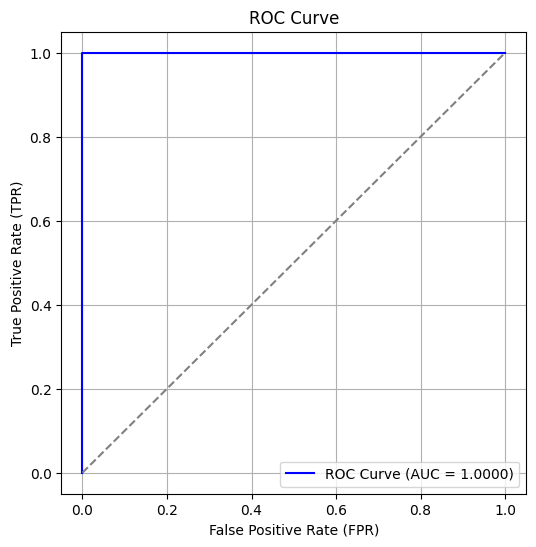

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve


y_true = np.array([1, 1, 0, 1, 1, 1, 1, 0, 1, 0])
y_scores = np.array([0.55, 0.55, 0.49, 0.55, 0.55, 0.55, 0.55, 0.49, 0.55, 0.49])
auc = roc_auc_score(y_true, y_scores)
print(f"ROC AUC Score: {auc:.4f}")
fpr, tpr, _ = roc_curve(y_true, y_scores)


plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Diagonal line (random model)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import asyncio
import nest_asyncio

nest_asyncio.apply()

async def task(name, seconds):
    print(f"Task {name} started ⏳")
    await asyncio.sleep(seconds)
    print(f"Task {name} completed ✅")


async def main():
    print("pupa")
    await asyncio.gather(
        task("A", 5),
        task("B", 4),
        task("C", 2)
    )
    print("lupa")


asyncio.run(main())



pupa
Task A started ⏳
Task B started ⏳
Task C started ⏳
Task C completed ✅
Task B completed ✅
Task A completed ✅
lupa
